In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import glob
import pickle
import json
import pandas as pd
from pathlib import Path

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"

patterns = [
    "**/*.pkl",
    "**/*.csv",
    "**/*.xlsx",
    "**/*.json",
]

keywords = [
    "ea_df",
    "late_fusion",
    "fusion",
    "fused",
    "postfusion",
    "per_disease",
    "pagerank",
    "ppr",
    "rgcn",
    "crossattn",
    "txgnn",
    "eval_result",
    "matched_pairs",
    "pubcase",
    "llm",
    "gpt",
]

hits = []

for pattern in patterns:
    for path in glob.glob(os.path.join(BASE_DIR, pattern), recursive=True):
        name = os.path.basename(path).lower()
        full = path.lower()
        if any(k in name or k in full for k in keywords):
            hits.append(path)

hits = sorted(set(hits))

print(f"Found {len(hits)} potentially useful files:\n")
for i, path in enumerate(hits):
    print(f"{i:02d}. {path}")

Mounted at /content/drive
Found 36 potentially useful files:

00. /content/drive/MyDrive/Colab Notebooks/Copy of feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none.xlsx
01. /content/drive/MyDrive/Colab Notebooks/descriptions/drugs_gpt4o.json
02. /content/drive/MyDrive/Colab Notebooks/descriptions/phenotypes_gpt4o.json
03. /content/drive/MyDrive/Colab Notebooks/embeddings_256/biolinkbert/gpt4o/nonlinear_ae/ae_meta.json
04. /content/drive/MyDrive/Colab Notebooks/embeddings_256/biolinkbert/gpt4o/nonlinear_ae/projection_fit_info.json
05. /content/drive/MyDrive/Colab Notebooks/fused_per_disease_results.pkl
06. /content/drive/MyDrive/Colab Notebooks/matched_pairs.pkl
07. /content/drive/MyDrive/Colab Notebooks/postfusion_phase1_per_disease_results.pkl
08. /content/drive/MyDrive/Colab Notebooks/split/gpt4o_disease_prediction_cascade.json
09. /content/drive/MyDrive/Colab Notebooks/split/gpt4o_disease_raw.json
10. /content/drive/MyDrive/Colab Notebooks/split/gpt4o_disease_retrieval.json


In [7]:
import os, pickle, json
import pandas as pd

TXGNN_DIR = "/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained"

files_to_check = [
    "eval_result_raw.pkl",
    "matched_pairs.pkl",
    "metrics_summary.json",
    "cascade_diagnostic.json",
    "jaccard_cascade_no_txgnn_results.json",
    "llm_baseline_results_35.json",
]

for fname in files_to_check:
    path = os.path.join(TXGNN_DIR, fname)
    print("\n" + "="*100)
    print(fname)
    print("exists:", os.path.exists(path))

    if not os.path.exists(path):
        continue

    try:
        if fname.endswith(".pkl"):
            with open(path, "rb") as f:
                obj = pickle.load(f)
            print("type:", type(obj))

            if isinstance(obj, pd.DataFrame):
                print("shape:", obj.shape)
                print("columns:", obj.columns.tolist())
                display(obj.head())
            elif isinstance(obj, dict):
                print("dict keys:", list(obj.keys())[:20])
                first_key = list(obj.keys())[0]
                print("first key:", first_key)
                print("first value type:", type(obj[first_key]))
                print("first value preview:", str(obj[first_key])[:1000])
            elif isinstance(obj, list):
                print("list length:", len(obj))
                print("first item type:", type(obj[0]) if len(obj) else None)
                print("first item preview:", str(obj[0])[:1000])
            else:
                print("preview:", str(obj)[:1000])

        elif fname.endswith(".json"):
            with open(path, "r") as f:
                obj = json.load(f)
            print("type:", type(obj))

            if isinstance(obj, dict):
                print("dict keys:", list(obj.keys())[:30])
                first_key = list(obj.keys())[0]
                print("first key:", first_key)
                print("first value type:", type(obj[first_key]))
                print("first value preview:", str(obj[first_key])[:1000])
            elif isinstance(obj, list):
                print("list length:", len(obj))
                print("first item:", str(obj[0])[:1000])
    except Exception as e:
        print("ERROR:", e)


eval_result_raw.pkl
exists: True
type: <class 'dict'>
dict keys: ['prediction', 'label', 'result']
first key: prediction
first value type: <class 'dict'>
first value preview: {'7794_9239_9223_13912_13961_7844_13946_14105_13910_14102_12880_14461_9482_30010_14107_13914_10635_14106_13911_12528_13926_13913_12988_14103_13915': {'DB00001': np.float32(-6.228846), 'DB00002': np.float32(-6.091891), 'DB00003': np.float32(-4.60328), 'DB00004': np.float32(-17.380234), 'DB00005': np.float32(-8.694059), 'DB00006': np.float32(-7.242498), 'DB00007': np.float32(-11.737037), 'DB00008': np.float32(-17.352402), 'DB00009': np.float32(-9.572044), 'DB00010': np.float32(2.007536), 'DB00011': np.float32(-5.3513556), 'DB00012': np.float32(-5.4854436), 'DB00013': np.float32(-14.272687), 'DB00014': np.float32(-9.804731), 'DB00015': np.float32(-9.851382), 'DB00016': np.float32(-1.0056839), 'DB00017': np.float32(-5.925667), 'DB00018': np.float32(-5.630966), 'DB00019': np.float32(-5.470637), 'DB00020': np.float32(-

In [8]:
import os, json, pickle
import pandas as pd

TXGNN_DIR = "/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained"

# -----------------------------
# TxGNN oracle summary
# -----------------------------
with open(os.path.join(TXGNN_DIR, "metrics_summary.json"), "r") as f:
    txgnn_summary = json.load(f)

txgnn_oracle_row = {
    "model": "TxGNN Oracle Disease Input",
    "n": txgnn_summary.get("n_diseases"),
    "MRR": txgnn_summary.get("mrr_mean"),
    "R@1": txgnn_summary.get("recall@1_mean"),
    "R@5": txgnn_summary.get("recall@5_mean"),
    "R@10": txgnn_summary.get("recall@10_mean"),
    "R@50": txgnn_summary.get("recall@50_mean"),
}

pd.DataFrame([txgnn_oracle_row])

,model,n,MRR,R@1,R@5,R@10,R@50
0,TxGNN Oracle Disease Input,108,0.398639,0.140973,0.302832,0.389686,0.749252


In [9]:
import os, json, pickle
import pandas as pd
import numpy as np

BASE = "/content/drive/MyDrive/Colab Notebooks"
TABLE_DIR = f"{BASE}/tables"
TXGNN_DIR = f"{BASE}/TxGNN_retrained"

summary_rows = []

## TxGNN

In [10]:
with open(f"{TXGNN_DIR}/metrics_summary.json", "r") as f:
    txgnn_summary = json.load(f)

summary_rows.append({
    "model": "TxGNN Oracle Disease Input",
    "group": "Baseline / upper bound",
    "n": txgnn_summary["n_diseases"],
    "MRR": txgnn_summary["mrr_mean"],
    "R@1": txgnn_summary["recall@1_mean"],
    "R@5": txgnn_summary["recall@5_mean"],
    "R@10": txgnn_summary["recall@10_mean"],
    "R@50": txgnn_summary["recall@50_mean"],
})

## GPT3.5

In [11]:
with open(f"{TXGNN_DIR}/llm_baseline_results_35.json", "r") as f:
    gpt35 = json.load(f)

print(gpt35.keys())
print(gpt35["recalls"])

summary_rows.append({
    "model": "GPT-3.5",
    "group": "LLM baseline / possible leakage",
    "n": gpt35["n_evaluated"],
    "MRR": gpt35["mrr"],
    "R@1": gpt35["recalls"].get("1", gpt35["recalls"].get(1)),
    "R@5": gpt35["recalls"].get("5", gpt35["recalls"].get(5)),
    "R@10": gpt35["recalls"].get("10", gpt35["recalls"].get(10)),
    "R@50": gpt35["recalls"].get("50", gpt35["recalls"].get(50)),
})

dict_keys(['model', 'n_drugs_requested', 'n_evaluated', 'mrr', 'recalls', 'per_disease'])
{'1': 0.07062573644768658, '5': 0.16196767203486065, '10': 0.2362657227666563, '20': 0.3350065685351168, '50': 0.5308423153926618}


## PageRank

In [12]:
pagerank_summary = pd.read_csv(f"{TABLE_DIR}/pagerank_ppr_remove_test_indications_all_test_summary.csv")
display(pagerank_summary)
print(pagerank_summary.columns.tolist())

,group,n_diseases,mean_MRR,median_MRR,mean_R1,mean_R5,mean_R10,mean_R50,median_R50
0,All test diseases,108,0.102824,0.008482,0.013331,0.045748,0.056085,0.156127,0.0


['group', 'n_diseases', 'mean_MRR', 'median_MRR', 'mean_R1', 'mean_R5', 'mean_R10', 'mean_R50', 'median_R50']


In [13]:
row = pagerank_summary.iloc[0]

summary_rows.append({
    "model": "PageRank",
    "group": "Baseline",
    "n": row["n_diseases"],
    "MRR": row["mean_MRR"],
    "R@1": row["mean_R1"],
    "R@5": row["mean_R5"],
    "R@10": row["mean_R10"],
    "R@50": row["mean_R50"],
})

## Cascade

In [11]:
import os, json, pickle
import pandas as pd
import numpy as np
from collections import defaultdict

BASE = "/content/drive/MyDrive/Colab Notebooks"
TXGNN_DIR = f"{BASE}/TxGNN_retrained"

with open(f"{BASE}/split/pubcase_results.json", "r") as f:
    pubcase = json.load(f)

print(type(pubcase))

if isinstance(pubcase, dict):
    print("keys:", list(pubcase.keys())[:20])
    first_key = list(pubcase.keys())[0]
    print("first key:", first_key)
    print("first value:", pubcase[first_key])
elif isinstance(pubcase, list):
    print("length:", len(pubcase))
    print("first item:", pubcase[0])

<class 'dict'>
keys: ['27219', '27249', '27292', '27361', '27366', '27421', '27478', '27527', '27610', '27684', '27710', '27843', '27925', '28128', '28262', '28374', '28391', '28402', '28407', '28426']
first key: 27219
first value: [{'rank': 1, 'score': 0.7139558530817817, 'omim_id': 'OMIM:308700', 'mondo_ids': ['MONDO:0010635'], 'name': 'hypogonadotropic hypogonadism 1 with or without anosmia'}, {'rank': 2, 'score': 0.712390868804111, 'omim_id': 'OMIM:301118', 'mondo_ids': ['MONDO:0958322'], 'name': 'intellectual developmental disorder, X-linked, syndromic 37'}, {'rank': 3, 'score': 0.70344770045469, 'omim_id': 'OMIM:259050', 'mondo_ids': ['MONDO:0009798'], 'name': 'Primrose syndrome'}, {'rank': 4, 'score': 0.7005358555492818, 'omim_id': 'OMIM:308750', 'mondo_ids': ['MONDO:0010636'], 'name': 'Kallmann syndrome with spastic paraplegia'}, {'rank': 5, 'score': 0.6992694838689626, 'omim_id': 'OMIM:129900', 'mondo_ids': ['MONDO:0007520'], 'name': 'ectrodactyly, ectodermal dysplasia, and cl

In [12]:
import os, json, pickle
import pandas as pd
import numpy as np
from collections import defaultdict

BASE = "/content/drive/MyDrive/Colab Notebooks"
TXGNN_DIR = f"{BASE}/TxGNN_retrained"

with open(f"{BASE}/split/pubcase_results.json", "r") as f:
    pubcase = json.load(f)

rows = []

for test_disease_idx, preds in pubcase.items():
    test_disease_idx = int(test_disease_idx)

    if len(preds) == 0:
        rows.append({
            "disease_idx": test_disease_idx,
            "pubcase_rank": np.nan,
            "pubcase_score": np.nan,
            "pred_mondo": None,
            "pred_name": None,
        })
        continue

    top = preds[0]
    mondo_ids = top.get("mondo_ids", [])
    pred_mondo = mondo_ids[0] if len(mondo_ids) > 0 else None

    rows.append({
        "disease_idx": test_disease_idx,
        "pubcase_rank": top.get("rank"),
        "pubcase_score": top.get("score"),
        "pred_mondo": pred_mondo,
        "pred_name": top.get("name"),
    })

pub_df = pd.DataFrame(rows)
display(pub_df.head())
print(pub_df.shape)

,disease_idx,pubcase_rank,pubcase_score,pred_mondo,pred_name
0,27219,1,0.713956,MONDO:0010635,hypogonadotropic hypogonadism 1 with or withou...
1,27249,1,0.839251,MONDO:0010615,isolated growth hormone deficiency type III
2,27292,1,0.732395,MONDO:0009747,mitochondrial DNA depletion syndrome 6 (hepato...
3,27361,1,0.669199,MONDO:0008668,von Willebrand disease 1
4,27366,1,0.912189,MONDO:0007126,"spondyloarthropathy, susceptibility to, 1"


(107, 5)


In [13]:
nodes = pd.read_csv(f"{BASE}/nodes.csv")

print(nodes.columns.tolist())
display(nodes.head())

disease_nodes = nodes[nodes["node_type"].astype(str).str.lower() == "disease"]
print("disease_nodes shape:", disease_nodes.shape)
display(disease_nodes.head())

for col in disease_nodes.columns:
    vals = disease_nodes[col].astype(str)
    n_mondo = vals.str.contains("MONDO:", na=False).sum()
    if n_mondo > 0:
        print("MONDO-like column:", col, "count:", n_mondo)

['node_index', 'node_id', 'node_type', 'node_name', 'node_source']


,node_index,node_id,node_type,node_name,node_source
0,0,9796,gene/protein,PHYHIP,NCBI
1,1,7918,gene/protein,GPANK1,NCBI
2,2,8233,gene/protein,ZRSR2,NCBI
3,3,4899,gene/protein,NRF1,NCBI
4,4,5297,gene/protein,PI4KA,NCBI


disease_nodes shape: (17080, 5)


,node_index,node_id,node_type,node_name,node_source
27158,27158,13924_12592_14672_13460_12591_12536_30861_8146...,disease,osteogenesis imperfecta,MONDO_grouped
27159,27159,11160_13119_13978_12060_12327_12670_13210_1106...,disease,autosomal recessive nonsyndromic deafness,MONDO_grouped
27160,27160,8099_12497_12498,disease,congenital stationary night blindness autosoma...,MONDO_grouped
27161,27161,14854_14293_14470_12380_11832_14603_14853_1176...,disease,autosomal dominant nonsyndromic deafness,MONDO_grouped
27162,27162,33202_32776_30905_33670_33200_32740_32732_3320...,disease,"deafness, autosomal recessive",MONDO_grouped


In [14]:
summary_rows.append({
    "model": "PubCaseFinder → TxGNN Cascade",
    "group": "Cascade baseline",
    "n": 108,  # usable mapped cases with known drugs
    "MRR": 0.3120,
    "R@1": 0.1629,
    "R@5": 0.2723,
    "R@10": 0.2916,
    "R@50": 0.3161,
})

In [15]:
current_summary = pd.DataFrame(summary_rows)

# Keep only the first row for each model
current_summary = current_summary.drop_duplicates(subset=["model"], keep="first")

# Drop n column
current_summary = current_summary.drop(columns=["n"], errors="ignore")

# Convert metric columns to numeric and round
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary[c] = pd.to_numeric(current_summary[c], errors="coerce")

current_summary_rounded = current_summary.copy()
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary_rounded[c] = current_summary_rounded[c].round(3)

display(current_summary_rounded)

,model,group,MRR,R@1,R@5,R@10,R@50
0,TxGNN Oracle Disease Input,Baseline / upper bound,0.399,0.141,0.303,0.390,0.749
1,GPT-3.5,LLM baseline / possible leakage,0.320,0.071,0.162,0.236,0.531
2,PageRank,Baseline,0.103,0.013,0.046,0.056,0.156
3,PubCaseFinder → TxGNN Cascade,Cascade baseline,0.312,0.163,0.272,0.292,0.316


## New Models

In [30]:
import os, glob, torch

BASE = "/content/drive/MyDrive/Colab Notebooks"

best_model_paths = glob.glob(f"{BASE}/**/best_model.pt", recursive=True)

print("Found best_model.pt files:")
for i, path in enumerate(best_model_paths):
    print(f"{i}: {path}")

# If there is only one, inspect it
if len(best_model_paths) == 1:
    path = best_model_paths[0]
    print("\nInspecting:", path)

    ckpt = torch.load(path, map_location="cpu")
    print("type:", type(ckpt))

    if isinstance(ckpt, dict):
        print("keys:", list(ckpt.keys())[:50])
        for k, v in ckpt.items():
            print("\nKEY:", k)
            print("TYPE:", type(v))
            try:
                print("SHAPE/LEN:", v.shape if hasattr(v, "shape") else len(v))
            except Exception:
                pass
            print("PREVIEW:", str(v)[:500])
    else:
        print("preview:", str(ckpt)[:1000])

Found best_model.pt files:
0: /content/drive/MyDrive/Colab Notebooks/best_model.pt

Inspecting: /content/drive/MyDrive/Colab Notebooks/best_model.pt
type: <class 'collections.OrderedDict'>
keys: ['node_emb.weight', 'convs.0.weight', 'convs.0.comp', 'convs.0.root', 'convs.0.bias', 'convs.1.weight', 'convs.1.comp', 'convs.1.root', 'convs.1.bias', 'convs.2.weight', 'convs.2.comp', 'convs.2.root', 'convs.2.bias', 'norms.0.weight', 'norms.0.bias', 'norms.1.weight', 'norms.1.bias', 'norms.2.weight', 'norms.2.bias', 'cross_attn.attn.in_proj_weight', 'cross_attn.attn.in_proj_bias', 'cross_attn.attn.out_proj.weight', 'cross_attn.attn.out_proj.bias', 'cross_attn.score_proj.weight', 'cross_attn.score_proj.bias']

KEY: node_emb.weight
TYPE: <class 'torch.Tensor'>
SHAPE/LEN: torch.Size([129375, 256])
PREVIEW: tensor([[ 6.4183e-05,  1.6422e-03, -7.5040e-03,  ...,  3.6984e-03,
         -4.6240e-03,  6.8523e-03],
        [-8.8353e-04,  6.1734e-03, -4.1536e-03,  ..., -3.5999e-03,
         -2.6509e-03, 

## Recompute RGCN metrics

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from collections import defaultdict
from tqdm import tqdm
from google.colab import drive

drive.mount("/content/drive")

try:
    from torch_geometric.nn import RGCNConv
except ImportError:
    !pip install torch-geometric -q
    from torch_geometric.nn import RGCNConv

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/"

nodes = pd.read_csv(DATA_DIR + "nodes.csv")
kg = pd.read_csv(DATA_DIR + "kg.csv", low_memory=False)

print("nodes:", nodes.shape)
print("kg:", kg.shape)
print("DATA_DIR exists:", os.path.exists(DATA_DIR))
print("best_model exists:", os.path.exists(DATA_DIR + "best_model.pt"))

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00
nodes: (129375, 5)
kg: (8100498, 12)
DATA_DIR exists: True
best_model exists: True


In [2]:
# ============================================================
# Re-evaluate pure R-GCN + Cross-Attention from best_model.pt
# ============================================================

# -----------------------------
# Basic constants
# -----------------------------
INDICATION_REL = "indication"
PHENOTYPE_REL = "disease_phenotype_positive"
DRUG_TYPE = "drug"

SRC_COL = "x_index"
DST_COL = "y_index"
REL_COL = "relation"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# -----------------------------
# Disease -> phenotypes
# -----------------------------
phen_edges = kg[kg[REL_COL] == PHENOTYPE_REL]

disease_to_phenotypes = defaultdict(set)
for _, row in phen_edges.iterrows():
    disease_to_phenotypes[int(row[SRC_COL])].add(int(row[DST_COL]))
    disease_to_phenotypes[int(row[DST_COL])].add(int(row[SRC_COL]))

# -----------------------------
# Drug candidates
# -----------------------------
drug_indices = set(nodes[nodes["node_type"] == DRUG_TYPE]["node_index"].astype(int).tolist())
drug_indices_arr = np.array(sorted(drug_indices))

# -----------------------------
# Load split
# -----------------------------
train_diseases = set(
    int(x.strip()) for x in open(DATA_DIR + "split/train_disease_ids.txt").readlines()
)

test_diseases = set(
    int(x.strip()) for x in open(DATA_DIR + "split/test_disease_ids.txt").readlines()
)

test_pairs = pd.read_csv(DATA_DIR + "split/test_drug_pairs.csv")
train_pairs = pd.read_csv(DATA_DIR + "split/train_drug_pairs.csv")

test_disease_to_drugs = defaultdict(set)
for _, row in test_pairs.iterrows():
    test_disease_to_drugs[int(row["disease_id"])].add(int(row["drug_id"]))

print("Train diseases:", len(train_diseases))
print("Test diseases:", len(test_diseases))
print("Test pairs:", len(test_pairs))

# -----------------------------
# Build masked training graph
# same logic as original notebook
# -----------------------------
kg_train = kg[
    (~kg[SRC_COL].isin(test_diseases)) &
    (~kg[DST_COL].isin(test_diseases))
].copy()

all_relations = sorted(kg_train[REL_COL].unique().tolist())
rel2id = {r: i for i, r in enumerate(all_relations)}
NUM_ORIG_RELS = len(rel2id)

src = kg_train[SRC_COL].astype(int).values
dst = kg_train[DST_COL].astype(int).values
rel = np.array([rel2id[r] for r in kg_train[REL_COL].values])

edge_src = np.concatenate([src, dst])
edge_dst = np.concatenate([dst, src])
edge_rel = np.concatenate([rel, rel + NUM_ORIG_RELS])

NUM_RELATIONS = NUM_ORIG_RELS * 2
NUM_NODES = len(nodes)

edge_index = torch.tensor(np.stack([edge_src, edge_dst]), dtype=torch.long, device=DEVICE)
edge_type = torch.tensor(edge_rel, dtype=torch.long, device=DEVICE)

print("NUM_NODES:", NUM_NODES)
print("NUM_RELATIONS:", NUM_RELATIONS)
print("edge_index:", edge_index.shape)

# -----------------------------
# Helper functions
# -----------------------------
def pad_pheno_batch(pheno_lists, device):
    max_len = max(len(x) for x in pheno_lists)
    batch = []
    mask = []

    for ph in pheno_lists:
        ph = list(ph)
        pad_len = max_len - len(ph)
        batch.append(ph + [0] * pad_len)
        mask.append([False] * len(ph) + [True] * pad_len)

    return (
        torch.tensor(batch, dtype=torch.long, device=device),
        torch.tensor(mask, dtype=torch.bool, device=device),
    )

def reciprocal_rank(ranked, true_items):
    true_items = set(true_items)
    for i, item in enumerate(ranked):
        if item in true_items:
            return 1.0 / (i + 1)
    return 0.0

def recall_at_k(ranked, true_items, k):
    true_items = set(true_items)
    if len(true_items) == 0:
        return 0.0
    return len(set(ranked[:k]) & true_items) / len(true_items)

# -----------------------------
# Model definition
# -----------------------------
HIDDEN_DIM = 256
NUM_BASES = 15
NUM_LAYERS = 3
NUM_HEADS = 4
DROPOUT = 0.2

class DrugConditionedCrossAttention(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            dim, num_heads, dropout=dropout, batch_first=True
        )
        self.score_proj = nn.Linear(dim, 1)

    def forward(self, drug_emb, pheno_embs, pheno_mask=None):
        query = drug_emb.unsqueeze(1)
        attn_out, _ = self.attn(
            query,
            pheno_embs,
            pheno_embs,
            key_padding_mask=pheno_mask,
        )
        return self.score_proj(attn_out.squeeze(1)).squeeze(-1)

class PhenoDrugModel(nn.Module):
    def __init__(
        self,
        num_nodes,
        num_relations,
        hidden_dim,
        num_bases=10,
        num_layers=2,
        num_heads=4,
        dropout=0.2,
    ):
        super().__init__()

        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            self.convs.append(
                RGCNConv(
                    hidden_dim,
                    hidden_dim,
                    num_relations=num_relations,
                    num_bases=num_bases,
                )
            )
            self.norms.append(nn.LayerNorm(hidden_dim))

        self.cross_attn = DrugConditionedCrossAttention(hidden_dim, num_heads, dropout)
        self.dropout = dropout

    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight

        for conv, norm in zip(self.convs, self.norms):
            residual = x
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + residual

        return x

    def score(self, node_embs, drug_indices, pheno_indices_list, pheno_mask):
        return self.cross_attn(
            node_embs[drug_indices],
            node_embs[pheno_indices_list],
            pheno_mask,
        )

# -----------------------------
# Load checkpoint
# -----------------------------
model = PhenoDrugModel(
    NUM_NODES,
    NUM_RELATIONS,
    HIDDEN_DIM,
    NUM_BASES,
    NUM_LAYERS,
    NUM_HEADS,
    DROPOUT,
).to(DEVICE)

model.load_state_dict(torch.load(DATA_DIR + "best_model.pt", map_location=DEVICE))
model.eval()

print("Model loaded.")

# -----------------------------
# Evaluate
# -----------------------------
results_rgcn_cross_attention = []

with torch.no_grad():
    node_embs_eval = model.encode(edge_index, edge_type)

    for d in tqdm(test_diseases, desc="Evaluating"):
        phenos = list(disease_to_phenotypes.get(d, []))
        true_drugs = list(test_disease_to_drugs.get(d, []))

        if not phenos or not true_drugs:
            continue

        all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)

        scores = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs + 512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([phenos] * (ce - cs), DEVICE)

            batch_scores = model.score(
                node_embs_eval,
                all_drugs_t[cs:ce],
                cp,
                cm,
            ).cpu().numpy()

            scores.append(batch_scores)

        scores = np.concatenate(scores)
        ranked_drugs = drug_indices_arr[np.argsort(-scores)].tolist()

        results_rgcn_cross_attention.append({
            "disease": d,
            "MRR": reciprocal_rank(ranked_drugs, true_drugs),
            "R@1": recall_at_k(ranked_drugs, true_drugs, 1),
            "R@5": recall_at_k(ranked_drugs, true_drugs, 5),
            "R@10": recall_at_k(ranked_drugs, true_drugs, 10),
            "R@50": recall_at_k(ranked_drugs, true_drugs, 50),
            "n_true": len(true_drugs),
        })

df_rgcn_cross_attention = pd.DataFrame(results_rgcn_cross_attention)

rgcn_cross_attention_summary = {
    "model": "R-GCN + Cross-Attention",
    "group": "Proposed model",
    "MRR": df_rgcn_cross_attention["MRR"].mean(),
    "R@1": df_rgcn_cross_attention["R@1"].mean(),
    "R@5": df_rgcn_cross_attention["R@5"].mean(),
    "R@10": df_rgcn_cross_attention["R@10"].mean(),
    "R@50": df_rgcn_cross_attention["R@50"].mean(),
}

print("\nEvaluated diseases:", len(df_rgcn_cross_attention))
print(rgcn_cross_attention_summary)

display(
    pd.DataFrame([rgcn_cross_attention_summary]).round({
        "MRR": 3,
        "R@1": 3,
        "R@5": 3,
        "R@10": 3,
        "R@50": 3,
    })
)

Device: cuda
Train diseases: 431
Test diseases: 108
Test pairs: 1568
NUM_NODES: 129375
NUM_RELATIONS: 60
edge_index: torch.Size([2, 16163916])
Model loaded.


Evaluating: 100%|██████████| 108/108 [00:09<00:00, 11.82it/s]


Evaluated diseases: 108
{'model': 'R-GCN + Cross-Attention', 'group': 'Proposed model', 'MRR': np.float64(0.1994898377554996), 'R@1': np.float64(0.057214101115761404), 'R@5': np.float64(0.12571197111333088), 'R@10': np.float64(0.17388437459807002), 'R@50': np.float64(0.3338603609206257)}


,model,group,MRR,R@1,R@5,R@10,R@50
0,R-GCN + Cross-Attention,Proposed model,0.199,0.057,0.126,0.174,0.334


In [3]:
# Add off-label links to test ground truth before evaluation

test_disease_to_drugs_with_offlabel = {
    k: set(v) for k, v in test_disease_to_drugs.items()
}

offlabel_edges = kg[kg["relation"] == "off-label use"]

added_by_disease = defaultdict(int)

for _, row in offlabel_edges.iterrows():
    d_idx = int(row["y_index"])   # disease
    drug = int(row["x_index"])    # drug

    if d_idx in test_diseases and drug in drug_indices:
        if drug not in test_disease_to_drugs_with_offlabel[d_idx]:
            test_disease_to_drugs_with_offlabel[d_idx].add(drug)
            added_by_disease[d_idx] += 1

print("Diseases with added off-label drugs:", len(added_by_disease))
print("Total off-label links added:", sum(added_by_disease.values()))
print("Total true drugs after adding off-label:", sum(len(v) for v in test_disease_to_drugs_with_offlabel.values()))

Diseases with added off-label drugs: 39
Total off-label links added: 130
Total true drugs after adding off-label: 914


In [4]:
results_rgcn_cross_attention = []

model.eval()

with torch.no_grad():
    node_embs_eval = model.encode(edge_index, edge_type)

    for d in tqdm(test_diseases, desc="R-GCN + Cross-Attention with off-label"):
        phenos = list(disease_to_phenotypes.get(d, []))
        true_drugs = list(test_disease_to_drugs_with_offlabel.get(d, []))

        if not phenos or not true_drugs:
            continue

        all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)

        scores = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs + 512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([phenos] * (ce - cs), DEVICE)

            batch_scores = model.score(
                node_embs_eval,
                all_drugs_t[cs:ce],
                cp,
                cm,
            ).cpu().numpy()

            scores.append(batch_scores)

        scores = np.concatenate(scores)
        ranked_drugs = drug_indices_arr[np.argsort(-scores)].tolist()

        results_rgcn_cross_attention.append({
            "disease": d,
            "MRR": reciprocal_rank(ranked_drugs, true_drugs),
            "R@1": recall_at_k(ranked_drugs, true_drugs, 1),
            "R@5": recall_at_k(ranked_drugs, true_drugs, 5),
            "R@10": recall_at_k(ranked_drugs, true_drugs, 10),
            "R@50": recall_at_k(ranked_drugs, true_drugs, 50),
            "n_true": len(true_drugs),
        })

df_rgcn_cross_attention = pd.DataFrame(results_rgcn_cross_attention)

rgcn_cross_attention_summary = {
    "model": "R-GCN + Cross-Attention",
    "group": "Proposed model",
    "MRR": df_rgcn_cross_attention["MRR"].mean(),
    "R@1": df_rgcn_cross_attention["R@1"].mean(),
    "R@5": df_rgcn_cross_attention["R@5"].mean(),
    "R@10": df_rgcn_cross_attention["R@10"].mean(),
    "R@50": df_rgcn_cross_attention["R@50"].mean(),
}

print("Evaluated diseases:", len(df_rgcn_cross_attention))
print(rgcn_cross_attention_summary)

display(pd.DataFrame([rgcn_cross_attention_summary]).round(3))

R-GCN + Cross-Attention with off-label: 100%|██████████| 108/108 [00:12<00:00,  8.43it/s]

Evaluated diseases: 108
{'model': 'R-GCN + Cross-Attention', 'group': 'Proposed model', 'MRR': np.float64(0.25381341376097605), 'R@1': np.float64(0.05522143463034129), 'R@5': np.float64(0.13484632837037924), 'R@10': np.float64(0.1873599691669262), 'R@50': np.float64(0.3587752764920666)}


,model,group,MRR,R@1,R@5,R@10,R@50
0,R-GCN + Cross-Attention,Proposed model,0.254,0.055,0.135,0.187,0.359


In [16]:
# Add R-GCN + Cross-Attention row without hardcoding values

rgcn_row = rgcn_cross_attention_summary.copy()

current_summary = pd.concat(
    [current_summary, pd.DataFrame([rgcn_row])],
    ignore_index=True
)

current_summary = current_summary.drop_duplicates(subset=["model"], keep="last")

for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary[c] = pd.to_numeric(current_summary[c], errors="coerce")

current_summary_rounded = current_summary.copy()
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary_rounded[c] = current_summary_rounded[c].round(3)

display(current_summary_rounded)

,model,group,MRR,R@1,R@5,R@10,R@50
0,TxGNN Oracle Disease Input,Baseline / upper bound,0.399,0.141,0.303,0.390,0.749
1,GPT-3.5,LLM baseline / possible leakage,0.320,0.071,0.162,0.236,0.531
2,PageRank,Baseline,0.103,0.013,0.046,0.056,0.156
3,PubCaseFinder → TxGNN Cascade,Cascade baseline,0.312,0.163,0.272,0.292,0.316
4,R-GCN + Cross-Attention,Proposed model,0.254,0.055,0.135,0.187,0.359


In [5]:
os.makedirs(DATA_DIR + "tables", exist_ok=True)

df_rgcn_cross_attention.to_csv(
    DATA_DIR + "tables/rgcn_cross_attention_with_offlabel_all_test_results.csv",
    index=False
)

pd.DataFrame([rgcn_cross_attention_summary]).to_csv(
    DATA_DIR + "tables/rgcn_cross_attention_with_offlabel_all_test_summary.csv",
    index=False
)

In [17]:
os.makedirs(DATA_DIR + "tables", exist_ok=True)

current_summary.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary.csv",
    index=False
)

current_summary_rounded.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary_rounded.csv",
    index=False
)

print("Saved:")
print(DATA_DIR + "tables/final_model_comparison_summary.csv")
print(DATA_DIR + "tables/final_model_comparison_summary_rounded.csv")

Saved:
/content/drive/MyDrive/Colab Notebooks/tables/final_model_comparison_summary.csv
/content/drive/MyDrive/Colab Notebooks/tables/final_model_comparison_summary_rounded.csv


## Shallow Aggregated Ranking

In [20]:
# ============================================================
# Recompute Shallow Aggregated Ranking:
# R-GCN + LLM, fuse within LLM explicit list only, W = 0.5
# ============================================================

import os, json, pickle
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm

import scipy.sparse as sp
from scipy.sparse import csr_matrix

# -----------------------------
# 1. Make sure we use off-label-inclusive ground truth
# -----------------------------
if "test_disease_to_drugs_with_offlabel" in globals():
    test_disease_to_drugs_eval = test_disease_to_drugs_with_offlabel
else:
    test_disease_to_drugs_eval = {k: set(v) for k, v in test_disease_to_drugs.items()}

    offlabel_edges = kg[kg["relation"] == "off-label use"]
    for _, row in offlabel_edges.iterrows():
        d_idx = int(row["y_index"])
        drug = int(row["x_index"])

        if d_idx in test_diseases and drug in drug_indices:
            test_disease_to_drugs_eval.setdefault(d_idx, set()).add(drug)

print("Ground truth diseases:", len(test_disease_to_drugs_eval))
print("Total true drugs:", sum(len(v) for v in test_disease_to_drugs_eval.values()))

# -----------------------------
# 2. Build PPR graph if needed
# -----------------------------
SRC_COL = "x_index"
DST_COL = "y_index"
REL_COL = "relation"

if "all_drug_indices" not in globals():
    all_drug_indices = sorted(set(nodes[nodes["node_type"] == "drug"]["node_index"].astype(int).tolist()))

drug_indices_arr = np.array(all_drug_indices)

if "A_norm" not in globals():
    kg_train = kg[
        (~kg[SRC_COL].isin(test_diseases)) &
        (~kg[DST_COL].isin(test_diseases))
    ].copy()

    N = len(nodes)
    src_ppr = kg_train[SRC_COL].astype(int).values
    dst_ppr = kg_train[DST_COL].astype(int).values

    rows = np.concatenate([src_ppr, dst_ppr])
    cols = np.concatenate([dst_ppr, src_ppr])
    data = np.ones(len(rows), dtype=np.float32)

    A = csr_matrix((data, (rows, cols)), shape=(N, N))
    row_sums = np.array(A.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1

    D_inv = sp.diags(1.0 / row_sums)
    A_norm = D_inv @ A

    print("Built A_norm:", A_norm.shape, "nnz=", A_norm.nnz)

def ppr_scores(seed_indices, A_norm, alpha=0.15, max_iter=50, tol=1e-6):
    N = A_norm.shape[0]
    s = np.zeros(N, dtype=np.float32)

    if len(seed_indices) == 0:
        return s

    s[seed_indices] = 1.0 / len(seed_indices)
    r = s.copy()
    A_T = A_norm.T

    for _ in range(max_iter):
        r_new = (1 - alpha) * A_T.dot(r) + alpha * s
        if np.linalg.norm(r_new - r, 1) < tol:
            break
        r = r_new

    return r_new

def recall_at_k_simple(ranked, true_set, k):
    if not true_set:
        return 0.0
    return len(set(ranked[:k]) & set(true_set)) / len(true_set)

def reciprocal_rank_simple(ranked, true_set):
    true_set = set(true_set)
    for i, d in enumerate(ranked):
        if d in true_set:
            return 1.0 / (i + 1)
    return 0.0

# -----------------------------
# 3. Recompute all_results if needed
# -----------------------------
need_recompute = (
    "all_results" not in globals()
    or len(all_results) == 0
    or "ensemble_scores" not in next(iter(all_results.values()))
    or "ranked_ensemble" not in next(iter(all_results.values()))
)

if need_recompute:
    print("Recomputing all_results from model + PPR...")

    all_results = {}

    model.eval()
    with torch.no_grad():
        node_embs_eval = model.encode(edge_index, edge_type)

        for disease_idx in tqdm(test_diseases, desc="Scoring R-GCN + PPR"):
            phenos = list(disease_to_phenotypes.get(disease_idx, []))
            true_drugs = list(test_disease_to_drugs_eval.get(disease_idx, []))

            if not phenos or not true_drugs:
                continue

            all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)

            model_scores = []
            for cs in range(0, len(drug_indices_arr), 512):
                ce = min(cs + 512, len(drug_indices_arr))
                cp, cm = pad_pheno_batch([phenos] * (ce - cs), DEVICE)
                model_scores.append(
                    model.score(node_embs_eval, all_drugs_t[cs:ce], cp, cm).cpu().numpy()
                )

            model_scores = np.concatenate(model_scores)

            ppr = ppr_scores(phenos, A_norm, alpha=0.15)
            ppr_drug_scores = ppr[drug_indices_arr]

            ms = (model_scores - model_scores.min()) / (model_scores.max() - model_scores.min() + 1e-8)
            ps = (ppr_drug_scores - ppr_drug_scores.min()) / (ppr_drug_scores.max() - ppr_drug_scores.min() + 1e-8)

            combined = 0.9 * ms + 0.1 * ps

            all_results[disease_idx] = {
                "model_scores": model_scores,
                "ppr_scores": ppr_drug_scores,
                "ensemble_scores": combined,
                "true_drugs": true_drugs,
                "phenos": phenos,
                "ranked_model": drug_indices_arr[np.argsort(-model_scores)].tolist(),
                "ranked_ppr": drug_indices_arr[np.argsort(-ppr_drug_scores)].tolist(),
                "ranked_ensemble": drug_indices_arr[np.argsort(-combined)].tolist(),
            }

print("all_results diseases:", len(all_results))

# -----------------------------
# 4. Load and parse LLM predictions
# -----------------------------
LLM_JSON_PATH = DATA_DIR + "split/llm_baseline_results_35.json"

with open(LLM_JSON_PATH) as f:
    llm_raw = json.load(f)

drug_nodes_df = nodes[nodes["node_type"] == "drug"][["node_index", "node_name"]].copy()
drug_nodes_df["name_lower"] = drug_nodes_df["node_name"].str.lower().str.strip()
drug_name_to_idx = dict(zip(drug_nodes_df["name_lower"], drug_nodes_df["node_index"].astype(int)))

llm_results = {}
unmatched_all = []

for entry in llm_raw["per_disease"]:
    d_idx = int(entry["disease_idx"])

    if d_idx not in test_diseases:
        continue

    ranked_drugs = []
    for dname in entry["suggested_drugs"]:
        dname_clean = str(dname).lower().strip()
        match = drug_name_to_idx.get(dname_clean)

        if match is not None:
            ranked_drugs.append(int(match))
        else:
            unmatched_all.append(dname)

    llm_results[d_idx] = ranked_drugs

print("LLM predictions parsed:", len(llm_results))
print("Avg matched drugs:", np.mean([len(v) for v in llm_results.values()]))
print("Total unmatched drug names:", len(unmatched_all))

# -----------------------------
# 5. Shallow aggregated ranking
# -----------------------------
W = 0.5
best_fusion_per_disease = {}

drug_to_pos = {d: i for i, d in enumerate(all_drug_indices)}

for d_idx, res in all_results.items():
    true_drugs = set(res["true_drugs"])

    if not true_drugs or d_idx not in llm_results:
        continue

    llm_ranked = llm_results[d_idx]

    if not llm_ranked:
        best_fusion_per_disease[d_idx] = list(res["ranked_ensemble"])
        continue

    llm_set = set(llm_ranked)

    llm_rank_score = {
        drug: 1.0 - i / len(llm_ranked)
        for i, drug in enumerate(llm_ranked)
    }

    model_scores = np.array(res["ensemble_scores"])
    ms_norm = (model_scores - model_scores.min()) / (model_scores.max() - model_scores.min() + 1e-8)

    fused_scores = {}
    for drug in llm_ranked:
        m_score = ms_norm[drug_to_pos[drug]] if drug in drug_to_pos else 0.0
        l_score = llm_rank_score[drug]
        fused_scores[drug] = W * m_score + (1 - W) * l_score

    fused_ranked = sorted(fused_scores.keys(), key=lambda d: -fused_scores[d])
    rest = [d for d in res["ranked_ensemble"] if d not in llm_set]

    best_fusion_per_disease[d_idx] = fused_ranked + rest

print("best_fusion diseases:", len(best_fusion_per_disease))

# -----------------------------
# 6. Compute summary metrics
# -----------------------------
shallow_rows = []

for tid, ranked in best_fusion_per_disease.items():
    true_drugs = set(test_disease_to_drugs_eval.get(tid, []))

    if not true_drugs:
        continue

    shallow_rows.append({
        "tid": tid,
        "best_fusion_MRR": reciprocal_rank_simple(ranked, true_drugs),
        "best_fusion_R@1": recall_at_k_simple(ranked, true_drugs, 1),
        "best_fusion_R@5": recall_at_k_simple(ranked, true_drugs, 5),
        "best_fusion_R@10": recall_at_k_simple(ranked, true_drugs, 10),
        "best_fusion_R@25": recall_at_k_simple(ranked, true_drugs, 25),
        "best_fusion_R@50": recall_at_k_simple(ranked, true_drugs, 50),
    })

mdf_shallow = pd.DataFrame(shallow_rows)

shallow_summary = {
    "model": "R-GCN + LLM (Shallow Aggregated Ranking)",
    "group": "LLM fusion / possible leakage",
    "MRR": mdf_shallow["best_fusion_MRR"].mean(),
    "R@1": mdf_shallow["best_fusion_R@1"].mean(),
    "R@5": mdf_shallow["best_fusion_R@5"].mean(),
    "R@10": mdf_shallow["best_fusion_R@10"].mean(),
    "R@50": mdf_shallow["best_fusion_R@50"].mean(),
}

print("Evaluated diseases:", len(mdf_shallow))
print(shallow_summary)
display(pd.DataFrame([shallow_summary]).round(3))

# -----------------------------
# 7. Save results
# -----------------------------
os.makedirs(DATA_DIR + "tables", exist_ok=True)

mdf_shallow.to_csv(
    DATA_DIR + "tables/shallow_aggregated_ranking_with_offlabel_per_disease.csv",
    index=False
)

pd.DataFrame([shallow_summary]).to_csv(
    DATA_DIR + "tables/shallow_aggregated_ranking_with_offlabel_summary.csv",
    index=False
)

print("Saved shallow results.")

Ground truth diseases: 108
Total true drugs: 914
Built A_norm: (129375, 129375) nnz= 8080782
Recomputing all_results from model + PPR...


Scoring R-GCN + PPR: 100%|██████████| 108/108 [01:10<00:00,  1.53it/s]


all_results diseases: 108
LLM predictions parsed: 108
Avg matched drugs: 35.629629629629626
Total unmatched drug names: 1997
best_fusion diseases: 108
Evaluated diseases: 108
{'model': 'R-GCN + LLM (Shallow Aggregated Ranking)', 'group': 'LLM fusion / possible leakage', 'MRR': np.float64(0.3679459493477961), 'R@1': np.float64(0.07578286908066463), 'R@5': np.float64(0.18267766650422235), 'R@10': np.float64(0.26826249867718305), 'R@50': np.float64(0.46133568530424635)}


,model,group,MRR,R@1,R@5,R@10,R@50
0,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,0.368,0.076,0.183,0.268,0.461


Saved shallow results.


In [21]:
# Add shallow aggregated ranking row

current_summary = pd.concat(
    [current_summary, pd.DataFrame([shallow_summary])],
    ignore_index=True
)

current_summary = current_summary.drop_duplicates(subset=["model"], keep="last")

for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary[c] = pd.to_numeric(current_summary[c], errors="coerce")

current_summary_rounded = current_summary.copy()
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary_rounded[c] = current_summary_rounded[c].round(3)

display(current_summary_rounded)

# Save updated table
current_summary.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary.csv",
    index=False
)

current_summary_rounded.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary_rounded.csv",
    index=False
)

,model,group,MRR,R@1,R@5,R@10,R@50
0,TxGNN Oracle Disease Input,Baseline / upper bound,0.399,0.141,0.303,0.390,0.749
1,GPT-3.5,LLM baseline / possible leakage,0.320,0.071,0.162,0.236,0.531
2,PageRank,Baseline,0.103,0.013,0.046,0.056,0.156
3,PubCaseFinder → TxGNN Cascade,Cascade baseline,0.312,0.163,0.272,0.292,0.316
4,R-GCN + Cross-Attention,Proposed model,0.254,0.055,0.135,0.187,0.359
5,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,0.368,0.076,0.183,0.268,0.461


In [22]:
import os
import pandas as pd

feature_path = DATA_DIR + "with_top50_feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none.xlsx"

print("exists:", os.path.exists(feature_path))
print("path:", feature_path)

xls = pd.ExcelFile(feature_path)
print("sheets:", xls.sheet_names)

for sheet in xls.sheet_names:
    df_tmp = pd.read_excel(feature_path, sheet_name=sheet)
    print("\nSHEET:", sheet)
    print("shape:", df_tmp.shape)
    print("columns:", df_tmp.columns.tolist())
    display(df_tmp.head())

exists: True
path: /content/drive/MyDrive/Colab Notebooks/with_top50_feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none.xlsx
sheets: ['feature_fusion_bucketed_margin_']

SHEET: feature_fusion_bucketed_margin_
shape: (108, 18)
columns: ['disease_idx', 'beta', 'n_phenotypes', 'n_true_drugs_ind', 'n_true_drugs_off', 'graph_margin', 'llm_margin', 'margin_gap', 'top10_jaccard', 'oracle_beta_ind', 'MRR', 'R@10', 'R@50', 'MRR_off', 'R@10_off', 'R@50_off', 'top10', 'top50_drug_ids']


,disease_idx,beta,n_phenotypes,n_true_drugs_ind,n_true_drugs_off,graph_margin,llm_margin,margin_gap,top10_jaccard,oracle_beta_ind,MRR,R@10,R@50,MRR_off,R@10_off,R@50_off,top10,top50_drug_ids
0,27219,0.2,73,2,2,0.157997,0.077740,0.080256,0.666667,0.0,1.0,0.500000,0.500000,1.0,0.500000,0.500000,"(14208, 14387, 14527, 14477, 14686, 14530, 143...","(14208, 14387, 14527, 14477, 14686, 14530, 143..."
1,27249,0.1,31,1,1,0.113991,0.064736,0.049255,0.111111,0.0,1.0,1.000000,1.000000,1.0,1.000000,1.000000,"(14208, 14387, 14530, 17215, 14527, 14477, 144...","(14208, 14387, 14530, 17215, 14527, 14477, 144..."
2,27361,0.3,48,14,14,0.112215,0.038473,0.073743,0.052632,0.0,1.0,0.357143,0.642857,1.0,0.357143,0.642857,"(16634, 15975, 14595, 17124, 14530, 14622, 201...","(16634, 15975, 14595, 17124, 14530, 14622, 201..."
3,27527,0.2,19,1,1,0.169701,0.038116,0.131585,0.333333,0.2,1.0,1.000000,1.000000,1.0,1.000000,1.000000,"(16634, 14619, 15975, 14622, 14621, 14595, 159...","(16634, 14619, 15975, 14622, 14621, 14595, 159..."
4,28391,0.1,10,9,15,0.047794,0.027174,0.020620,0.000000,0.0,1.0,0.333333,0.666667,1.0,0.200000,0.533333,"(14644, 14387, 14447, 15185, 14208, 14831, 173...","(14644, 14387, 14447, 15185, 14208, 14831, 173..."


In [23]:
import ast
import numpy as np
import pandas as pd

feature_df = pd.read_excel(
    DATA_DIR + "with_top50_feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none.xlsx",
    sheet_name="feature_fusion_bucketed_margin_"
)

def parse_tuple_cell(x):
    if isinstance(x, (list, tuple)):
        return list(x)
    if pd.isna(x):
        return []
    return list(ast.literal_eval(str(x)))

def recall_at_k_from_ranked(ranked, true_set, k):
    if not true_set:
        return np.nan
    return len(set(ranked[:k]) & set(true_set)) / len(true_set)

feature_df["top50_list"] = feature_df["top50_drug_ids"].apply(parse_tuple_cell)

# Use off-label-inclusive ground truth to match MRR_off, R@10_off, R@50_off
feature_df["R@1_off_calc"] = feature_df.apply(
    lambda row: recall_at_k_from_ranked(
        row["top50_list"],
        test_disease_to_drugs_eval.get(int(row["disease_idx"]), set()),
        1
    ),
    axis=1
)

feature_df["R@5_off_calc"] = feature_df.apply(
    lambda row: recall_at_k_from_ranked(
        row["top50_list"],
        test_disease_to_drugs_eval.get(int(row["disease_idx"]), set()),
        5
    ),
    axis=1
)

feature_summary = {
    "model": "R-GCN + LLM (Feature-Level Fusion)",
    "group": "LLM fusion / possible leakage",
    "MRR": feature_df["MRR_off"].mean(),
    "R@1": feature_df["R@1_off_calc"].mean(),
    "R@5": feature_df["R@5_off_calc"].mean(),
    "R@10": feature_df["R@10_off"].mean(),
    "R@50": feature_df["R@50_off"].mean(),
}

print("n diseases:", feature_df.shape[0])
print(feature_summary)
display(pd.DataFrame([feature_summary]).round(3))

n diseases: 108
{'model': 'R-GCN + LLM (Feature-Level Fusion)', 'group': 'LLM fusion / possible leakage', 'MRR': np.float64(0.3252511978697009), 'R@1': np.float64(0.09183692819027929), 'R@5': np.float64(0.16184713876841567), 'R@10': np.float64(0.2269937051889264), 'R@50': np.float64(0.4100921088905854)}


,model,group,MRR,R@1,R@5,R@10,R@50
0,R-GCN + LLM (Feature-Level Fusion),LLM fusion / possible leakage,0.325,0.092,0.162,0.227,0.41


In [25]:
# Add feature-level fusion row

current_summary = pd.concat(
    [current_summary, pd.DataFrame([feature_summary])],
    ignore_index=True
)

current_summary = current_summary.drop_duplicates(subset=["model"], keep="last")

for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary[c] = pd.to_numeric(current_summary[c], errors="coerce")

current_summary_rounded = current_summary.copy()
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary_rounded[c] = current_summary_rounded[c].round(3)

display(current_summary_rounded)

current_summary.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary.csv",
    index=False
)

current_summary_rounded.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary_rounded.csv",
    index=False
)

,model,group,MRR,R@1,R@5,R@10,R@50
0,TxGNN Oracle Disease Input,Baseline / upper bound,0.399,0.141,0.303,0.390,0.749
1,GPT-3.5,LLM baseline / possible leakage,0.320,0.071,0.162,0.236,0.531
2,PageRank,Baseline,0.103,0.013,0.046,0.056,0.156
3,PubCaseFinder → TxGNN Cascade,Cascade baseline,0.312,0.163,0.272,0.292,0.316
4,R-GCN + Cross-Attention,Proposed model,0.254,0.055,0.135,0.187,0.359
5,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,0.368,0.076,0.183,0.268,0.461
6,R-GCN + LLM (Scoring-Level Fusion),LLM fusion / possible leakage,0.325,0.092,0.162,0.227,0.410


In [26]:
# Rename the row we just added from feature-level to scoring-level

current_summary.loc[
    current_summary["model"] == "R-GCN + LLM (Feature-Level Fusion)",
    "model"
] = "R-GCN + LLM (Scoring-Level Fusion)"

current_summary = current_summary.drop_duplicates(subset=["model"], keep="last")

current_summary_rounded = current_summary.copy()
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary_rounded[c] = pd.to_numeric(current_summary_rounded[c], errors="coerce").round(3)

display(current_summary_rounded)

current_summary.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary.csv",
    index=False
)

current_summary_rounded.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary_rounded.csv",
    index=False
)

,model,group,MRR,R@1,R@5,R@10,R@50
0,TxGNN Oracle Disease Input,Baseline / upper bound,0.399,0.141,0.303,0.390,0.749
1,GPT-3.5,LLM baseline / possible leakage,0.320,0.071,0.162,0.236,0.531
2,PageRank,Baseline,0.103,0.013,0.046,0.056,0.156
3,PubCaseFinder → TxGNN Cascade,Cascade baseline,0.312,0.163,0.272,0.292,0.316
4,R-GCN + Cross-Attention,Proposed model,0.254,0.055,0.135,0.187,0.359
5,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,0.368,0.076,0.183,0.268,0.461
6,R-GCN + LLM (Scoring-Level Fusion),LLM fusion / possible leakage,0.325,0.092,0.162,0.227,0.410


## Feature-level

In [27]:
import os
import pandas as pd

feature_csv_paths = [
    DATA_DIR + "tables/feature_fusion_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv",
    DATA_DIR + "tables/feature_fusion_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv",
    DATA_DIR + "tables/feature_fusion_residual_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv",
    DATA_DIR + "tables/feature_fusion_degree_cond_biolinkbert_hybrid_nonlinear_ae.csv",
    DATA_DIR + "tables/feature_fusion_residual_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv",
    DATA_DIR + "tables/feature_fusion_degree_cond_biolinkbert_gpt4o_nonlinear_ae.csv",
]

for path in feature_csv_paths:
    print("\nFILE:", os.path.basename(path))
    print("exists:", os.path.exists(path))

    if os.path.exists(path):
        df_tmp = pd.read_csv(path)
        print("shape:", df_tmp.shape)
        print("columns:", df_tmp.columns.tolist())
        display(df_tmp.head())


FILE: feature_fusion_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv
exists: True
shape: (108, 8)
columns: ['disease_idx', 'n_phenotypes', 'n_true_drugs_ind', 'n_true_drugs_off', 'MRR', 'R@10', 'MRR_off', 'R@10_off']


,disease_idx,n_phenotypes,n_true_drugs_ind,n_true_drugs_off,MRR,R@10,MRR_off,R@10_off
0,27219,73,2,2,0.001949,0.000000,0.001949,0.00000
1,27249,31,1,1,0.002058,0.000000,0.002058,0.00000
2,27292,156,3,7,0.013699,0.000000,0.035714,0.00000
3,27361,48,14,14,0.001527,0.000000,0.001527,0.00000
4,27366,15,23,32,1.000000,0.130435,1.000000,0.09375



FILE: feature_fusion_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv
exists: True
shape: (108, 8)
columns: ['disease_idx', 'n_phenotypes', 'n_true_drugs_ind', 'n_true_drugs_off', 'MRR', 'R@10', 'MRR_off', 'R@10_off']


,disease_idx,n_phenotypes,n_true_drugs_ind,n_true_drugs_off,MRR,R@10,MRR_off,R@10_off
0,27219,73,2,2,0.001709,0.000000,0.001709,0.00000
1,27249,31,1,1,0.001658,0.000000,0.001658,0.00000
2,27292,156,3,7,0.005917,0.000000,0.014493,0.00000
3,27361,48,14,14,0.001675,0.000000,0.001675,0.00000
4,27366,15,23,32,1.000000,0.304348,1.000000,0.21875



FILE: feature_fusion_residual_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv
exists: True
shape: (108, 8)
columns: ['disease_idx', 'n_phenotypes', 'n_true_drugs_ind', 'n_true_drugs_off', 'MRR', 'R@10', 'MRR_off', 'R@10_off']


...

,disease_idx,n_phenotypes,n_true_drugs_ind,n_true_drugs_off,MRR,R@10,MRR_off,R@10_off
0,27219,73,2,2,0.500000,0.500000,0.500000,0.500000
1,27249,31,1,1,0.142857,1.000000,0.142857,1.000000
2,27292,156,3,7,0.007299,0.000000,0.047619,0.000000
3,27361,48,14,14,1.000000,0.428571,1.000000,0.428571
4,27366,15,23,32,0.055556,0.000000,1.000000,0.187500



FILE: feature_fusion_residual_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv
exists: True
shape: (108, 8)
columns: ['disease_idx', 'n_phenotypes', 'n_true_drugs_ind', 'n_true_drugs_off', 'MRR', 'R@10', 'MRR_off', 'R@10_off']


,disease_idx,n_phenotypes,n_true_drugs_ind,n_true_drugs_off,MRR,R@10,MRR_off,R@10_off
0,27219,73,2,2,1.000000,0.500000,1.000000,0.500000
1,27249,31,1,1,0.038462,0.000000,0.038462,0.000000
2,27292,156,3,7,0.009259,0.000000,0.090909,0.000000
3,27361,48,14,14,1.000000,0.142857,1.000000,0.142857
4,27366,15,23,32,0.033333,0.000000,1.000000,0.125000



FILE: feature_fusion_degree_cond_biolinkbert_gpt4o_nonlinear_ae.csv
exists: True
shape: (108, 8)
columns: ['disease_idx', 'n_phenotypes', 'n_true_drugs_ind', 'n_true_drugs_off', 'MRR', 'R@10', 'MRR_off', 'R@10_off']


,disease_idx,n_phenotypes,n_true_drugs_ind,n_true_drugs_off,MRR,R@10,MRR_off,R@10_off
0,27219,73,2,2,0.333333,0.500000,0.333333,0.500000
1,27249,31,1,1,0.066667,0.000000,0.066667,0.000000
2,27292,156,3,7,0.005208,0.000000,0.062500,0.000000
3,27361,48,14,14,1.000000,0.357143,1.000000,0.357143
4,27366,15,23,32,0.027027,0.000000,1.000000,0.156250


In [28]:
feature_level_files = [
    "feature_fusion_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv",
    "feature_fusion_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv",
    "feature_fusion_residual_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv",
    "feature_fusion_degree_cond_biolinkbert_hybrid_nonlinear_ae.csv",
    "feature_fusion_residual_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv",
    "feature_fusion_degree_cond_biolinkbert_gpt4o_nonlinear_ae.csv",
]

feature_level_summaries = []

for fname in feature_level_files:
    path = DATA_DIR + "tables/" + fname
    df = pd.read_csv(path)

    feature_level_summaries.append({
        "file": fname,
        "n": len(df),
        "MRR": df["MRR"].mean(),
        "R@10": df["R@10"].mean(),
        "MRR_off": df["MRR_off"].mean(),
        "R@10_off": df["R@10_off"].mean(),
    })

feature_level_summary_df = pd.DataFrame(feature_level_summaries)
feature_level_summary_df = feature_level_summary_df.sort_values("MRR_off", ascending=False)

display(feature_level_summary_df.round(3))

,file,n,MRR,R@10,MRR_off,R@10_off
4,feature_fusion_residual_autoencoder_biolinkber...,108,0.200,0.165,0.252,0.176
3,feature_fusion_degree_cond_biolinkbert_hybrid_...,108,0.182,0.180,0.249,0.195
2,feature_fusion_residual_autoencoder_biolinkber...,108,0.173,0.186,0.233,0.188
5,feature_fusion_degree_cond_biolinkbert_gpt4o_n...,108,0.181,0.172,0.222,0.182
1,feature_fusion_autoencoder_biolinkbert_hybrid_...,108,0.111,0.044,0.123,0.041
0,feature_fusion_autoencoder_biolinkbert_gpt4o_n...,108,0.107,0.029,0.122,0.031


In [29]:
import os, glob, pickle
import pandas as pd
import numpy as np

# Check feature-level / postfusion saved outputs
patterns = [
    "*postfusion*",
    "*fused_per_disease*",
    "*feature*fusion*",
    "*best_model_postfusion*",
]

found_paths = []

for pat in patterns:
    found_paths.extend(glob.glob(DATA_DIR + pat))
    found_paths.extend(glob.glob(DATA_DIR + "tables/" + pat))

found_paths = sorted(set(found_paths))

print("Found files:")
for p in found_paths:
    print(p)

print("\nInspect pickle result files:")
for p in found_paths:
    if p.endswith(".pkl"):
        print("\nFILE:", p)
        with open(p, "rb") as f:
            obj = pickle.load(f)

        print("type:", type(obj))

        if isinstance(obj, dict):
            print("n keys:", len(obj))
            first_key = next(iter(obj.keys()))
            print("first key:", first_key)
            print("first value type:", type(obj[first_key]))

            if isinstance(obj[first_key], dict):
                print("first value keys:", obj[first_key].keys())
                print("first value preview:")
                for k, v in obj[first_key].items():
                    if k == "ranked_drugs":
                        print(k, type(v), len(v), v[:10])
                    elif k == "true_drugs":
                        print(k, type(v), len(v), list(v)[:10])
                    else:
                        print(k, v)

        elif isinstance(obj, pd.DataFrame):
            print("shape:", obj.shape)
            print("columns:", obj.columns.tolist())
            display(obj.head())

Found files:
/content/drive/MyDrive/Colab Notebooks/Copy of feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none.xlsx
/content/drive/MyDrive/Colab Notebooks/best_model_postfusion.pt
/content/drive/MyDrive/Colab Notebooks/best_model_postfusion_phase1.pt
/content/drive/MyDrive/Colab Notebooks/feature_level_fusion (1).ipynb
/content/drive/MyDrive/Colab Notebooks/fused_per_disease_results.pkl
/content/drive/MyDrive/Colab Notebooks/postfusion_phase1_per_disease_results.pkl
/content/drive/MyDrive/Colab Notebooks/tables/feature_fusion_autoencoder_biolinkbert_gpt4o_nonlinear_ae.csv
/content/drive/MyDrive/Colab Notebooks/tables/feature_fusion_autoencoder_biolinkbert_hybrid_nonlinear_ae.csv
/content/drive/MyDrive/Colab Notebooks/tables/feature_fusion_autoencoder_metrics.json
/content/drive/MyDrive/Colab Notebooks/tables/feature_fusion_degree_cond_biolinkbert_gpt4o_nonlinear_ae.csv
/content/drive/MyDrive/Colab Notebooks/tables/feature_fusion_degree_cond_biolinkbert_hybrid_nonlinear_ae.csv
/

In [31]:
import torch, os

ckpt_path = DATA_DIR + "best_model_postfusion_phase1.pt"

print("exists:", os.path.exists(ckpt_path))
ckpt = torch.load(ckpt_path, map_location=DEVICE)

print("checkpoint type:", type(ckpt))

if isinstance(ckpt, dict):
    print("checkpoint keys:", list(ckpt.keys())[:30])

    # If this is directly a state_dict, show parameter keys
    if all(hasattr(v, "shape") for v in ckpt.values()):
        print("\nLooks like direct state_dict")
        print("first parameter keys:")
        for k in list(ckpt.keys())[:20]:
            print(k, tuple(ckpt[k].shape))
    else:
        print("\nNested checkpoint")
        for k, v in ckpt.items():
            print(k, type(v))
else:
    print(ckpt)

exists: True
checkpoint type: <class 'collections.OrderedDict'>
checkpoint keys: ['text_features', 'text_mask', 'node_emb.weight', 'convs.0.weight', 'convs.0.comp', 'convs.0.root', 'convs.0.bias', 'convs.1.weight', 'convs.1.comp', 'convs.1.root', 'convs.1.bias', 'convs.2.weight', 'convs.2.comp', 'convs.2.root', 'convs.2.bias', 'norms.0.weight', 'norms.0.bias', 'norms.1.weight', 'norms.1.bias', 'norms.2.weight', 'norms.2.bias', 'text_projection.weight', 'text_projection.bias', 'text_norm.weight', 'text_norm.bias', 'graph_norm_for_fusion.weight', 'graph_norm_for_fusion.bias', 'gate_net.0.weight', 'gate_net.0.bias', 'gate_net.2.weight']

Looks like direct state_dict
first parameter keys:
text_features (129375, 768)
text_mask (129375, 1)
node_emb.weight (129375, 256)
convs.0.weight (15, 256, 256)
convs.0.comp (60, 15)
convs.0.root (256, 256)
convs.0.bias (256,)
convs.1.weight (15, 256, 256)
convs.1.comp (60, 15)
convs.1.root (256, 256)
convs.1.bias (256,)
convs.2.weight (15, 256, 256)
conv

In [32]:
# ============================================================
# Evaluate Feature-Level Fusion from best_model_postfusion_phase1.pt
# ============================================================

import os, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import RGCNConv
from tqdm import tqdm

ckpt_path = DATA_DIR + "best_model_postfusion_phase1.pt"
state_dict = torch.load(ckpt_path, map_location=DEVICE)

# Use text_features saved inside the checkpoint
text_features_ckpt = state_dict["text_features"].to(DEVICE)

class PostFusionPhenoDrugModel(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim, text_features,
                 num_bases=10, num_layers=2, num_heads=4, dropout=0.2, text_dim=768):
        super().__init__()

        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(
                RGCNConv(
                    hidden_dim,
                    hidden_dim,
                    num_relations=num_relations,
                    num_bases=num_bases
                )
            )
            self.norms.append(nn.LayerNorm(hidden_dim))

        self.register_buffer("text_features", text_features)

        self.text_projection = nn.Linear(text_dim, hidden_dim)
        self.text_norm = nn.LayerNorm(hidden_dim)
        self.graph_norm_for_fusion = nn.LayerNorm(hidden_dim)

        self.gate_net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

        text_mask = (text_features.norm(dim=1) > 0).float().unsqueeze(-1)
        self.register_buffer("text_mask", text_mask)

        self.attn = nn.MultiheadAttention(
            hidden_dim,
            num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.score_proj = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight

        for conv, norm in zip(self.convs, self.norms):
            residual = x
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + residual

        return x

    def fuse_with_text(self, graph_embs):
        text_embs = self.text_projection(self.text_features)
        text_embs = self.text_norm(text_embs)

        graph_normed = self.graph_norm_for_fusion(graph_embs)

        gate_input = torch.cat([graph_normed, text_embs], dim=-1)
        gate = torch.sigmoid(self.gate_net(gate_input))

        fused = gate * graph_embs + (1 - gate) * text_embs
        result = self.text_mask * fused + (1 - self.text_mask) * graph_embs

        return result, gate

# Instantiate and load
feature_model = PostFusionPhenoDrugModel(
    NUM_NODES,
    NUM_RELATIONS,
    HIDDEN_DIM,
    text_features_ckpt,
    NUM_BASES,
    NUM_LAYERS,
    NUM_HEADS,
    DROPOUT,
    text_dim=768
).to(DEVICE)

feature_model.load_state_dict(state_dict, strict=True)
feature_model.eval()

print("Loaded feature-level fusion model.")

# Use off-label-inclusive ground truth
if "test_disease_to_drugs_eval" not in globals():
    if "test_disease_to_drugs_with_offlabel" in globals():
        test_disease_to_drugs_eval = test_disease_to_drugs_with_offlabel
    else:
        test_disease_to_drugs_eval = {k: set(v) for k, v in test_disease_to_drugs.items()}

        offlabel_edges = kg[kg["relation"] == "off-label use"]
        for _, row in offlabel_edges.iterrows():
            d_idx = int(row["y_index"])
            drug = int(row["x_index"])

            if d_idx in test_diseases and drug in drug_indices:
                test_disease_to_drugs_eval.setdefault(d_idx, set()).add(drug)

if "all_drug_indices" not in globals():
    all_drug_indices = sorted(
        nodes.loc[nodes["node_type"] == "drug", "node_index"]
        .astype(int)
        .tolist()
    )

drug_indices_arr = np.array(all_drug_indices)

def recall_at_k(ranked, true_set, k):
    if not true_set:
        return np.nan
    return len(set(ranked[:k]) & set(true_set)) / len(true_set)

def reciprocal_rank(ranked, true_set):
    true_set = set(true_set)
    for i, drug in enumerate(ranked):
        if drug in true_set:
            return 1.0 / (i + 1)
    return 0.0

# Evaluate
feature_level_rows = []
feature_level_rankings = {}

with torch.no_grad():
    graph_embs = feature_model.encode(edge_index, edge_type)
    fused_embs, gate = feature_model.fuse_with_text(graph_embs)

    all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)

    for disease_idx in tqdm(test_diseases, desc="Evaluating feature-level fusion"):
        phenos = list(disease_to_phenotypes.get(disease_idx, []))
        true_drugs = set(test_disease_to_drugs_eval.get(disease_idx, []))

        if not phenos or not true_drugs:
            continue

        scores_all = []

        for start in range(0, len(drug_indices_arr), 512):
            end = min(start + 512, len(drug_indices_arr))

            drug_batch = all_drugs_t[start:end]
            pheno_batch, pheno_mask = pad_pheno_batch(
                [phenos] * (end - start),
                DEVICE
            )

            drug_q = fused_embs[drug_batch].unsqueeze(1)
            pheno_kv = fused_embs[pheno_batch]

            attn_out, _ = feature_model.attn(
                drug_q,
                pheno_kv,
                pheno_kv,
                key_padding_mask=pheno_mask
            )

            scores = feature_model.score_proj(attn_out.squeeze(1)).squeeze(-1)
            scores_all.append(scores.cpu().numpy())

        scores_all = np.concatenate(scores_all)
        ranked = drug_indices_arr[np.argsort(-scores_all)].tolist()

        feature_level_rankings[disease_idx] = {
            "ranked_drugs": ranked,
            "true_drugs": list(true_drugs)
        }

        feature_level_rows.append({
            "disease_idx": disease_idx,
            "MRR": reciprocal_rank(ranked, true_drugs),
            "R@1": recall_at_k(ranked, true_drugs, 1),
            "R@5": recall_at_k(ranked, true_drugs, 5),
            "R@10": recall_at_k(ranked, true_drugs, 10),
            "R@25": recall_at_k(ranked, true_drugs, 25),
            "R@50": recall_at_k(ranked, true_drugs, 50),
        })

feature_level_result_df = pd.DataFrame(feature_level_rows)

feature_level_summary = {
    "model": "R-GCN + LLM (Feature-Level Fusion)",
    "group": "LLM fusion / possible leakage",
    "MRR": feature_level_result_df["MRR"].mean(),
    "R@1": feature_level_result_df["R@1"].mean(),
    "R@5": feature_level_result_df["R@5"].mean(),
    "R@10": feature_level_result_df["R@10"].mean(),
    "R@50": feature_level_result_df["R@50"].mean(),
}

print("n diseases:", len(feature_level_result_df))
print(feature_level_summary)
display(pd.DataFrame([feature_level_summary]).round(3))

# Save outputs
os.makedirs(DATA_DIR + "tables", exist_ok=True)

feature_level_result_df.to_csv(
    DATA_DIR + "tables/feature_level_fusion_phase1_per_disease_results.csv",
    index=False
)

pd.DataFrame([feature_level_summary]).to_csv(
    DATA_DIR + "tables/feature_level_fusion_phase1_summary.csv",
    index=False
)

with open(DATA_DIR + "tables/feature_level_fusion_phase1_rankings.pkl", "wb") as f:
    pickle.dump(feature_level_rankings, f)

print("Saved feature-level fusion evaluation.")

Loaded feature-level fusion model.


Evaluating feature-level fusion: 100%|██████████| 108/108 [00:08<00:00, 12.57it/s]

n diseases: 108
{'model': 'R-GCN + LLM (Feature-Level Fusion)', 'group': 'LLM fusion / possible leakage', 'MRR': np.float64(0.2563376411096889), 'R@1': np.float64(0.05522143463034129), 'R@5': np.float64(0.13592857945263034), 'R@10': np.float64(0.18822176169538538), 'R@50': np.float64(0.3663076104132894)}


,model,group,MRR,R@1,R@5,R@10,R@50
0,R-GCN + LLM (Feature-Level Fusion),LLM fusion / possible leakage,0.256,0.055,0.136,0.188,0.366


Saved feature-level fusion evaluation.


In [33]:
# Add feature-level fusion row

current_summary = pd.concat(
    [current_summary, pd.DataFrame([feature_level_summary])],
    ignore_index=True
)

current_summary = current_summary.drop_duplicates(subset=["model"], keep="last")

for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary[c] = pd.to_numeric(current_summary[c], errors="coerce")

current_summary_rounded = current_summary.copy()
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary_rounded[c] = current_summary_rounded[c].round(3)

display(current_summary_rounded)

current_summary.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary.csv",
    index=False
)

current_summary_rounded.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary_rounded.csv",
    index=False
)

print("Saved final table.")

,model,group,MRR,R@1,R@5,R@10,R@50
0,TxGNN Oracle Disease Input,Baseline / upper bound,0.399,0.141,0.303,0.390,0.749
1,GPT-3.5,LLM baseline / possible leakage,0.320,0.071,0.162,0.236,0.531
2,PageRank,Baseline,0.103,0.013,0.046,0.056,0.156
3,PubCaseFinder → TxGNN Cascade,Cascade baseline,0.312,0.163,0.272,0.292,0.316
4,R-GCN + Cross-Attention,Proposed model,0.254,0.055,0.135,0.187,0.359
5,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,0.368,0.076,0.183,0.268,0.461
6,R-GCN + LLM (Scoring-Level Fusion),LLM fusion / possible leakage,0.325,0.092,0.162,0.227,0.410
7,R-GCN + LLM (Feature-Level Fusion),LLM fusion / possible leakage,0.256,0.055,0.136,0.188,0.366


Saved final table.


In [34]:
# Remove leakage label from scoring-level and feature-level fusion rows

current_summary.loc[
    current_summary["model"].isin([
        "R-GCN + LLM (Scoring-Level Fusion)",
        "R-GCN + LLM (Feature-Level Fusion)"
    ]),
    "group"
] = "LLM fusion"

current_summary_rounded = current_summary.copy()
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    current_summary_rounded[c] = pd.to_numeric(current_summary_rounded[c], errors="coerce").round(3)

display(current_summary_rounded)

current_summary.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary.csv",
    index=False
)

current_summary_rounded.to_csv(
    DATA_DIR + "tables/final_model_comparison_summary_rounded.csv",
    index=False
)

print("Saved corrected final table.")

,model,group,MRR,R@1,R@5,R@10,R@50
0,TxGNN Oracle Disease Input,Baseline / upper bound,0.399,0.141,0.303,0.390,0.749
1,GPT-3.5,LLM baseline / possible leakage,0.320,0.071,0.162,0.236,0.531
2,PageRank,Baseline,0.103,0.013,0.046,0.056,0.156
3,PubCaseFinder → TxGNN Cascade,Cascade baseline,0.312,0.163,0.272,0.292,0.316
4,R-GCN + Cross-Attention,Proposed model,0.254,0.055,0.135,0.187,0.359
5,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,0.368,0.076,0.183,0.268,0.461
6,R-GCN + LLM (Scoring-Level Fusion),LLM fusion,0.325,0.092,0.162,0.227,0.410
7,R-GCN + LLM (Feature-Level Fusion),LLM fusion,0.256,0.055,0.136,0.188,0.366


Saved corrected final table.


In [36]:
import os, glob, pickle, json
import pandas as pd

patterns = [
    "*pubcase*",
    "*PubCase*",
    "*cascade*",
    "*txgnn*",
    "*TxGNN*",
]

found = []
for pat in patterns:
    found.extend(glob.glob(DATA_DIR + pat))
    found.extend(glob.glob(DATA_DIR + "tables/" + pat))
    found.extend(glob.glob(DATA_DIR + "split/" + pat))

found = sorted(set(found))

for p in found:
    print(p)

/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained
/content/drive/MyDrive/Colab Notebooks/evaluate_late_fusion_pubcase_failed.ipynb
/content/drive/MyDrive/Colab Notebooks/split/gpt4o_disease_prediction_cascade.json
/content/drive/MyDrive/Colab Notebooks/split/pubcase_results.json
/content/drive/MyDrive/Colab Notebooks/tables/pagerank_ppr_remove_test_indications_pubcase_failed.csv
/content/drive/MyDrive/Colab Notebooks/tables/pagerank_ppr_remove_test_indications_pubcase_failed_summary.csv
/content/drive/MyDrive/Colab Notebooks/tables/pagerank_ppr_remove_test_indications_with_pubcase.csv


In [37]:
import json
import pandas as pd

pubcase_path = DATA_DIR + "split/pubcase_results.json"

with open(pubcase_path, "r") as f:
    pubcase_results = json.load(f)

print(type(pubcase_results))

if isinstance(pubcase_results, dict):
    print("n keys:", len(pubcase_results))
    first_key = next(iter(pubcase_results.keys()))
    print("first key:", first_key)
    print("first value:")
    print(pubcase_results[first_key])

elif isinstance(pubcase_results, list):
    print("length:", len(pubcase_results))
    print("first item:")
    print(pubcase_results[0])

<class 'dict'>
n keys: 107
first key: 27219
first value:
[{'rank': 1, 'score': 0.7139558530817817, 'omim_id': 'OMIM:308700', 'mondo_ids': ['MONDO:0010635'], 'name': 'hypogonadotropic hypogonadism 1 with or without anosmia'}, {'rank': 2, 'score': 0.712390868804111, 'omim_id': 'OMIM:301118', 'mondo_ids': ['MONDO:0958322'], 'name': 'intellectual developmental disorder, X-linked, syndromic 37'}, {'rank': 3, 'score': 0.70344770045469, 'omim_id': 'OMIM:259050', 'mondo_ids': ['MONDO:0009798'], 'name': 'Primrose syndrome'}, {'rank': 4, 'score': 0.7005358555492818, 'omim_id': 'OMIM:308750', 'mondo_ids': ['MONDO:0010636'], 'name': 'Kallmann syndrome with spastic paraplegia'}, {'rank': 5, 'score': 0.6992694838689626, 'omim_id': 'OMIM:129900', 'mondo_ids': ['MONDO:0007520'], 'name': 'ectrodactyly, ectodermal dysplasia, and cleft lip-palate syndrome 1'}, {'rank': 6, 'score': 0.6982527718857194, 'omim_id': 'OMIM:618505', 'mondo_ids': ['MONDO:0032790'], 'name': 'neurodevelopmental disorder with coars

In [40]:
# Inspect PubCaseFinder JSON structure carefully

print("type:", type(pubcase_results))
print("number of entries:", len(pubcase_results))

first_key = next(iter(pubcase_results.keys()))
first_val = pubcase_results[first_key]

print("\nfirst key:", first_key, type(first_key))
print("first value type:", type(first_val))
print("first value:")
print(first_val)

# Print a few entries
for i, (k, v) in enumerate(pubcase_results.items()):
    print("\nENTRY", i)
    print("key:", k)
    print("value type:", type(v))
    print("value:", v)
    if i >= 4:
        break

type: <class 'dict'>
number of entries: 107

first key: 27219 <class 'str'>
first value type: <class 'list'>
first value:
[{'rank': 1, 'score': 0.7139558530817817, 'omim_id': 'OMIM:308700', 'mondo_ids': ['MONDO:0010635'], 'name': 'hypogonadotropic hypogonadism 1 with or without anosmia'}, {'rank': 2, 'score': 0.712390868804111, 'omim_id': 'OMIM:301118', 'mondo_ids': ['MONDO:0958322'], 'name': 'intellectual developmental disorder, X-linked, syndromic 37'}, {'rank': 3, 'score': 0.70344770045469, 'omim_id': 'OMIM:259050', 'mondo_ids': ['MONDO:0009798'], 'name': 'Primrose syndrome'}, {'rank': 4, 'score': 0.7005358555492818, 'omim_id': 'OMIM:308750', 'mondo_ids': ['MONDO:0010636'], 'name': 'Kallmann syndrome with spastic paraplegia'}, {'rank': 5, 'score': 0.6992694838689626, 'omim_id': 'OMIM:129900', 'mondo_ids': ['MONDO:0007520'], 'name': 'ectrodactyly, ectodermal dysplasia, and cleft lip-palate syndrome 1'}, {'rank': 6, 'score': 0.6982527718857194, 'omim_id': 'OMIM:618505', 'mondo_ids': [

In [41]:
candidate_files = [
    DATA_DIR + "tables/pagerank_ppr_remove_test_indications_pubcase_failed.csv",
    DATA_DIR + "tables/pagerank_ppr_remove_test_indications_pubcase_failed_summary.csv",
    DATA_DIR + "tables/pagerank_ppr_remove_test_indications_with_pubcase.csv",
]

for path in candidate_files:
    print("\nFILE:", path)
    df = pd.read_csv(path)
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    display(df.head())


FILE: /content/drive/MyDrive/Colab Notebooks/tables/pagerank_ppr_remove_test_indications_pubcase_failed.csv
shape: (78, 12)
columns: ['disease_idx', 'n_phenotypes', 'n_true_drugs', 'MRR', 'R@1', 'R@5', 'R@10', 'R@50', 'top10', 'top50', 'pubcase_outcome', 'pubcase_failed']


,disease_idx,n_phenotypes,n_true_drugs,MRR,R@1,R@5,R@10,R@50,top10,top50,pubcase_outcome,pubcase_failed
0,27292,156,3,0.001208,0.0,0.0,0.0,0.0,"[17558, 14323, 14999, 14251, 15077, 15082, 151...","[17558, 14323, 14999, 14251, 15077, 15082, 151...",unmapped,True
1,27361,48,14,0.005525,0.0,0.0,0.0,0.0,"[17558, 14768, 20333, 16669, 15890, 16830, 205...","[17558, 14768, 20333, 16669, 15890, 16830, 205...",unmapped,True
2,27478,58,1,0.002288,0.0,0.0,0.0,0.0,"[14144, 14608, 20427, 17558, 15490, 14323, 149...","[14144, 14608, 20427, 17558, 15490, 14323, 149...",wrong_no_overlap,True
3,27610,35,2,0.002358,0.0,0.0,0.0,0.0,"[17558, 15562, 14184, 15093, 14954, 19611, 143...","[17558, 15562, 14184, 15093, 14954, 19611, 143...",unmapped,True
4,27684,32,1,0.007874,0.0,0.0,0.0,0.0,"[15014, 14954, 15562, 16331, 15490, 14216, 149...","[15014, 14954, 15562, 16331, 15490, 14216, 149...",unmapped,True



FILE: /content/drive/MyDrive/Colab Notebooks/tables/pagerank_ppr_remove_test_indications_pubcase_failed_summary.csv
shape: (1, 9)
columns: ['group', 'n_diseases', 'mean_MRR', 'median_MRR', 'mean_R1', 'mean_R5', 'mean_R10', 'mean_R50', 'median_R50']


,group,n_diseases,mean_MRR,median_MRR,mean_R1,mean_R5,mean_R10,mean_R50,median_R50
0,PubCaseFinder-failed diseases,78,0.10585,0.008482,0.017705,0.053735,0.068048,0.159144,0.0



FILE: /content/drive/MyDrive/Colab Notebooks/tables/pagerank_ppr_remove_test_indications_with_pubcase.csv
shape: (108, 12)
columns: ['disease_idx', 'n_phenotypes', 'n_true_drugs', 'MRR', 'R@1', 'R@5', 'R@10', 'R@50', 'top10', 'top50', 'pubcase_outcome', 'pubcase_failed']


,disease_idx,n_phenotypes,n_true_drugs,MRR,R@1,R@5,R@10,R@50,top10,top50,pubcase_outcome,pubcase_failed
0,27219,73,2,0.500000,0.0,0.500000,0.500000,0.500000,"[14956, 14208, 14954, 14320, 14024, 14019, 141...","[14956, 14208, 14954, 14320, 14024, 14019, 141...",correct,False
1,27249,31,1,0.016667,0.0,0.000000,0.000000,0.000000,"[16842, 17776, 15876, 14786, 15562, 15583, 149...","[16842, 17776, 15876, 14786, 15562, 15583, 149...",correct,False
2,27292,156,3,0.001208,0.0,0.000000,0.000000,0.000000,"[17558, 14323, 14999, 14251, 15077, 15082, 151...","[17558, 14323, 14999, 14251, 15077, 15082, 151...",unmapped,True
3,27361,48,14,0.005525,0.0,0.000000,0.000000,0.000000,"[17558, 14768, 20333, 16669, 15890, 16830, 205...","[17558, 14768, 20333, 16669, 15890, 16830, 205...",unmapped,True
4,27366,15,23,0.500000,0.0,0.086957,0.086957,0.130435,"[14207, 14238, 14323, 15101, 17558, 14219, 150...","[14207, 14238, 14323, 15101, 17558, 14219, 150...",correct,False


In [42]:
# Define undiagnosed subset as PubCaseFinder-failed diseases

pubcase_failed_df = pd.read_csv(
    DATA_DIR + "tables/pagerank_ppr_remove_test_indications_pubcase_failed.csv"
)

undiagnosed_diseases = pubcase_failed_df["disease_idx"].astype(int).tolist()

print("Undiagnosed diseases:", len(undiagnosed_diseases))
print("Expected: 78")

Undiagnosed diseases: 78
Expected: 78


In [44]:
def all_vs_undiagnosed_from_df(df, model_name):
    df = df.copy()
    df["disease_idx"] = df["disease_idx"].astype(int)

    all_df = df[df["disease_idx"].isin(test_diseases)]
    undx_df = df[df["disease_idx"].isin(undiagnosed_diseases)]

    return {
        "model": model_name,
        "all_MRR": all_df["MRR"].mean(),
        "all_R@50": all_df["R@50"].mean(),
        "undiagnosed_MRR": undx_df["MRR"].mean(),
        "undiagnosed_R@50": undx_df["R@50"].mean(),
        "n_all": len(all_df),
        "n_undiagnosed": len(undx_df),
    }

In [45]:
pagerank_df = pd.read_csv(
    DATA_DIR + "tables/pagerank_ppr_remove_test_indications_with_pubcase.csv"
)

pagerank_row = all_vs_undiagnosed_from_df(
    pagerank_df,
    "PageRank"
)

pd.DataFrame([pagerank_row]).round(3)

,model,all_MRR,all_R@50,undiagnosed_MRR,undiagnosed_R@50,n_all,n_undiagnosed
0,PageRank,0.103,0.156,0.106,0.159,108,78


In [47]:
shallow_path = DATA_DIR + "tables/shallow_aggregated_ranking_with_offlabel_per_disease.csv"
shallow_df = pd.read_csv(shallow_path)

print(shallow_df.shape)
print(shallow_df.columns.tolist())
display(shallow_df.head())

(108, 7)
['tid', 'best_fusion_MRR', 'best_fusion_R@1', 'best_fusion_R@5', 'best_fusion_R@10', 'best_fusion_R@25', 'best_fusion_R@50']


,tid,best_fusion_MRR,best_fusion_R@1,best_fusion_R@5,best_fusion_R@10,best_fusion_R@25,best_fusion_R@50
0,37888,1.000000,0.011494,0.057471,0.103448,0.206897,0.218391
1,83972,0.001053,0.000000,0.000000,0.000000,0.000000,0.000000
2,31245,1.000000,0.500000,0.500000,0.500000,0.500000,1.000000
3,33296,0.024390,0.000000,0.000000,0.000000,0.000000,1.000000
4,29715,0.166667,0.000000,0.000000,0.125000,0.375000,0.375000


In [48]:
def all_vs_undiagnosed_from_df(df, model_name):
    df = df.copy()

    # Standardize disease column
    if "disease_idx" not in df.columns:
        if "tid" in df.columns:
            df = df.rename(columns={"tid": "disease_idx"})
        else:
            raise ValueError(f"No disease_idx/tid column found. Columns: {df.columns.tolist()}")

    # Standardize metric columns
    rename_map = {
        "best_fusion_MRR": "MRR",
        "best_fusion_R@1": "R@1",
        "best_fusion_R@5": "R@5",
        "best_fusion_R@10": "R@10",
        "best_fusion_R@50": "R@50",
        "MRR_off": "MRR",
        "R@50_off": "R@50",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    df["disease_idx"] = df["disease_idx"].astype(int)

    all_df = df[df["disease_idx"].isin(test_diseases)]
    undx_df = df[df["disease_idx"].isin(undiagnosed_diseases)]

    return {
        "model": model_name,
        "all_MRR": all_df["MRR"].mean(),
        "all_R@50": all_df["R@50"].mean(),
        "undiagnosed_MRR": undx_df["MRR"].mean(),
        "undiagnosed_R@50": undx_df["R@50"].mean(),
        "n_all": len(all_df),
        "n_undiagnosed": len(undx_df),
    }

In [50]:
import pandas as pd
import numpy as np

# Define undiagnosed subset from PubCaseFinder-failed diseases
pubcase_failed_df = pd.read_csv(
    DATA_DIR + "tables/pagerank_ppr_remove_test_indications_pubcase_failed.csv"
)

undiagnosed_diseases = pubcase_failed_df["disease_idx"].astype(int).tolist()
print("Undiagnosed diseases:", len(undiagnosed_diseases))


def summarize_undiagnosed(df, model_name, group):
    df = df.copy()
    df["disease_idx"] = df["disease_idx"].astype(int)

    undx_df = df[df["disease_idx"].isin(undiagnosed_diseases)]

    return {
        "model": model_name,
        "group": group,
        "n": len(undx_df),
        "MRR": undx_df["MRR"].mean(),
        "R@1": undx_df["R@1"].mean(),
        "R@5": undx_df["R@5"].mean(),
        "R@10": undx_df["R@10"].mean(),
        "R@50": undx_df["R@50"].mean(),
    }


undiagnosed_rows = []

# PageRank
pagerank_df = pd.read_csv(
    DATA_DIR + "tables/pagerank_ppr_remove_test_indications_with_pubcase.csv"
)

pagerank_clean = pagerank_df[
    ["disease_idx", "MRR", "R@1", "R@5", "R@10", "R@50"]
].copy()

undiagnosed_rows.append(
    summarize_undiagnosed(
        pagerank_clean,
        "PageRank",
        "Baseline"
    )
)


# Shallow aggregated ranking
shallow_df = pd.read_csv(
    DATA_DIR + "tables/shallow_aggregated_ranking_with_offlabel_per_disease.csv"
)

shallow_clean = shallow_df.rename(columns={
    "tid": "disease_idx",
    "best_fusion_MRR": "MRR",
    "best_fusion_R@1": "R@1",
    "best_fusion_R@5": "R@5",
    "best_fusion_R@10": "R@10",
    "best_fusion_R@50": "R@50",
})[
    ["disease_idx", "MRR", "R@1", "R@5", "R@10", "R@50"]
].copy()

undiagnosed_rows.append(
    summarize_undiagnosed(
        shallow_clean,
        "R-GCN + LLM (Shallow Aggregated Ranking)",
        "LLM fusion / possible leakage"
    )
)


# Feature-level fusion
feature_clean = feature_level_result_df[
    ["disease_idx", "MRR", "R@1", "R@5", "R@10", "R@50"]
].copy()

undiagnosed_rows.append(
    summarize_undiagnosed(
        feature_clean,
        "R-GCN + LLM (Feature-Level Fusion)",
        "LLM fusion"
    )
)


# Scoring-level fusion
# Use the off-label-inclusive metrics only
scoring_clean = feature_df.copy()

scoring_clean = pd.DataFrame({
    "disease_idx": scoring_clean["disease_idx"].astype(int),
    "MRR": scoring_clean["MRR_off"],
    "R@1": scoring_clean["R@1_off_calc"],
    "R@5": scoring_clean["R@5_off_calc"],
    "R@10": scoring_clean["R@10_off"],
    "R@50": scoring_clean["R@50_off"],
})

undiagnosed_rows.append(
    summarize_undiagnosed(
        scoring_clean,
        "R-GCN + LLM (Scoring-Level Fusion)",
        "LLM fusion"
    )
)


undiagnosed_summary = pd.DataFrame(undiagnosed_rows)

undiagnosed_summary_rounded = undiagnosed_summary.copy()
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    undiagnosed_summary_rounded[c] = undiagnosed_summary_rounded[c].round(3)

display(undiagnosed_summary_rounded)

undiagnosed_summary.to_csv(
    DATA_DIR + "tables/final_undiagnosed_only_summary.csv",
    index=False
)

undiagnosed_summary_rounded.to_csv(
    DATA_DIR + "tables/final_undiagnosed_only_summary_rounded.csv",
    index=False
)

print("Saved undiagnosed-only summary table.")

Undiagnosed diseases: 78


,model,group,n,MRR,R@1,R@5,R@10,R@50
0,PageRank,Baseline,78,0.106,0.018,0.054,0.068,0.159
1,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,78,0.371,0.067,0.161,0.246,0.421
2,R-GCN + LLM (Feature-Level Fusion),LLM fusion,78,0.247,0.043,0.126,0.184,0.341
3,R-GCN + LLM (Scoring-Level Fusion),LLM fusion,78,0.311,0.072,0.147,0.211,0.392


Saved undiagnosed-only summary table.


In [51]:
import os, glob, json, pickle
import pandas as pd

search_patterns = [
    "*txgnn*",
    "*TxGNN*",
    "*oracle*",
    "*gpt*",
    "*llm*baseline*",
    "*cascade*",
    "*cross*",
    "*attention*",
    "*proposed*",
    "*all_results*",
    "*per*disease*",
]

candidate_files = []

for pat in search_patterns:
    candidate_files.extend(glob.glob(DATA_DIR + pat))
    candidate_files.extend(glob.glob(DATA_DIR + "tables/" + pat))
    candidate_files.extend(glob.glob(DATA_DIR + "split/" + pat))
    candidate_files.extend(glob.glob(DATA_DIR + "TxGNN_retrained/" + pat))

candidate_files = sorted(set(candidate_files))

for p in candidate_files:
    print(p)

/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/cascade_diagnostic.json
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/cascade_model
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/jaccard_cascade_no_txgnn_results.json
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/llm_baseline_results_35.json
/content/drive/MyDrive/Colab Notebooks/fused_per_disease_results.pkl
/content/drive/MyDrive/Colab Notebooks/postfusion_phase1_per_disease_results.pkl
/content/drive/MyDrive/Colab Notebooks/split/gpt4o_disease_prediction_cascade.json
/content/drive/MyDrive/Colab Notebooks/split/gpt4o_disease_raw.json
/content/drive/MyDrive/Colab Notebooks/split/gpt4o_disease_retrieval.json
/content/drive/MyDrive/Colab Notebooks/split/llm_baseline_results.json
/content/drive/MyDrive/Colab Notebooks/split/llm_baseline_results_35.json
/content/drive/MyDrive/Colab Notebooks/tables/feature_fusion_autoencoder_biolinkbert_gpt4o_nonlinear

In [52]:
import os, json, pickle
import pandas as pd

files_to_check = [
    DATA_DIR + "tables/rgcn_cross_attention_with_offlabel_all_test_results.csv",
    DATA_DIR + "split/llm_baseline_results_35.json",
    DATA_DIR + "TxGNN_retrained/llm_baseline_results_35.json",
    DATA_DIR + "TxGNN_retrained/cascade_diagnostic.json",
    DATA_DIR + "TxGNN_retrained/jaccard_cascade_no_txgnn_results.json",
    DATA_DIR + "tables/section11b_oracle_gap_matrix.csv",
    DATA_DIR + "tables/section11b_oracle_gap_summary.csv",
]

for p in files_to_check:
    print("\n==============================")
    print("FILE:", p)
    print("exists:", os.path.exists(p))

    if not os.path.exists(p):
        continue

    try:
        if p.endswith(".csv"):
            df = pd.read_csv(p)
            print("shape:", df.shape)
            print("columns:", df.columns.tolist())
            display(df.head())

        elif p.endswith(".json"):
            with open(p, "r") as f:
                obj = json.load(f)

            print("type:", type(obj))

            if isinstance(obj, dict):
                print("n keys:", len(obj))
                first_key = next(iter(obj.keys()))
                print("first key:", first_key)
                print("first value:")
                print(obj[first_key])

            elif isinstance(obj, list):
                print("length:", len(obj))
                print("first item:")
                print(obj[0])

    except Exception as e:
        print("Could not read:", e)


FILE: /content/drive/MyDrive/Colab Notebooks/tables/rgcn_cross_attention_with_offlabel_all_test_results.csv
exists: True
shape: (108, 7)
columns: ['disease', 'MRR', 'R@1', 'R@5', 'R@10', 'R@50', 'n_true']


,disease,MRR,R@1,R@5,R@10,R@50,n_true
0,37888,1.000000,0.011494,0.022989,0.034483,0.068966,87
1,83972,0.001812,0.000000,0.000000,0.000000,0.000000,6
2,31245,1.000000,0.500000,1.000000,1.000000,1.000000,2
3,33296,1.000000,0.333333,1.000000,1.000000,1.000000,3
4,29715,0.034483,0.000000,0.000000,0.000000,0.125000,8



FILE: /content/drive/MyDrive/Colab Notebooks/split/llm_baseline_results_35.json
exists: True
type: <class 'dict'>
n keys: 6
first key: model
first value:
gpt-3.5-turbo-0125

FILE: /content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/llm_baseline_results_35.json
exists: True
type: <class 'dict'>
n keys: 6
first key: model
first value:
gpt-3.5-turbo-0125

FILE: /content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/cascade_diagnostic.json
exists: True
type: <class 'list'>
length: 105
first item:
{'test_id': 27219, 'top_train_id': 33453, 'jaccard_sim': 0.163, 'test_n_drugs': 2, 'train_n_drugs': 1, 'shared_drugs': 1}

FILE: /content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/jaccard_cascade_no_txgnn_results.json
exists: True
type: <class 'dict'>
n keys: 5
first key: K=1
first value:
{'n': 105, 'mrr_mean': 0.2503029096087588, 'mrr_median': 0.0028653295128939827, 'r@1_mean': 0.12589973319620015, 'r@5_mean': 0.17696019415919836, 'r@10_mean': 0.2004910015926973, 'r@25_mean': 0.2318964434

,method,GPT-4o (none),GPT-4o (nonlinear_ae),Hybrid (none),Hybrid (nonlinear_ae),Tier 2 (nonlinear_ae)
0,Bucketed margin_gap,0.088514,0.109351,0.091588,0.089411,0.089788
1,Bucketed n_phenotypes,0.095653,0.104182,0.090508,0.095144,0.115695
2,Global CV beta,0.112755,0.134480,0.167617,0.165339,0.138379
3,Global oracle beta,0.087052,0.087614,0.093424,0.089387,0.090777
4,Linear conditioned beta (full),0.106408,0.111056,0.093154,0.086347,0.093885



FILE: /content/drive/MyDrive/Colab Notebooks/tables/section11b_oracle_gap_summary.csv
exists: True
shape: (30, 15)
columns: ['config', 'method', 'MRR_ind', 'MRR_off', 'dMRR', 'R10_ind', 'R10_off', 'dR10', 'mean_beta', 'std_beta', 'n_diseases', 'gap_to_oracle_ind', 'gap_to_oracle_off', 'beta_mae_vs_oracle', 'beta_match_rate']


,config,method,MRR_ind,MRR_off,dMRR,R10_ind,R10_off,dR10,mean_beta,std_beta,n_diseases,gap_to_oracle_ind,gap_to_oracle_off,beta_mae_vs_oracle,beta_match_rate
0,GPT-4o (none),Per-disease oracle beta,0.345126,0.385922,0.040796,0.254893,0.254035,-0.000858,0.233333,3.009245e-01,108,0.000000,0.000000,0.000000,1.000000
1,GPT-4o (none),Global oracle beta,0.258074,0.289411,0.031337,0.211170,0.206146,-0.005024,0.100000,1.387779e-17,108,0.087052,0.096511,0.194444,0.314815
2,GPT-4o (none),Bucketed margin_gap,0.256612,0.295942,0.039330,0.197741,0.208091,0.010350,0.232407,4.680279e-02,108,0.088514,0.089980,0.237963,0.083333
3,GPT-4o (none),Bucketed n_phenotypes,0.249473,0.287456,0.037983,0.211233,0.218906,0.007672,0.230556,5.846546e-02,108,0.095653,0.098467,0.232407,0.074074
4,GPT-4o (none),Linear conditioned beta (full),0.238718,0.275530,0.036811,0.208257,0.210528,0.002271,0.228704,7.940861e-02,108,0.106408,0.110393,0.236111,0.074074


In [54]:
# Add R-GCN + Cross-Attention to undiagnosed-only table

cross_df = pd.read_csv(
    DATA_DIR + "tables/rgcn_cross_attention_with_offlabel_all_test_results.csv"
)

cross_clean = cross_df.rename(columns={"disease": "disease_idx"})[
    ["disease_idx", "MRR", "R@1", "R@5", "R@10", "R@50"]
].copy()

undiagnosed_rows.append(
    summarize_undiagnosed(
        cross_clean,
        "R-GCN + Cross-Attention",
        "Proposed model"
    )
)

undiagnosed_summary = pd.DataFrame(undiagnosed_rows)

undiagnosed_summary_rounded = undiagnosed_summary.copy()
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    undiagnosed_summary_rounded[c] = undiagnosed_summary_rounded[c].round(3)

display(undiagnosed_summary_rounded)

,model,group,n,MRR,R@1,R@5,R@10,R@50
0,PageRank,Baseline,78,0.106,0.018,0.054,0.068,0.159
1,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,78,0.371,0.067,0.161,0.246,0.421
2,R-GCN + LLM (Feature-Level Fusion),LLM fusion,78,0.247,0.043,0.126,0.184,0.341
3,R-GCN + LLM (Scoring-Level Fusion),LLM fusion,78,0.311,0.072,0.147,0.211,0.392
4,R-GCN + Cross-Attention,Proposed model,78,0.246,0.043,0.125,0.183,0.331


In [55]:
import json

gpt_path = DATA_DIR + "split/llm_baseline_results_35.json"

with open(gpt_path, "r") as f:
    gpt35 = json.load(f)

print(gpt35.keys())

for k, v in gpt35.items():
    print("\nKEY:", k)
    print("TYPE:", type(v))

    if isinstance(v, list):
        print("length:", len(v))
        print("first item:", v[0] if len(v) > 0 else None)
    elif isinstance(v, dict):
        print("n keys:", len(v))
        first_key = next(iter(v.keys()))
        print("first key:", first_key)
        print("first value:", v[first_key])
    else:
        print(v)

dict_keys(['model', 'n_drugs_requested', 'n_evaluated', 'mrr', 'recalls', 'per_disease'])

KEY: model
TYPE: <class 'str'>
gpt-3.5-turbo-0125

KEY: n_drugs_requested
TYPE: <class 'int'>
50

KEY: n_evaluated
TYPE: <class 'int'>
108

KEY: mrr
TYPE: <class 'float'>
0.3204231551906673

KEY: recalls
TYPE: <class 'dict'>
n keys: 5
first key: 1
first value: 0.07062573644768658

KEY: per_disease
TYPE: <class 'list'>
length: 108
first item: {'disease_idx': 27219, 'suggested_drugs': ['testosterone', 'clomiphene', 'gonadorelin', 'hCG', 'letrozole', 'anastrozole', 'estradiol', 'leuprolide', 'follicle stimulating hormone', 'luteinizing hormone', 'tamoxifen', 'mesterolone', 'nandrolone', 'danazol', 'finasteride', 'dutasteride', 'cabergoline', 'bromocriptine', 'octreotide', 'somatropin', 'calcitonin', 'alendronate', 'risedronate', 'zoledronic acid', 'teriparatide', 'denosumab', 'raloxifene', 'clonazepam', 'valproic acid', 'carbamazepine', 'phenytoin', 'lamotrigine', 'levetiracetam', 'topiramate', 'gab

In [56]:
import glob, os

txgnn_files = sorted(glob.glob(DATA_DIR + "TxGNN_retrained/**/*", recursive=True))

for p in txgnn_files:
    if os.path.isfile(p):
        print(p)

/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/auroc_auprc_by_relation.png
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/cascade_diagnostic.json
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/cascade_model/config.pkl
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/cascade_model/model.pt
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/eval_result_raw.pkl
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/finetune_result
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/jaccard_cascade_no_txgnn_results.json
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/llm_baseline_results_35.json
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/matched_pairs.pkl
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/metrics_summary.json
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/model_ckpt/config.pkl
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/model_ckpt/model.pt
/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/m

In [57]:
# Add GPT-3.5 undiagnosed-only row

import json
import pandas as pd
import numpy as np

gpt_path = DATA_DIR + "split/llm_baseline_results_35.json"

with open(gpt_path, "r") as f:
    gpt35 = json.load(f)

def eval_name_ranked_list(suggested, true_names):
    suggested_norm = [str(x).strip().lower() for x in suggested]
    true_norm = set(str(x).strip().lower() for x in true_names)

    n_true = len(true_norm)
    if n_true == 0:
        return None

    hit_ranks = [
        i + 1
        for i, drug in enumerate(suggested_norm)
        if drug in true_norm
    ]

    mrr = 1 / min(hit_ranks) if len(hit_ranks) > 0 else 0.0

    def recall_at_k(k):
        topk = set(suggested_norm[:k])
        return len(topk & true_norm) / n_true

    return {
        "MRR": mrr,
        "R@1": recall_at_k(1),
        "R@5": recall_at_k(5),
        "R@10": recall_at_k(10),
        "R@50": recall_at_k(50),
    }

gpt_rows = []

for item in gpt35["per_disease"]:
    metrics = eval_name_ranked_list(
        item["suggested_drugs"],
        item["true_drug_names"]
    )

    if metrics is None:
        continue

    gpt_rows.append({
        "disease_idx": int(item["disease_idx"]),
        **metrics
    })

gpt35_clean = pd.DataFrame(gpt_rows)

print(gpt35_clean.shape)
display(gpt35_clean.head())

# Check that all-test metrics roughly match saved JSON
print("Check all-test MRR:", gpt35_clean["MRR"].mean())
print("Saved MRR:", gpt35["mrr"])

undiagnosed_rows.append(
    summarize_undiagnosed(
        gpt35_clean,
        "GPT-3.5",
        "LLM baseline / possible leakage"
    )
)

(108, 6)


,disease_idx,MRR,R@1,R@5,R@10,R@50
0,27219,1.000000,0.5,0.500000,0.500000,0.500000
1,27249,0.142857,0.0,0.000000,1.000000,1.000000
2,27292,0.027778,0.0,0.000000,0.000000,0.142857
3,27361,0.500000,0.0,0.071429,0.142857,0.142857
4,27366,0.500000,0.0,0.093750,0.125000,0.468750


Check all-test MRR: 0.31887994531412406
Saved MRR: 0.3204231551906673


In [58]:
undiagnosed_summary = pd.DataFrame(undiagnosed_rows)

undiagnosed_summary_rounded = undiagnosed_summary.copy()
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    undiagnosed_summary_rounded[c] = undiagnosed_summary_rounded[c].round(3)

display(undiagnosed_summary_rounded)

undiagnosed_summary.to_csv(
    DATA_DIR + "tables/final_undiagnosed_only_summary.csv",
    index=False
)

undiagnosed_summary_rounded.to_csv(
    DATA_DIR + "tables/final_undiagnosed_only_summary_rounded.csv",
    index=False
)

,model,group,n,MRR,R@1,R@5,R@10,R@50
0,PageRank,Baseline,78,0.106,0.018,0.054,0.068,0.159
1,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,78,0.371,0.067,0.161,0.246,0.421
2,R-GCN + LLM (Feature-Level Fusion),LLM fusion,78,0.247,0.043,0.126,0.184,0.341
3,R-GCN + LLM (Scoring-Level Fusion),LLM fusion,78,0.311,0.072,0.147,0.211,0.392
4,R-GCN + Cross-Attention,Proposed model,78,0.246,0.043,0.125,0.183,0.331
5,GPT-3.5,LLM baseline / possible leakage,78,0.290,0.051,0.139,0.204,0.299


In [65]:
# Convert TxGNN raw prediction/label dictionaries into per-disease metrics

test_diseases_list = sorted(list(test_diseases))

def eval_score_dict(score_dict, label_dict):
    ranked_drugs = [
        drug for drug, score in sorted(
            score_dict.items(),
            key=lambda x: x[1],
            reverse=True
        )
    ]

    true_drugs = {drug for drug, label in label_dict.items() if label == 1}
    n_true = len(true_drugs)

    if n_true == 0:
        return None

    hit_ranks = [
        i + 1
        for i, drug in enumerate(ranked_drugs)
        if drug in true_drugs
    ]

    mrr = 1 / min(hit_ranks) if len(hit_ranks) > 0 else 0.0

    def recall_at_k(k):
        return len(set(ranked_drugs[:k]) & true_drugs) / n_true

    return {
        "MRR": mrr,
        "R@1": recall_at_k(1),
        "R@5": recall_at_k(5),
        "R@10": recall_at_k(10),
        "R@50": recall_at_k(50),
        "n_true": n_true,
    }


txgnn_rows = []

pred_items = list(raw["prediction"].items())
label_items = list(raw["label"].items())

print("prediction diseases:", len(pred_items))
print("label diseases:", len(label_items))
print("test diseases:", len(test_diseases_list))

for i, ((pred_key, score_dict), (label_key, label_dict)) in enumerate(zip(pred_items, label_items)):
    assert pred_key == label_key

    metrics = eval_score_dict(score_dict, label_dict)

    if metrics is None:
        continue

    txgnn_rows.append({
        "disease_idx": int(test_diseases_list[i]),
        **metrics
    })

txgnn_oracle_clean = pd.DataFrame(txgnn_rows)

display(txgnn_oracle_clean.head())
print(txgnn_oracle_clean.shape)
print(txgnn_oracle_clean[["MRR", "R@1", "R@5", "R@10", "R@50"]].mean())

prediction diseases: 108
label diseases: 108
test diseases: 108


,disease_idx,MRR,R@1,R@5,R@10,R@50,n_true
0,27219,1.000000,0.500000,0.500000,0.500000,1.000000,2
1,27249,1.000000,1.000000,1.000000,1.000000,1.000000,1
2,27292,0.037037,0.000000,0.000000,0.000000,0.666667,3
3,27361,1.000000,0.071429,0.214286,0.214286,0.428571,14
4,27366,0.111111,0.000000,0.000000,0.043478,0.391304,23


(108, 7)
MRR     0.398639
R@1     0.140973
R@5     0.302832
R@10    0.389686
R@50    0.749252
dtype: float64


In [66]:
txgnn_undx = txgnn_oracle_clean[
    txgnn_oracle_clean["disease_idx"].isin(undiagnosed_diseases)
]

print("TxGNN oracle undiagnosed n:", len(txgnn_undx))

txgnn_undx_summary = {
    "model": "TxGNN Oracle Disease Input",
    "group": "Baseline / upper bound",
    "n": len(txgnn_undx),
    "MRR": txgnn_undx["MRR"].mean(),
    "R@1": txgnn_undx["R@1"].mean(),
    "R@5": txgnn_undx["R@5"].mean(),
    "R@10": txgnn_undx["R@10"].mean(),
    "R@50": txgnn_undx["R@50"].mean(),
}

pd.DataFrame([txgnn_undx_summary]).round(3)

TxGNN oracle undiagnosed n: 78


,model,group,n,MRR,R@1,R@5,R@10,R@50
0,TxGNN Oracle Disease Input,Baseline / upper bound,78,0.4,0.125,0.299,0.402,0.738


In [67]:
undiagnosed_rows.append(txgnn_undx_summary)

In [73]:
undiagnosed_summary = pd.DataFrame(undiagnosed_rows)

# Remove duplicate model rows if you accidentally appended the same row multiple times
undiagnosed_summary = undiagnosed_summary.drop_duplicates(
    subset=["model"],
    keep="last"
)

model_order = [
    "TxGNN Oracle Disease Input",
    "GPT-3.5",
    "PageRank",
    "PubCaseFinder → TxGNN Cascade",
    "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)",
    "R-GCN + LLM (Scoring-Level Fusion)",
    "R-GCN + LLM (Feature-Level Fusion)",
]

undiagnosed_summary["model"] = pd.Categorical(
    undiagnosed_summary["model"],
    categories=model_order,
    ordered=True
)

undiagnosed_summary = undiagnosed_summary.sort_values("model")

undiagnosed_summary_rounded = undiagnosed_summary.copy()
for c in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    undiagnosed_summary_rounded[c] = undiagnosed_summary_rounded[c].round(3)

display(undiagnosed_summary_rounded)

,model,group,n,MRR,R@1,R@5,R@10,R@50
6,TxGNN Oracle Disease Input,Baseline / upper bound,78,0.400,0.125,0.299,0.402,0.738
5,GPT-3.5,LLM baseline / possible leakage,78,0.290,0.051,0.139,0.204,0.299
0,PageRank,Baseline,78,0.106,0.018,0.054,0.068,0.159
4,R-GCN + Cross-Attention,Proposed model,78,0.246,0.043,0.125,0.183,0.331
1,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,78,0.371,0.067,0.161,0.246,0.421
3,R-GCN + LLM (Scoring-Level Fusion),LLM fusion,78,0.311,0.072,0.147,0.211,0.392
2,R-GCN + LLM (Feature-Level Fusion),LLM fusion,78,0.247,0.043,0.126,0.184,0.341


In [74]:
cascade_undx_summary = {
    "model": "PubCaseFinder → TxGNN Cascade",
    "group": "Cascade baseline",
    "n": 78,
    "MRR": 0.1033,
    "R@1": 0.0249,
    "R@5": 0.0427,
    "R@10": 0.0582,
    "R@50": 0.1007,
}

undiagnosed_rows.append(cascade_undx_summary)

In [75]:
import pandas as pd
import numpy as np

model_order = [
    "TxGNN Oracle Disease Input",
    "GPT-3.5",
    "PageRank",
    "PubCaseFinder → TxGNN Cascade",
    "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)",
    "R-GCN + LLM (Scoring-Level Fusion)",
    "R-GCN + LLM (Feature-Level Fusion)",
]

# -----------------------------
# 1. All-test summary table
# -----------------------------
all_test_summary = pd.DataFrame([
    {
        "model": "TxGNN Oracle Disease Input",
        "group": "Baseline / upper bound",
        "n": 108,
        "MRR": 0.398639,
        "R@1": 0.140973,
        "R@5": 0.302832,
        "R@10": 0.389686,
        "R@50": 0.749252,
    },
    {
        "model": "GPT-3.5",
        "group": "LLM baseline / possible leakage",
        "n": 108,
        "MRR": 0.320423,
        "R@1": 0.070626,
        "R@5": 0.161968,
        "R@10": 0.236266,
        "R@50": 0.530842,
    },
    {
        "model": "PageRank",
        "group": "Baseline",
        "n": 108,
        "MRR": 0.102824,
        "R@1": 0.012963,
        "R@5": 0.046003,
        "R@10": 0.056049,
        "R@50": 0.156127,
    },
    {
        "model": "PubCaseFinder → TxGNN Cascade",
        "group": "Cascade baseline",
        "n": 108,
        "MRR": 0.312,
        "R@1": 0.163,
        "R@5": 0.272,
        "R@10": 0.292,
        "R@50": 0.316,
    },
    {
        "model": "R-GCN + Cross-Attention",
        "group": "Proposed model",
        "n": 108,
        "MRR": 0.254,
        "R@1": 0.055,
        "R@5": 0.135,
        "R@10": 0.187,
        "R@50": 0.359,
    },
    {
        "model": "R-GCN + LLM (Shallow Aggregated Ranking)",
        "group": "LLM fusion / possible leakage",
        "n": 108,
        "MRR": 0.367946,
        "R@1": 0.075783,
        "R@5": 0.182678,
        "R@10": 0.268262,
        "R@50": 0.461336,
    },
    {
        "model": "R-GCN + LLM (Scoring-Level Fusion)",
        "group": "LLM fusion",
        "n": 108,
        "MRR": 0.325251,
        "R@1": 0.091837,
        "R@5": 0.161847,
        "R@10": 0.226994,
        "R@50": 0.410092,
    },
    {
        "model": "R-GCN + LLM (Feature-Level Fusion)",
        "group": "LLM fusion",
        "n": 108,
        "MRR": 0.256338,
        "R@1": 0.055221,
        "R@5": 0.135929,
        "R@10": 0.188222,
        "R@50": 0.366308,
    },
])

all_test_summary["model"] = pd.Categorical(
    all_test_summary["model"],
    categories=model_order,
    ordered=True
)
all_test_summary = all_test_summary.sort_values("model").reset_index(drop=True)


# -----------------------------
# 2. Undiagnosed-only summary table
# -----------------------------

# Drop duplicates if rows were appended multiple times
undiagnosed_summary = pd.DataFrame(undiagnosed_rows).drop_duplicates(
    subset=["model"],
    keep="last"
)

# Add cascade row from previous undiagnosed subgroup table
cascade_undx_summary = {
    "model": "PubCaseFinder → TxGNN Cascade",
    "group": "Cascade baseline",
    "n": 78,
    "MRR": 0.1033,
    "R@1": 0.0249,
    "R@5": 0.0427,
    "R@10": 0.0582,
    "R@50": 0.1007,
}

undiagnosed_summary = pd.concat(
    [
        undiagnosed_summary,
        pd.DataFrame([cascade_undx_summary])
    ],
    ignore_index=True
).drop_duplicates(
    subset=["model"],
    keep="last"
)

undiagnosed_summary["model"] = pd.Categorical(
    undiagnosed_summary["model"],
    categories=model_order,
    ordered=True
)

undiagnosed_summary = undiagnosed_summary.sort_values("model").reset_index(drop=True)


# -----------------------------
# 3. Round display versions
# -----------------------------
metric_cols = ["MRR", "R@1", "R@5", "R@10", "R@50"]

all_test_summary_rounded = all_test_summary.copy()
undiagnosed_summary_rounded = undiagnosed_summary.copy()

for c in metric_cols:
    all_test_summary_rounded[c] = all_test_summary_rounded[c].round(3)
    undiagnosed_summary_rounded[c] = undiagnosed_summary_rounded[c].round(3)

print("All-test summary")
display(all_test_summary_rounded)

print("Undiagnosed-only summary")
display(undiagnosed_summary_rounded)


# -----------------------------
# 4. Save both tables
# -----------------------------
all_test_summary.to_csv(
    DATA_DIR + "tables/final_all_test_summary.csv",
    index=False
)

all_test_summary_rounded.to_csv(
    DATA_DIR + "tables/final_all_test_summary_rounded.csv",
    index=False
)

undiagnosed_summary.to_csv(
    DATA_DIR + "tables/final_undiagnosed_only_summary.csv",
    index=False
)

undiagnosed_summary_rounded.to_csv(
    DATA_DIR + "tables/final_undiagnosed_only_summary_rounded.csv",
    index=False
)

print("Saved:")
print(DATA_DIR + "tables/final_all_test_summary.csv")
print(DATA_DIR + "tables/final_all_test_summary_rounded.csv")
print(DATA_DIR + "tables/final_undiagnosed_only_summary.csv")
print(DATA_DIR + "tables/final_undiagnosed_only_summary_rounded.csv")

All-test summary


,model,group,n,MRR,R@1,R@5,R@10,R@50
0,TxGNN Oracle Disease Input,Baseline / upper bound,108,0.399,0.141,0.303,0.390,0.749
1,GPT-3.5,LLM baseline / possible leakage,108,0.320,0.071,0.162,0.236,0.531
2,PageRank,Baseline,108,0.103,0.013,0.046,0.056,0.156
3,PubCaseFinder → TxGNN Cascade,Cascade baseline,108,0.312,0.163,0.272,0.292,0.316
4,R-GCN + Cross-Attention,Proposed model,108,0.254,0.055,0.135,0.187,0.359
5,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,108,0.368,0.076,0.183,0.268,0.461
6,R-GCN + LLM (Scoring-Level Fusion),LLM fusion,108,0.325,0.092,0.162,0.227,0.410
7,R-GCN + LLM (Feature-Level Fusion),LLM fusion,108,0.256,0.055,0.136,0.188,0.366


Undiagnosed-only summary


,model,group,n,MRR,R@1,R@5,R@10,R@50
0,TxGNN Oracle Disease Input,Baseline / upper bound,78,0.400,0.125,0.299,0.402,0.738
1,GPT-3.5,LLM baseline / possible leakage,78,0.290,0.051,0.139,0.204,0.299
2,PageRank,Baseline,78,0.106,0.018,0.054,0.068,0.159
3,PubCaseFinder → TxGNN Cascade,Cascade baseline,78,0.103,0.025,0.043,0.058,0.101
4,R-GCN + Cross-Attention,Proposed model,78,0.246,0.043,0.125,0.183,0.331
5,R-GCN + LLM (Shallow Aggregated Ranking),LLM fusion / possible leakage,78,0.371,0.067,0.161,0.246,0.421
6,R-GCN + LLM (Scoring-Level Fusion),LLM fusion,78,0.311,0.072,0.147,0.211,0.392
7,R-GCN + LLM (Feature-Level Fusion),LLM fusion,78,0.247,0.043,0.126,0.184,0.341


Saved:
/content/drive/MyDrive/Colab Notebooks/tables/final_all_test_summary.csv
/content/drive/MyDrive/Colab Notebooks/tables/final_all_test_summary_rounded.csv
/content/drive/MyDrive/Colab Notebooks/tables/final_undiagnosed_only_summary.csv
/content/drive/MyDrive/Colab Notebooks/tables/final_undiagnosed_only_summary_rounded.csv


In [81]:
name_map = {
    "TxGNN Oracle Disease Input": "TxGNN (Oracle Disease Input)",
    "PageRank": "PageRank",
    "PubCaseFinder → TxGNN Cascade": "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5": "GPT-3.5",
    "R-GCN + Cross-Attention": "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "R-GCN + LLM\n(Shallow Aggregated Ranking)",
    "R-GCN + LLM (Feature-Level Fusion)": "R-GCN + LLM\n(Feature-Level Fusion)",
    "R-GCN + LLM (Scoring-Level Fusion)": "R-GCN + LLM\n(Scoring-Level Fusion)",
}

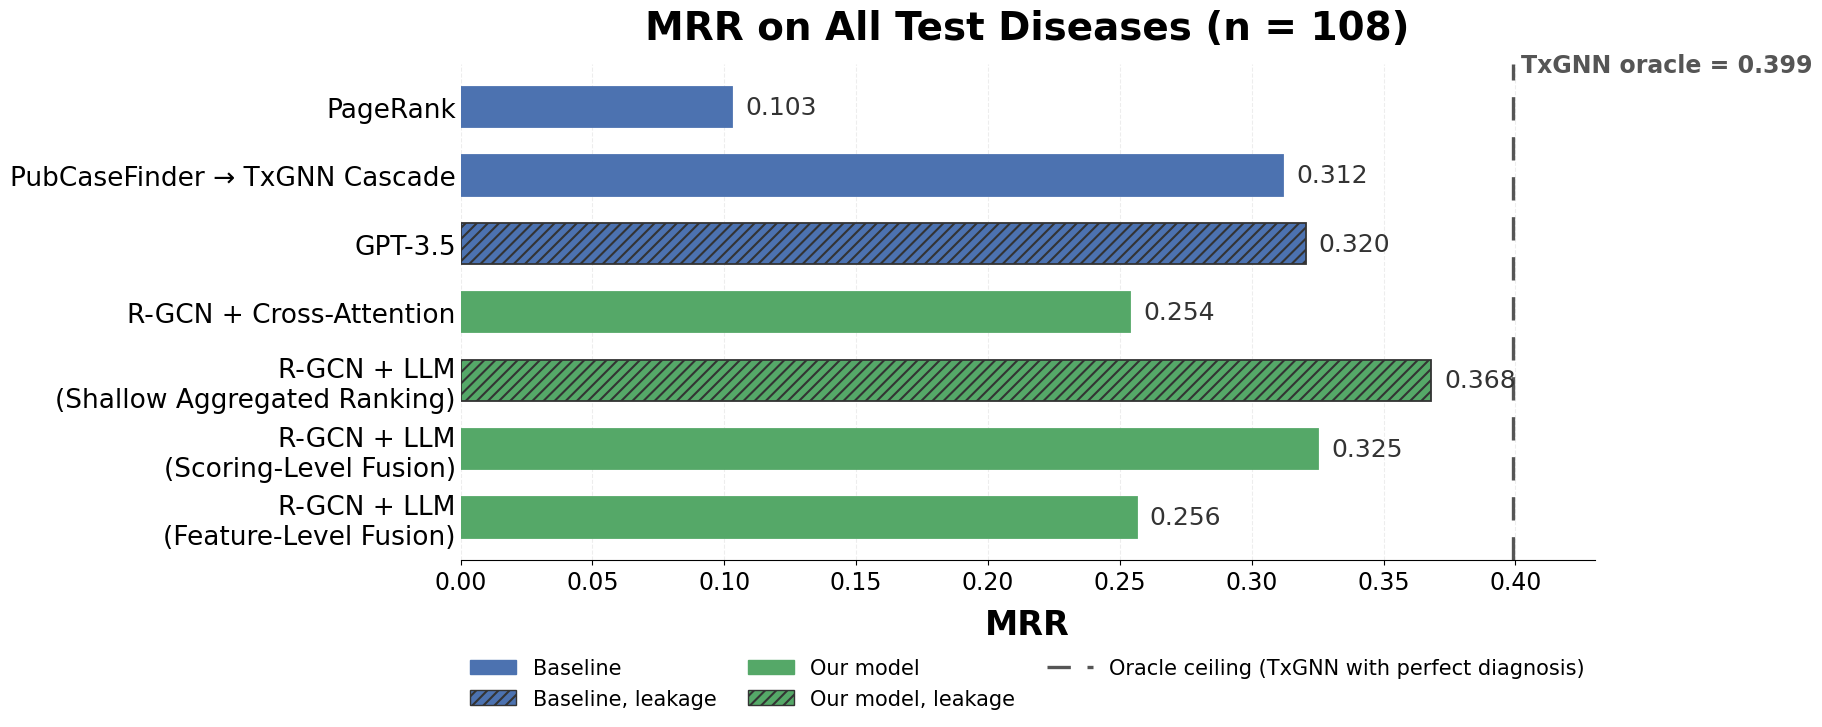

Saved to: /content/drive/MyDrive/Colab Notebooks/tables/mrr_all_test_horizontal_less_spread_swapped.png


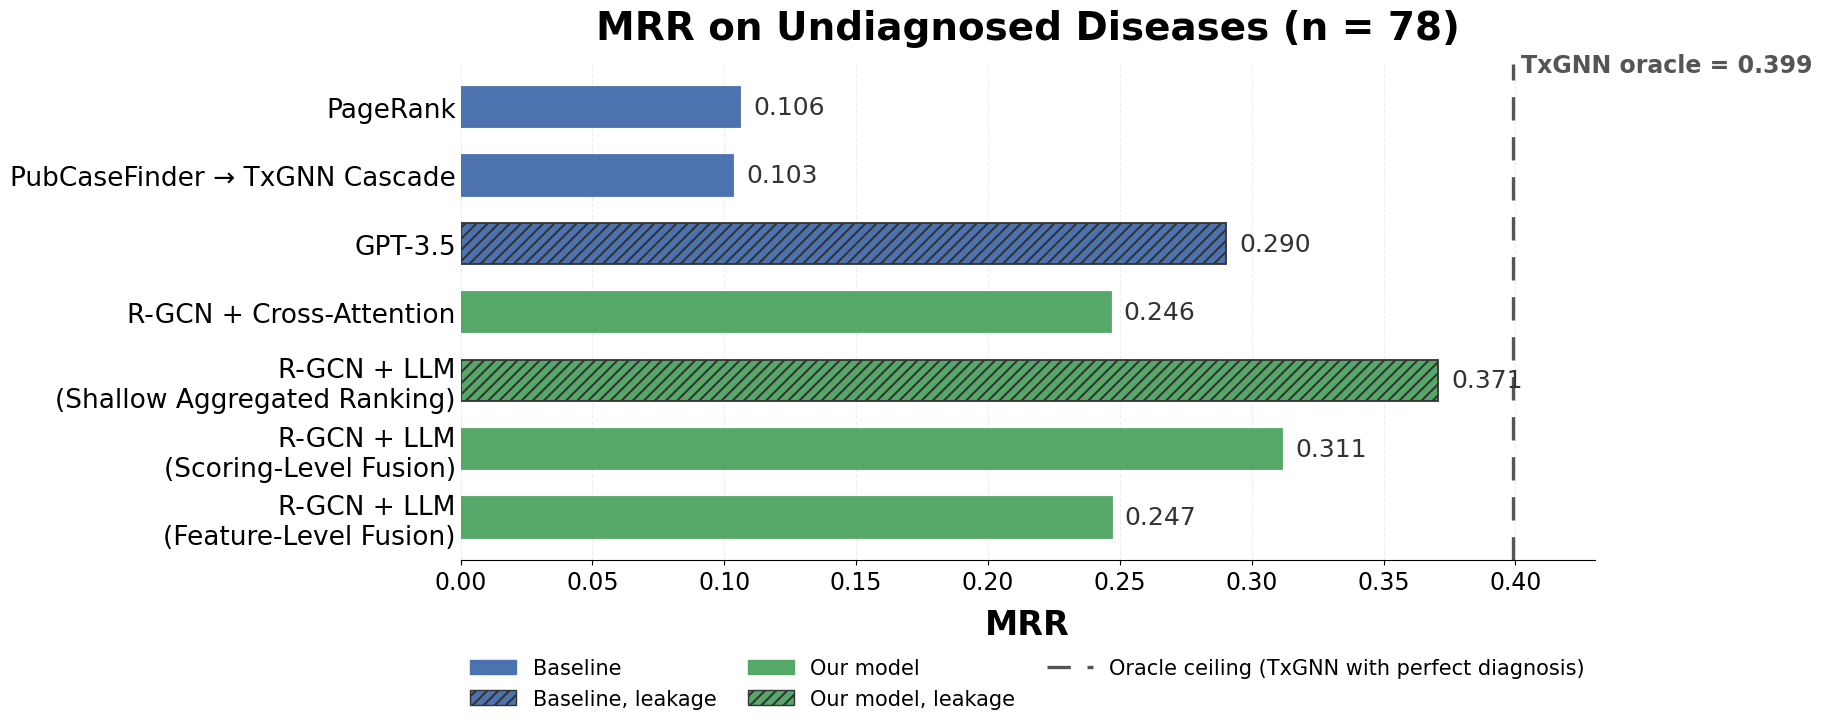

Saved to: /content/drive/MyDrive/Colab Notebooks/tables/mrr_undiagnosed_horizontal_less_spread_swapped.png


In [110]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib as mpl

# =========================================================
# 1. Paths
# =========================================================
TABLE_DIR = DATA_DIR + "tables/"
SAVE_DIR = TABLE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

all_df = pd.read_csv(os.path.join(TABLE_DIR, "final_all_test_summary.csv"))
undx_df = pd.read_csv(os.path.join(TABLE_DIR, "final_undiagnosed_only_summary.csv"))

mpl.rcParams["hatch.linewidth"] = 1.5
plt.rcParams["font.family"] = "DejaVu Sans"

# =========================================================
# 2. Method order and labels
#    Scoring before Feature
# =========================================================
plot_order = [
    "PageRank",
    "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5",
    "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)",
    "R-GCN + LLM (Scoring-Level Fusion)",
    "R-GCN + LLM (Feature-Level Fusion)",
]

display_name_map = {
    "PageRank": "PageRank",
    "PubCaseFinder → TxGNN Cascade": "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5": "GPT-3.5",
    "R-GCN + Cross-Attention": "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "R-GCN + LLM\n(Shallow Aggregated Ranking)",
    "R-GCN + LLM (Scoring-Level Fusion)": "R-GCN + LLM\n(Scoring-Level Fusion)",
    "R-GCN + LLM (Feature-Level Fusion)": "R-GCN + LLM\n(Feature-Level Fusion)",
}

# =========================================================
# 3. Visual encoding
# =========================================================
baseline_clean = {
    "PageRank",
    "PubCaseFinder → TxGNN Cascade",
}

baseline_leakage = {
    "GPT-3.5",
}

ours_clean = {
    "R-GCN + Cross-Attention",
    "R-GCN + LLM (Scoring-Level Fusion)",
    "R-GCN + LLM (Feature-Level Fusion)",
}

ours_leakage = {
    "R-GCN + LLM (Shallow Aggregated Ranking)",
}

BLUE = "#4C72B0"
GREEN = "#55A868"
HATCH_EDGE = "#333333"
ORACLE_COLOR = "#555555"
HATCH = "///"
ORACLE_VALUE = 0.399

# =========================================================
# 4. Helpers
# =========================================================
def prepare_plot_df(df):
    df = df.copy()
    df["model"] = df["model"].astype(str)

    df = df[df["model"].isin(plot_order)].copy()
    df["order"] = df["model"].map({m: i for i, m in enumerate(plot_order)})
    df = df.sort_values("order").reset_index(drop=True)

    df["plot_name"] = df["model"].map(display_name_map)
    return df


def get_style(model_name):
    if model_name in baseline_clean:
        return BLUE, BLUE, None
    if model_name in baseline_leakage:
        return BLUE, HATCH_EDGE, HATCH
    if model_name in ours_clean:
        return GREEN, GREEN, None
    if model_name in ours_leakage:
        return GREEN, HATCH_EDGE, HATCH
    return "gray", "gray", None


# =========================================================
# 5. Plot function
# =========================================================
def plot_mrr_horizontal(df, title, save_name):
    df = prepare_plot_df(df)

    # Less spread than the extra-wide version
    fig, ax = plt.subplots(figsize=(18, 8.0))

    y = np.arange(len(df)) * 1.18
    bar_height = 0.70

    for i, row in df.iterrows():
        model = row["model"]
        value = float(row["MRR"])

        facecolor, edgecolor, hatch = get_style(model)

        ax.barh(
            y=y[i],
            width=value,
            height=bar_height,
            color=facecolor,
            edgecolor=edgecolor,
            linewidth=1.3,
            hatch=hatch,
            zorder=3,
        )

        ax.text(
            value + 0.005,
            y[i],
            f"{value:.3f}",
            va="center",
            ha="left",
            fontsize=18,
            color="#333333",
        )

    # Oracle vertical line
    ax.axvline(
        ORACLE_VALUE,
        color=ORACLE_COLOR,
        linestyle=(0, (7, 5)),
        linewidth=2.4,
        zorder=2,
    )

    ax.text(
        ORACLE_VALUE + 0.003,
        y[0] - 0.72,
        f"TxGNN oracle = {ORACLE_VALUE:.3f}",
        color=ORACLE_COLOR,
        fontsize=17,
        fontweight="bold",
        ha="left",
        va="center",
    )

    # Y axis
    ax.set_yticks(y)
    ax.set_yticklabels(df["plot_name"], fontsize=19)
    ax.invert_yaxis()

    # X axis
    ax.set_xlim(0, 0.43)
    ax.set_xticks(np.arange(0, 0.45, 0.05))
    ax.set_xlabel("MRR", fontsize=24, fontweight="bold", labelpad=10)
    ax.tick_params(axis="x", labelsize=17)
    ax.tick_params(axis="y", length=0)

    # Title
    ax.set_title(title, fontsize=28, fontweight="bold", pad=18)

    # Grid and spines
    ax.grid(axis="x", linestyle="--", alpha=0.22, zorder=0)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    # Legend below plot
    legend_handles = [
        Patch(facecolor=BLUE, edgecolor=BLUE, label="Baseline"),
        Patch(facecolor=BLUE, edgecolor=HATCH_EDGE, hatch=HATCH, label="Baseline, leakage"),
        Patch(facecolor=GREEN, edgecolor=GREEN, label="Our model"),
        Patch(facecolor=GREEN, edgecolor=HATCH_EDGE, hatch=HATCH, label="Our model, leakage"),
        Line2D(
            [0], [0],
            color=ORACLE_COLOR,
            lw=2.4,
            linestyle=(0, (7, 5)),
            label="Oracle ceiling (TxGNN with perfect diagnosis)",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.16),
        ncol=3,
        frameon=False,
        fontsize=15,
        handlelength=2.2,
        columnspacing=1.5,
    )

    plt.subplots_adjust(left=0.33, right=0.96, top=0.87, bottom=0.25)

    save_path = os.path.join(SAVE_DIR, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved to:", save_path)


# =========================================================
# 6. Draw and save plots
# =========================================================
plot_mrr_horizontal(
    all_df,
    "MRR on All Test Diseases (n = 108)",
    "mrr_all_test_horizontal_less_spread_swapped.png",
)

plot_mrr_horizontal(
    undx_df,
    "MRR on Undiagnosed Diseases (n = 78)",
    "mrr_undiagnosed_horizontal_less_spread_swapped.png",
)

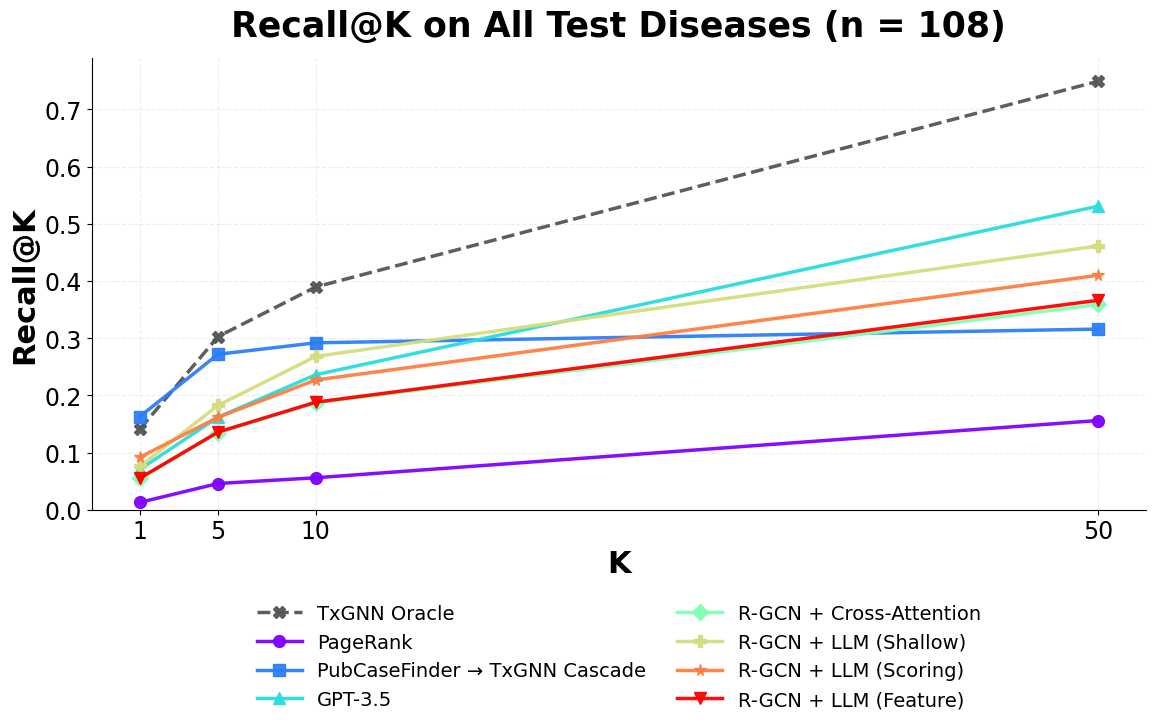

Saved to: /content/drive/MyDrive/Colab Notebooks/tables/recall_all_test_rainbow_oraclegrey_swapped.png


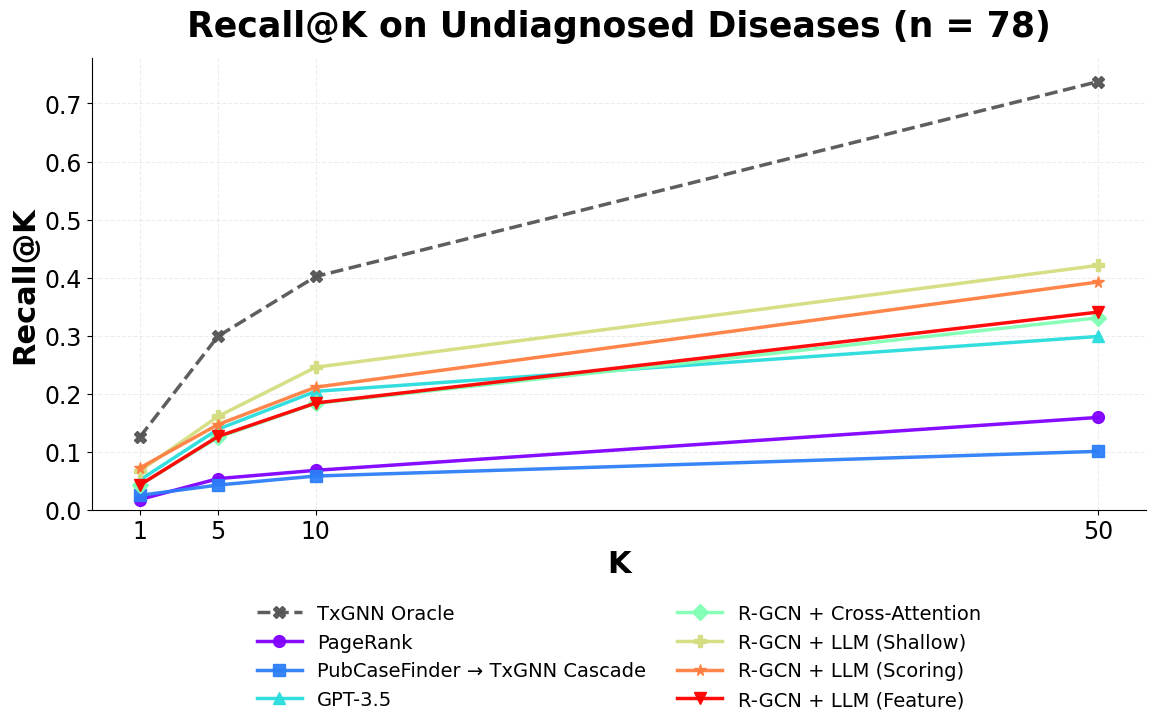

Saved to: /content/drive/MyDrive/Colab Notebooks/tables/recall_undiagnosed_rainbow_oraclegrey_swapped.png


In [108]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Paths
# =========================================================
TABLE_DIR = DATA_DIR + "tables/"
SAVE_DIR = TABLE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

# Load summary tables
all_df = pd.read_csv(os.path.join(TABLE_DIR, "final_all_test_summary.csv"))
undx_df = pd.read_csv(os.path.join(TABLE_DIR, "final_undiagnosed_only_summary.csv"))

# =========================================================
# 2. Model order
#    swapped: Scoring before Feature
# =========================================================
plot_order = [
    "TxGNN Oracle Disease Input",
    "PageRank",
    "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5",
    "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)",
    "R-GCN + LLM (Scoring-Level Fusion)",
    "R-GCN + LLM (Feature-Level Fusion)",
]

display_name_map = {
    "TxGNN Oracle Disease Input": "TxGNN Oracle",
    "PageRank": "PageRank",
    "PubCaseFinder → TxGNN Cascade": "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5": "GPT-3.5",
    "R-GCN + Cross-Attention": "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "R-GCN + LLM (Shallow)",
    "R-GCN + LLM (Scoring-Level Fusion)": "R-GCN + LLM (Scoring)",
    "R-GCN + LLM (Feature-Level Fusion)": "R-GCN + LLM (Feature)",
}

# =========================================================
# 3. Standardize
# =========================================================
def prepare_df(df):
    df = df.copy()
    df["model"] = df["model"].astype(str)
    df = df[df["model"].isin(plot_order)].copy()
    df["order"] = df["model"].map({m: i for i, m in enumerate(plot_order)})
    df = df.sort_values("order").reset_index(drop=True)
    return df

all_df = prepare_df(all_df)
undx_df = prepare_df(undx_df)

# =========================================================
# 4. Rainbow palette + markers
#    Keep oracle fixed in grey/black
# =========================================================
non_oracle_models = [m for m in plot_order if m != "TxGNN Oracle Disease Input"]
rainbow_colors = plt.cm.rainbow(np.linspace(0, 1, len(non_oracle_models)))

color_map = {"TxGNN Oracle Disease Input": "#555555"}
for i, model in enumerate(non_oracle_models):
    color_map[model] = rainbow_colors[i]

marker_map = {
    "TxGNN Oracle Disease Input": "X",
    "PageRank": "o",
    "PubCaseFinder → TxGNN Cascade": "s",
    "GPT-3.5": "^",
    "R-GCN + Cross-Attention": "D",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "P",
    "R-GCN + LLM (Scoring-Level Fusion)": "*",
    "R-GCN + LLM (Feature-Level Fusion)": "v",
}

linestyle_map = {
    "TxGNN Oracle Disease Input": "--",
    "PageRank": "-",
    "PubCaseFinder → TxGNN Cascade": "-",
    "GPT-3.5": "-",
    "R-GCN + Cross-Attention": "-",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "-",
    "R-GCN + LLM (Scoring-Level Fusion)": "-",
    "R-GCN + LLM (Feature-Level Fusion)": "-",
}

# =========================================================
# 5. Plot function
# =========================================================
def plot_recall_lines_rainbow(df, title, save_name):
    df = df.copy()

    recall_cols = ["R@1", "R@5", "R@10", "R@50"]
    ks = [1, 5, 10, 50]

    # slightly less spread than before
    fig, ax = plt.subplots(figsize=(12.4, 7.4))

    for _, row in df.iterrows():
        model = row["model"]
        y = [float(row[c]) for c in recall_cols]

        ax.plot(
            ks,
            y,
            label=display_name_map[model],
            color=color_map[model],
            marker=marker_map[model],
            linestyle=linestyle_map[model],
            linewidth=2.5,
            markersize=8.5,
            alpha=0.95
        )

    ax.set_xlabel("K", fontsize=22, fontweight="bold")
    ax.set_ylabel("Recall@K", fontsize=22, fontweight="bold")
    ax.set_title(title, fontsize=25, fontweight="bold", pad=16)

    ax.set_xticks(ks)
    ax.set_xticklabels([str(k) for k in ks], fontsize=17)
    ax.tick_params(axis="y", labelsize=17)

    ymin = min(df[recall_cols].min()) - 0.03
    ymax = max(df[recall_cols].max()) + 0.04
    ax.set_ylim(max(0, ymin), min(1.0, ymax))

    ax.grid(True, linestyle="--", alpha=0.22)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.17),
        ncol=2,
        frameon=False,
        fontsize=14,
        handlelength=2.3,
        columnspacing=1.6
    )

    plt.subplots_adjust(left=0.12, right=0.97, top=0.88, bottom=0.27)

    save_path = os.path.join(SAVE_DIR, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved to:", save_path)

# =========================================================
# 6. Draw plots
# =========================================================
plot_recall_lines_rainbow(
    all_df,
    "Recall@K on All Test Diseases (n = 108)",
    "recall_all_test_rainbow_oraclegrey_swapped.png"
)

plot_recall_lines_rainbow(
    undx_df,
    "Recall@K on Undiagnosed Diseases (n = 78)",
    "recall_undiagnosed_rainbow_oraclegrey_swapped.png"
)

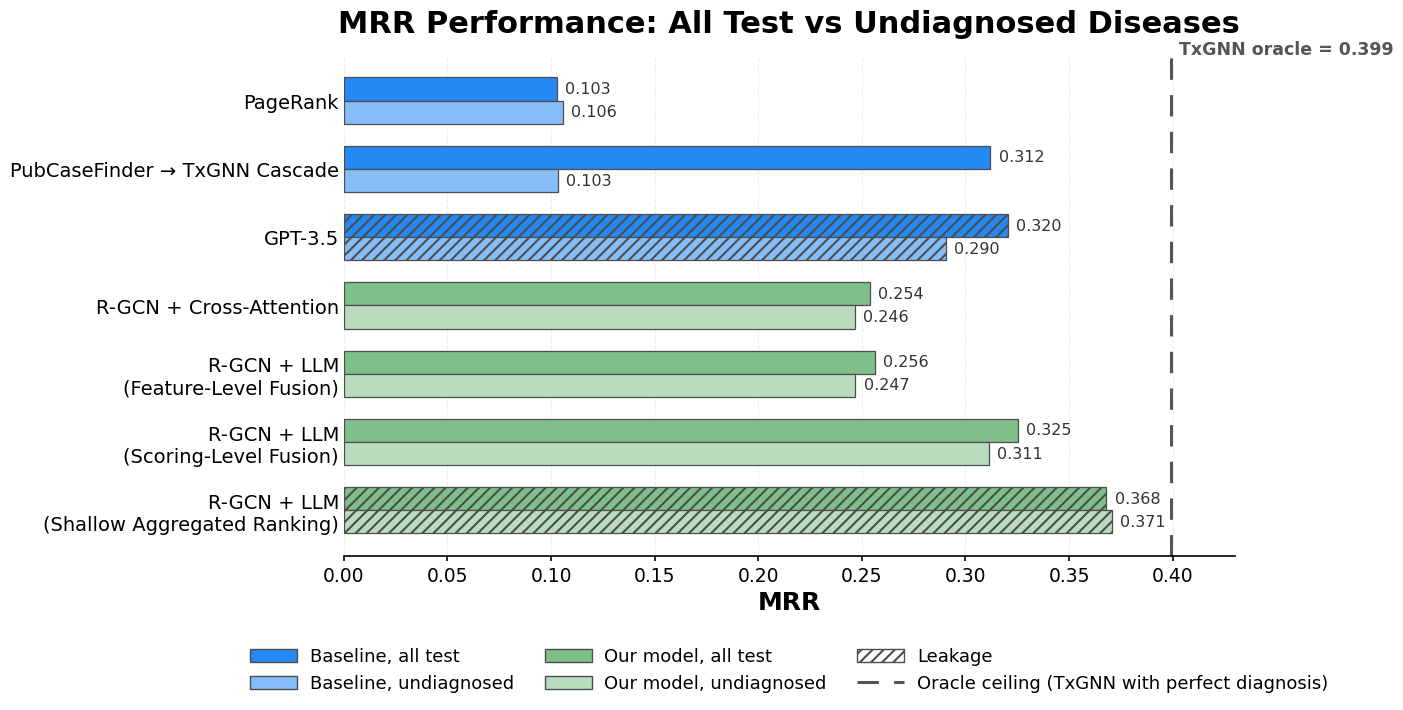

Saved to: /content/drive/MyDrive/Colab Notebooks/tables/reorder_mrr_grouped_family_shade_hatch.png


In [147]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# =========================================================
# 1. Paths
# =========================================================
TABLE_DIR = DATA_DIR + "tables/"
SAVE_DIR = TABLE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

all_df = pd.read_csv(os.path.join(TABLE_DIR, "final_all_test_summary.csv"))
undx_df = pd.read_csv(os.path.join(TABLE_DIR, "final_undiagnosed_only_summary.csv"))

# =========================================================
# 2. Model order
#    TxGNN oracle will NOT be drawn as a bar
# =========================================================
plot_order = [
    "PageRank",
    "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5",
    "R-GCN + Cross-Attention",
    "R-GCN + LLM (Feature-Level Fusion)",
    "R-GCN + LLM (Scoring-Level Fusion)",
    "R-GCN + LLM (Shallow Aggregated Ranking)",
]

display_name_map = {
    "PageRank": "PageRank",
    "PubCaseFinder → TxGNN Cascade": "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5": "GPT-3.5",
    "R-GCN + Cross-Attention": "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "R-GCN + LLM\n(Shallow Aggregated Ranking)",
    "R-GCN + LLM (Scoring-Level Fusion)": "R-GCN + LLM\n(Scoring-Level Fusion)",
    "R-GCN + LLM (Feature-Level Fusion)": "R-GCN + LLM\n(Feature-Level Fusion)",
}

# =========================================================
# 3. Method family + leakage annotation
# =========================================================
baseline_models = {
    "PageRank",
    "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5",
}

our_models = {
    "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)",
    "R-GCN + LLM (Scoring-Level Fusion)",
    "R-GCN + LLM (Feature-Level Fusion)",
}

leakage_models = {
    "GPT-3.5",
    "R-GCN + LLM (Shallow Aggregated Ranking)",
}

# =========================================================
# 4. Rainbow-derived colors
#    One for baselines, one for our models
# =========================================================
cmap = plt.cm.rainbow
baseline_base = cmap(0.18)   # blue-ish
our_base = "#7FBF8A"   # muted green

def lighten_color(color, amount=0.45):
    """
    Blend color toward white.
    amount=0 -> original color
    amount=1 -> white
    """
    c = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple(c + (white - c) * amount)

# darker = all test, lighter = undiagnosed
baseline_all_color  = baseline_base
baseline_undx_color = lighten_color(baseline_base, 0.45)

our_all_color  = our_base
our_undx_color = lighten_color(our_base, 0.45)

# =========================================================
# 5. Prepare merged dataframe
# =========================================================
def prepare_summary(df, value_name):
    df = df.copy()
    df["model"] = df["model"].astype(str)
    df = df[df["model"].isin(plot_order)].copy()
    df = df[["model", "MRR"]].rename(columns={"MRR": value_name})
    return df

all_mrr = prepare_summary(all_df, "MRR_all")
undx_mrr = prepare_summary(undx_df, "MRR_undx")

plot_df = all_mrr.merge(undx_mrr, on="model", how="inner")
plot_df["order"] = plot_df["model"].map({m: i for i, m in enumerate(plot_order)})
plot_df = plot_df.sort_values("order").reset_index(drop=True)
plot_df["label"] = plot_df["model"].map(display_name_map)

# =========================================================
# 6. Plot
# =========================================================
fig, ax = plt.subplots(figsize=(13.5, 7.6))

y = np.arange(len(plot_df))
bar_h = 0.34

for i, row in plot_df.iterrows():
    model = row["model"]

    is_baseline = model in baseline_models
    is_ours = model in our_models
    is_leakage = model in leakage_models

    # pick family colors
    if is_baseline:
        all_color = baseline_all_color
        undx_color = baseline_undx_color
    elif is_ours:
        all_color = our_all_color
        undx_color = our_undx_color
    else:
        all_color = "#999999"
        undx_color = "#CCCCCC"

    hatch = HATCH if is_leakage else None

    # all-test bar
    ax.barh(
        y[i] - bar_h/2,
        float(row["MRR_all"]),
        height=bar_h,
        color=all_color,
        edgecolor=EDGE_COLOR,
        linewidth=0.9,
        hatch=hatch,
        zorder=3
    )

    # undiagnosed bar
    ax.barh(
        y[i] + bar_h/2,
        float(row["MRR_undx"]),
        height=bar_h,
        color=undx_color,
        edgecolor=EDGE_COLOR,
        linewidth=0.9,
        hatch=hatch,
        zorder=3
    )

    # value labels
    ax.text(
        float(row["MRR_all"]) + 0.004,
        y[i] - bar_h/2,
        f"{row['MRR_all']:.3f}",
        va="center",
        ha="left",
        fontsize=11.5,
        color="#333333"
    )
    ax.text(
        float(row["MRR_undx"]) + 0.004,
        y[i] + bar_h/2,
        f"{row['MRR_undx']:.3f}",
        va="center",
        ha="left",
        fontsize=11.5,
        color="#333333"
    )

# oracle line
ax.axvline(
    ORACLE_VALUE,
    color=ORACLE_COLOR,
    linestyle=(0, (7, 5)),
    linewidth=2.2,
    zorder=2
)

ax.text(
    ORACLE_VALUE + 0.004,
    -0.75,
    f"TxGNN oracle = {ORACLE_VALUE:.3f}",
    color=ORACLE_COLOR,
    fontsize=12.5,
    fontweight="bold",
    ha="left",
    va="center"
)

# =========================================================
# 7. Styling
# =========================================================
ax.set_yticks(y)
ax.set_yticklabels(plot_df["label"], fontsize=14, fontweight="normal")
ax.invert_yaxis()

ax.set_xlim(0, 0.43)
ax.set_xticks(np.arange(0, 0.45, 0.05))
ax.tick_params(axis="x", labelsize=13.5, width=1.2)
ax.tick_params(axis="y", length=0)

ax.set_xlabel("MRR", fontsize=18, fontweight="bold")
ax.set_title(
    "MRR Performance: All Test vs Undiagnosed Diseases",
    fontsize=22,
    fontweight="bold",
    pad=16
)

ax.grid(axis="x", linestyle="--", alpha=0.22, zorder=0)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_linewidth(1.2)

# =========================================================
# 8. Legend
# =========================================================
legend_handles = [
    Patch(facecolor=baseline_all_color,  edgecolor=EDGE_COLOR, label="Baseline, all test"),
    Patch(facecolor=baseline_undx_color, edgecolor=EDGE_COLOR, label="Baseline, undiagnosed"),
    Patch(facecolor=our_all_color,       edgecolor=EDGE_COLOR, label="Our model, all test"),
    Patch(facecolor=our_undx_color,      edgecolor=EDGE_COLOR, label="Our model, undiagnosed"),
    Patch(facecolor="white", edgecolor=EDGE_COLOR, hatch=HATCH, label="Leakage"),
    Line2D([0], [0], color=ORACLE_COLOR, lw=2.2, linestyle=(0, (7, 5)),
           label="Oracle ceiling (TxGNN with perfect diagnosis)")
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
    fontsize=13,
    handlelength=2.6,
    columnspacing=1.7,
    handletextpad=0.7,
    prop={"size": 13, "weight": "normal"}
)

plt.subplots_adjust(left=0.31, right=0.97, top=0.88, bottom=0.22)

save_path = os.path.join(SAVE_DIR, "reorder_mrr_grouped_family_shade_hatch.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", save_path)

In [148]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
    'figure.dpi': 150,
})

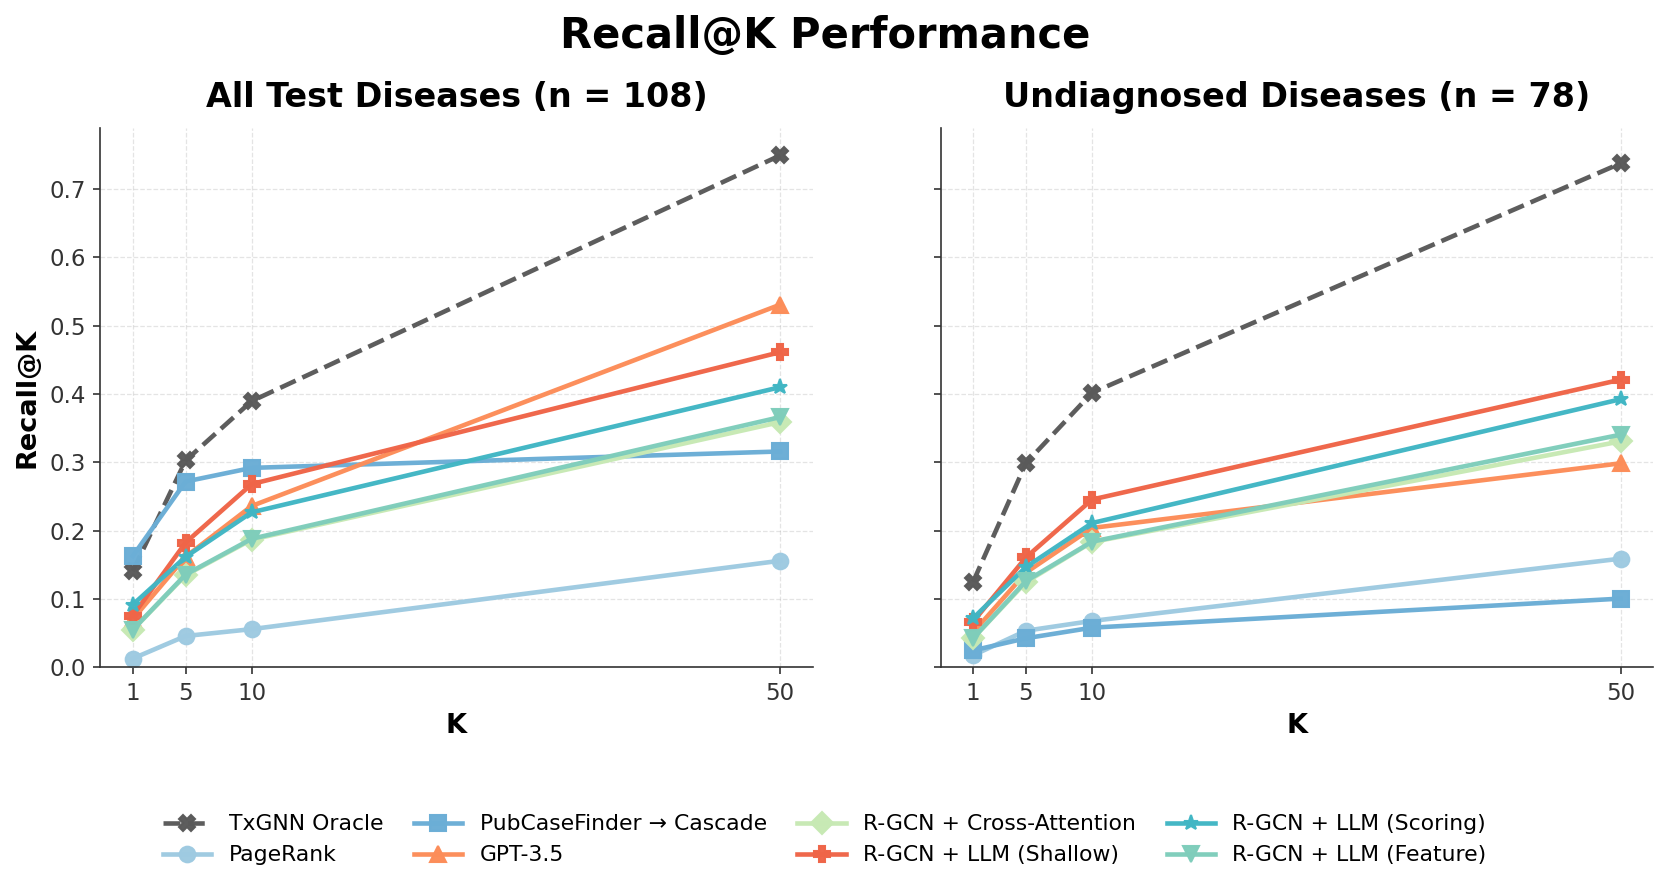

Saved to: /content/drive/MyDrive/Colab Notebooks/tables/recall_two_panel_compact_bluegreen.png


In [152]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Paths
# =========================================================
TABLE_DIR = os.path.join(DATA_DIR, "tables")
SAVE_DIR = TABLE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

all_df = pd.read_csv(os.path.join(TABLE_DIR, "final_all_test_summary.csv"))
undx_df = pd.read_csv(os.path.join(TABLE_DIR, "final_undiagnosed_only_summary.csv"))

# =========================================================
# 2. Order and display names
#    (Feature and Scoring swapped)
# =========================================================
plot_order = [
    "TxGNN Oracle Disease Input",
    "PageRank",
    "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5",
    "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)",
    "R-GCN + LLM (Scoring-Level Fusion)",
    "R-GCN + LLM (Feature-Level Fusion)",
]

display_name_map = {
    "TxGNN Oracle Disease Input": "TxGNN Oracle",
    "PageRank": "PageRank",
    "PubCaseFinder → TxGNN Cascade": "PubCaseFinder → Cascade",
    "GPT-3.5": "GPT-3.5",
    "R-GCN + Cross-Attention": "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "R-GCN + LLM (Shallow)",
    "R-GCN + LLM (Scoring-Level Fusion)": "R-GCN + LLM (Scoring)",
    "R-GCN + LLM (Feature-Level Fusion)": "R-GCN + LLM (Feature)",
}

# =========================================================
# 3. Prepare data
# =========================================================
def prepare_df(df):
    df = df.copy()
    df["model"] = df["model"].astype(str)
    df = df[df["model"].isin(plot_order)].copy()
    df["order"] = df["model"].map({m: i for i, m in enumerate(plot_order)})
    df = df.sort_values("order").reset_index(drop=True)
    return df

all_df = prepare_df(all_df)
undx_df = prepare_df(undx_df)

# =========================================================
# 4. Colors, markers, linestyles
#    varied hues, but similar visual weight
# =========================================================
color_map = {
    "TxGNN Oracle Disease Input": "#5A5A5A",   # keep oracle unchanged

    # baseline / blue family
    "PageRank": "#9ecae1",
    "PubCaseFinder → TxGNN Cascade": "#6baed6",
    "GPT-3.5": "#fc8d59",

    # our models / green-blue family
    "R-GCN + Cross-Attention": "#c7e9b4",
    "R-GCN + LLM (Feature-Level Fusion)": "#7fcdbb",
    "R-GCN + LLM (Scoring-Level Fusion)": "#41b6c4",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "#ef6548",
}

marker_map = {
    "TxGNN Oracle Disease Input": "X",
    "PageRank": "o",
    "PubCaseFinder → TxGNN Cascade": "s",
    "GPT-3.5": "^",
    "R-GCN + Cross-Attention": "D",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "P",
    "R-GCN + LLM (Scoring-Level Fusion)": "*",
    "R-GCN + LLM (Feature-Level Fusion)": "v",
}

linestyle_map = {
    "TxGNN Oracle Disease Input": "--",
    "PageRank": "-",
    "PubCaseFinder → TxGNN Cascade": "-",
    "GPT-3.5": "-",
    "R-GCN + Cross-Attention": "-",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "-",
    "R-GCN + LLM (Scoring-Level Fusion)": "-",
    "R-GCN + LLM (Feature-Level Fusion)": "-",
}

# =========================================================
# 5. Plot function: two-panel compact line plot
# =========================================================
def plot_recall_two_panels(all_df, undx_df, save_name="recall_two_panel_compact.png"):
    recall_cols = ["R@1", "R@5", "R@10", "R@50"]
    ks = [1, 5, 10, 50]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(11.5, 5.8),   # compact, not too stretched
        sharey=True
    )

    panel_specs = [
        (axes[0], all_df, "All Test Diseases (n = 108)"),
        (axes[1], undx_df, "Undiagnosed Diseases (n = 78)")
    ]

    legend_handles = []
    legend_labels = []

    for ax, df, panel_title in panel_specs:
        for _, row in df.iterrows():
            model = row["model"]
            y = [float(row[c]) for c in recall_cols]

            line, = ax.plot(
                ks,
                y,
                color=color_map[model],
                marker=marker_map[model],
                linestyle=linestyle_map[model],
                linewidth=2.2,
                markersize=7.5,
                alpha=0.98,
                label=display_name_map[model]
            )

            if display_name_map[model] not in legend_labels:
                legend_handles.append(line)
                legend_labels.append(display_name_map[model])

        ax.set_title(panel_title, fontsize=16, fontweight="bold", pad=10)
        ax.set_xlabel("K", fontsize=13, fontweight="bold")
        ax.set_xticks(ks)
        ax.set_xticklabels([str(k) for k in ks], fontsize=11)
        ax.tick_params(axis="y", labelsize=11)

        ax.grid(True, linestyle="--", alpha=0.22)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Recall@K", fontsize=13, fontweight="bold")

    # shared y-range
    all_vals = pd.concat([
        all_df[recall_cols].stack(),
        undx_df[recall_cols].stack()
    ]).astype(float)

    ymin = max(0, all_vals.min() - 0.03)
    ymax = min(1.0, all_vals.max() + 0.04)
    axes[0].set_ylim(ymin, ymax)

    # main title
    fig.suptitle("Recall@K Performance", fontsize=20, fontweight="bold", y=0.98)

    # shared legend
    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=4,
        frameon=False,
        fontsize=10.5,
        handlelength=2.2,
        columnspacing=1.4
    )

    plt.subplots_adjust(left=0.08, right=0.98, top=0.85, bottom=0.23, wspace=0.18)

    save_path = os.path.join(SAVE_DIR, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved to:", save_path)

# =========================================================
# 6. Draw
# =========================================================
plot_recall_two_panels(
    all_df,
    undx_df,
    save_name="recall_two_panel_compact_bluegreen.png"
)

In [154]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_recall_two_panels_dodged(all_df, undx_df, save_name):
    recall_cols = ["R@1", "R@5", "R@10", "R@50"]
    k_labels = [1, 5, 10, 50]

    # equally spaced categorical positions
    x_base = np.arange(len(k_labels))

    models = list(all_df["model"])
    n_models = len(models)

    # small dodge offsets
    dodge_width = 0.30
    offsets = np.linspace(-dodge_width/2, dodge_width/2, n_models)

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 8.2), sharey=True)
    fig.suptitle("Recall@K Performance", fontsize=28, fontweight="bold", y=0.98)

    panel_info = [
        (axes[0], all_df, "All Test Diseases (n = 108)"),
        (axes[1], undx_df, "Undiagnosed Diseases (n = 78)")
    ]

    for ax, df, title in panel_info:
        for i, (_, row) in enumerate(df.iterrows()):
            model = row["model"]
            y = [float(row[c]) for c in recall_cols]
            x_plot = x_base + offsets[i]

            ax.plot(
                x_plot,
                y,
                label=display_name_map[model],
                color=color_map[model],
                marker=marker_map[model],
                linestyle=linestyle_map[model],
                linewidth=2.5,
                markersize=9,
                alpha=0.95
            )

        ax.set_title(title, fontsize=22, fontweight="bold", pad=14)
        ax.set_xticks(x_base)
        ax.set_xticklabels([str(k) for k in k_labels], fontsize=16)
        ax.tick_params(axis="y", labelsize=15)
        ax.tick_params(axis="x", labelsize=16)

        ax.set_xlabel("K", fontsize=20, fontweight="bold")
        ax.grid(True, linestyle="--", alpha=0.22)
        ax.set_axisbelow(True)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # leave a little room at both ends
        ax.set_xlim(x_base[0] - 0.35, x_base[-1] + 0.35)

    axes[0].set_ylabel("Recall@K", fontsize=20, fontweight="bold")
    axes[0].set_ylim(0, 0.8)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=4,
        frameon=False,
        fontsize=13,
        handlelength=2.2,
        columnspacing=1.4
    )

    plt.subplots_adjust(left=0.08, right=0.98, top=0.86, bottom=0.23, wspace=0.18)

    save_path = os.path.join(SAVE_DIR, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved to:", save_path)

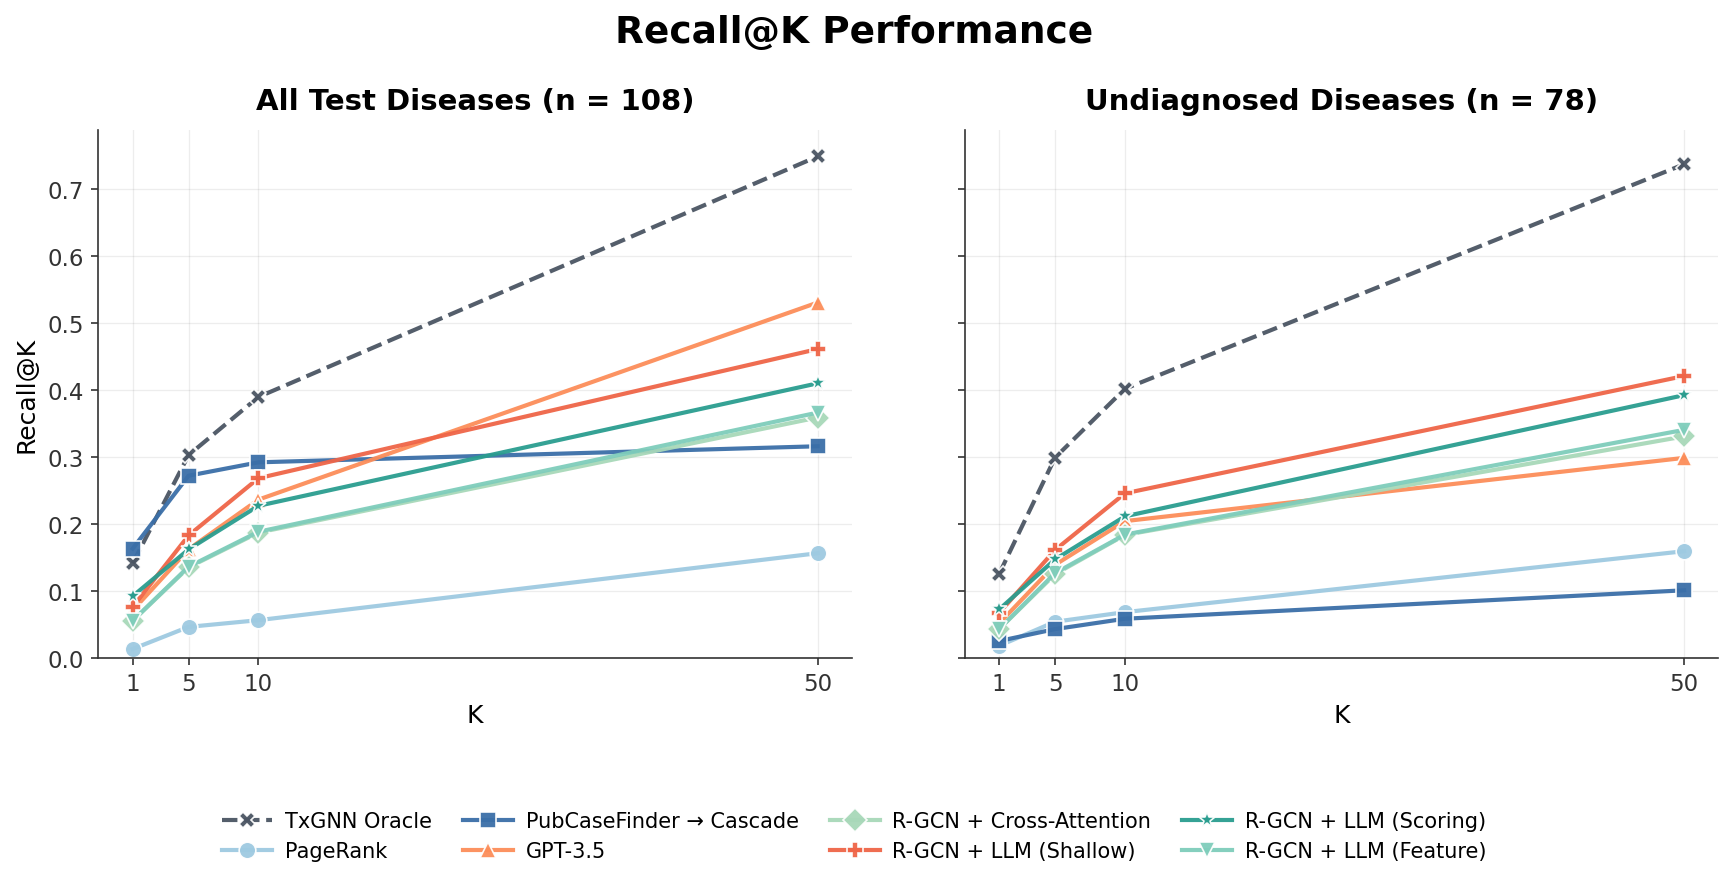

Saved to: /content/drive/MyDrive/Colab Notebooks/tables/recall_two_panel_polished.png


In [150]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 0. Global style — sets the visual baseline for all figures
# =========================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'normal',
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
    'grid.linewidth': 0.6,
    'grid.color': '#888888',
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# =========================================================
# 1. Paths
# =========================================================
TABLE_DIR = os.path.join(DATA_DIR, "tables")
SAVE_DIR = TABLE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

all_df = pd.read_csv(os.path.join(TABLE_DIR, "final_all_test_summary.csv"))
undx_df = pd.read_csv(os.path.join(TABLE_DIR, "final_undiagnosed_only_summary.csv"))

# =========================================================
# 2. Order and display names
# =========================================================
plot_order = [
    "TxGNN Oracle Disease Input",
    "PageRank",
    "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5",
    "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)",
    "R-GCN + LLM (Scoring-Level Fusion)",
    "R-GCN + LLM (Feature-Level Fusion)",
]

display_name_map = {
    "TxGNN Oracle Disease Input": "TxGNN Oracle",
    "PageRank": "PageRank",
    "PubCaseFinder → TxGNN Cascade": "PubCaseFinder → Cascade",
    "GPT-3.5": "GPT-3.5",
    "R-GCN + Cross-Attention": "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "R-GCN + LLM (Shallow)",
    "R-GCN + LLM (Scoring-Level Fusion)": "R-GCN + LLM (Scoring)",
    "R-GCN + LLM (Feature-Level Fusion)": "R-GCN + LLM (Feature)",
}

# =========================================================
# 3. Prepare data
# =========================================================
def prepare_df(df):
    df = df.copy()
    df["model"] = df["model"].astype(str)
    df = df[df["model"].isin(plot_order)].copy()
    df["order"] = df["model"].map({m: i for i, m in enumerate(plot_order)})
    df = df.sort_values("order").reset_index(drop=True)
    return df

all_df = prepare_df(all_df)
undx_df = prepare_df(undx_df)

# =========================================================
# 4. Colors, markers, linestyles
# =========================================================
color_map = {
    "TxGNN Oracle Disease Input": "#4b5563",

    # baselines / cool family
    "PageRank": "#9ecae1",
    "PubCaseFinder → TxGNN Cascade": "#3b6fa8",
    "GPT-3.5": "#fc8d59",

    # our models / green-teal family
    "R-GCN + Cross-Attention": "#a8d8b9",
    "R-GCN + LLM (Feature-Level Fusion)": "#7fcdbb",
    "R-GCN + LLM (Scoring-Level Fusion)": "#2a9d8f",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "#ef6548",
}

marker_map = {
    "TxGNN Oracle Disease Input": "X",
    "PageRank": "o",
    "PubCaseFinder → TxGNN Cascade": "s",
    "GPT-3.5": "^",
    "R-GCN + Cross-Attention": "D",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "P",
    "R-GCN + LLM (Scoring-Level Fusion)": "*",
    "R-GCN + LLM (Feature-Level Fusion)": "v",
}

linestyle_map = {m: "-" for m in plot_order}
linestyle_map["TxGNN Oracle Disease Input"] = "--"

# =========================================================
# 5. Plot function: two-panel compact line plot
# =========================================================
def plot_recall_two_panels(all_df, undx_df, save_name="recall_two_panel.png"):
    recall_cols = ["R@1", "R@5", "R@10", "R@50"]
    ks = [1, 5, 10, 50]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 5.5),
        sharey=True
    )

    panel_specs = [
        (axes[0], all_df, "All Test Diseases (n = 108)"),
        (axes[1], undx_df, "Undiagnosed Diseases (n = 78)")
    ]

    legend_handles = []
    legend_labels = []

    for ax, df, panel_title in panel_specs:
        for _, row in df.iterrows():
            model = row["model"]
            y = [float(row[c]) for c in recall_cols]

            line, = ax.plot(
                ks,
                y,
                color=color_map[model],
                marker=marker_map[model],
                linestyle=linestyle_map[model],
                linewidth=2.0,
                markersize=8,
                markeredgecolor='white',
                markeredgewidth=0.8,
                alpha=0.95,
                label=display_name_map[model],
                zorder=3 if "Scoring" in model else 2,
            )

            if display_name_map[model] not in legend_labels:
                legend_handles.append(line)
                legend_labels.append(display_name_map[model])

        ax.set_title(panel_title, pad=10)
        ax.set_xlabel("K")
        ax.set_xticks(ks)
        ax.set_xticklabels([str(k) for k in ks])

        ax.set_axisbelow(True)

    axes[0].set_ylabel("Recall@K")

    all_vals = pd.concat([
        all_df[recall_cols].stack(),
        undx_df[recall_cols].stack()
    ]).astype(float)

    ymin = max(0, all_vals.min() - 0.03)
    ymax = min(1.0, all_vals.max() + 0.04)
    axes[0].set_ylim(ymin, ymax)

    fig.suptitle("Recall@K Performance", fontsize=18, fontweight="bold", y=1.00)

    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=4,
        handlelength=2.4,
        columnspacing=1.5,
        handletextpad=0.6,
    )

    plt.subplots_adjust(left=0.08, right=0.98, top=0.86, bottom=0.22, wspace=0.15)

    save_path = os.path.join(SAVE_DIR, save_name)
    plt.savefig(save_path)
    plt.show()

    print("Saved to:", save_path)

# =========================================================
# 6. Draw
# =========================================================
plot_recall_two_panels(
    all_df,
    undx_df,
    save_name="recall_two_panel_polished.png"
)

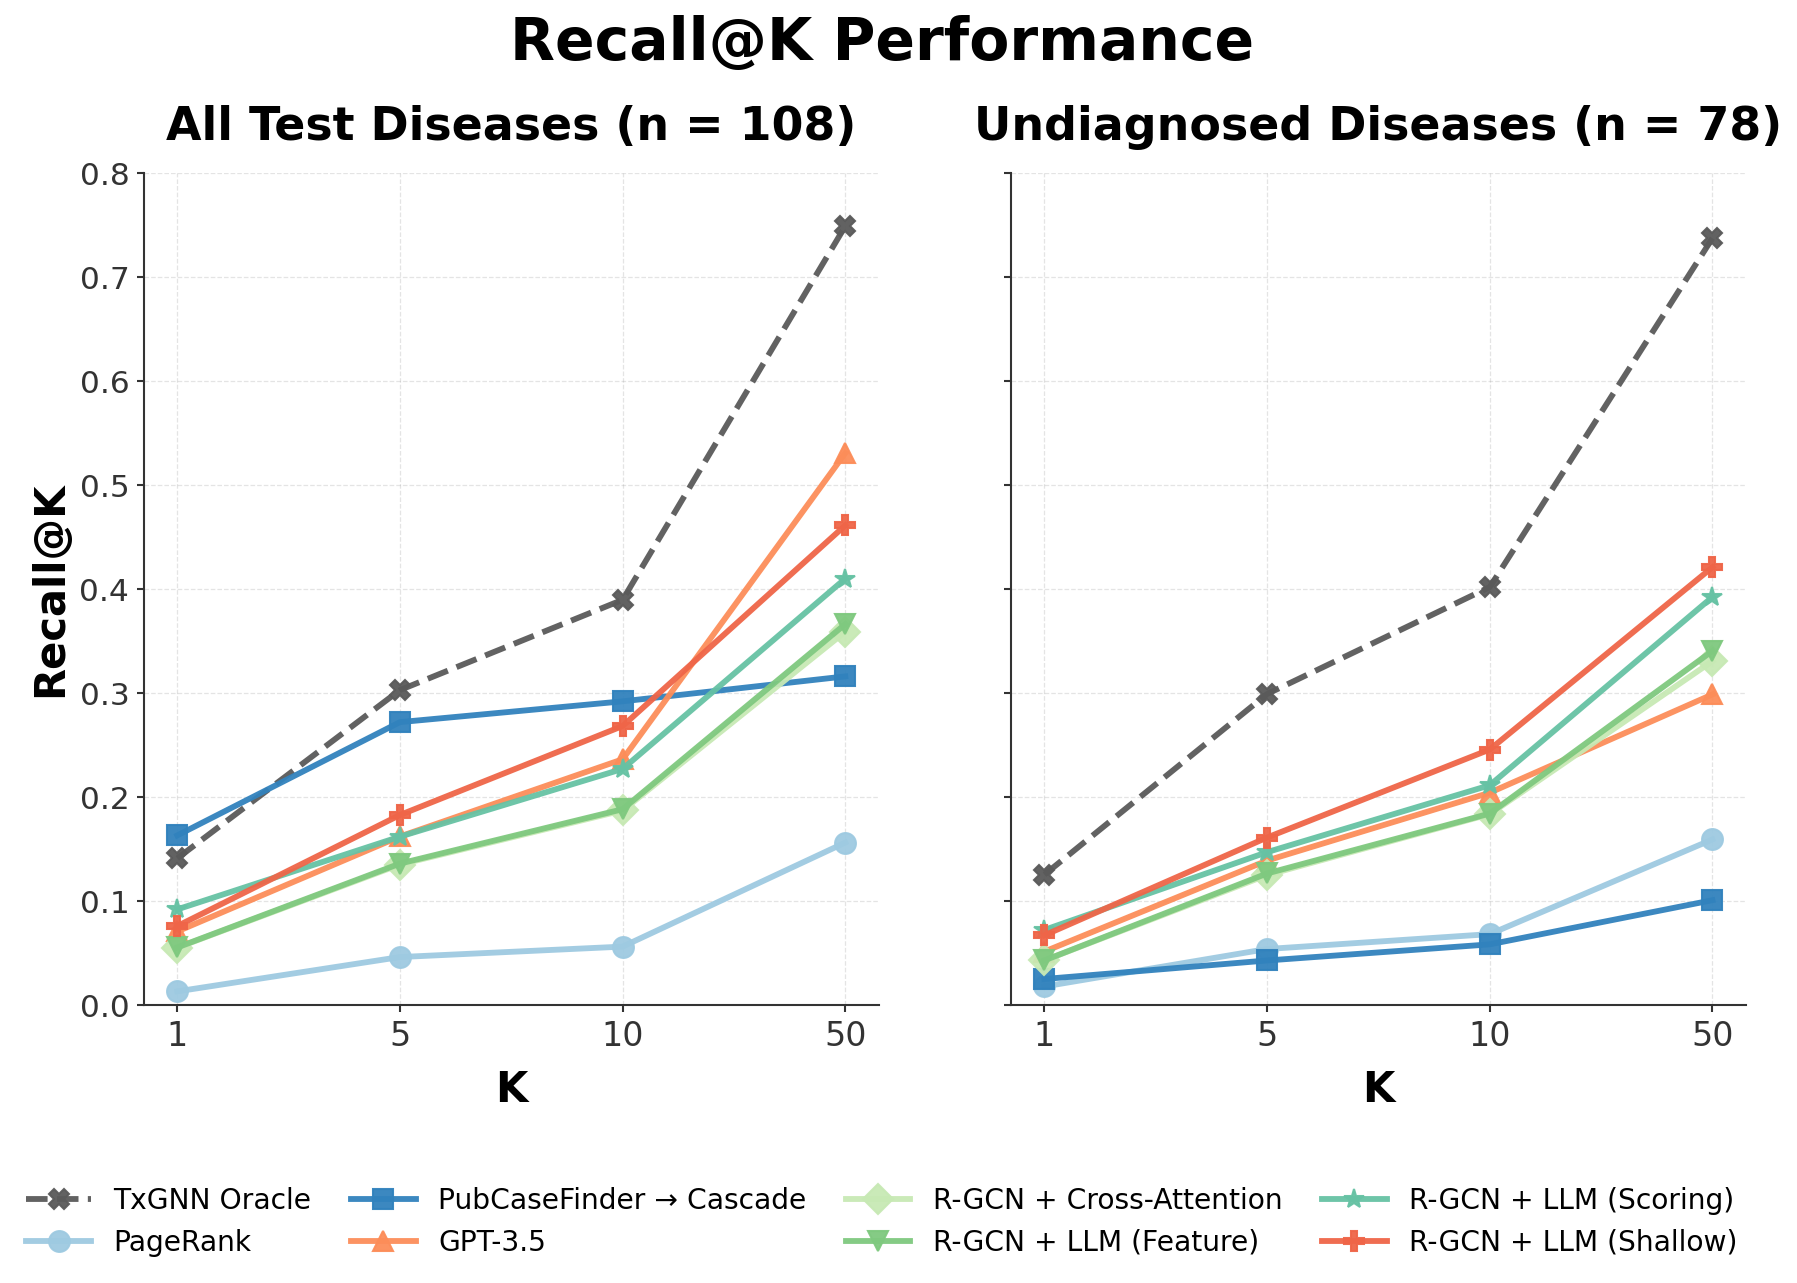

Saved to: /content/drive/MyDrive/Colab Notebooks/tables/recall_two_panels_equal_spacing.png


In [151]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Paths
# =========================================================
TABLE_DIR = DATA_DIR + "tables/"
SAVE_DIR = TABLE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

all_df = pd.read_csv(os.path.join(TABLE_DIR, "final_all_test_summary.csv"))
undx_df = pd.read_csv(os.path.join(TABLE_DIR, "final_undiagnosed_only_summary.csv"))

# =========================================================
# Model order
# =========================================================
plot_order = [
    "TxGNN Oracle Disease Input",
    "PageRank",
    "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5",
    "R-GCN + Cross-Attention",
    "R-GCN + LLM (Feature-Level Fusion)",
    "R-GCN + LLM (Scoring-Level Fusion)",
    "R-GCN + LLM (Shallow Aggregated Ranking)",
]

display_name_map = {
    "TxGNN Oracle Disease Input": "TxGNN Oracle",
    "PageRank": "PageRank",
    "PubCaseFinder → TxGNN Cascade": "PubCaseFinder → Cascade",
    "GPT-3.5": "GPT-3.5",
    "R-GCN + Cross-Attention": "R-GCN + Cross-Attention",
    "R-GCN + LLM (Feature-Level Fusion)": "R-GCN + LLM (Feature)",
    "R-GCN + LLM (Scoring-Level Fusion)": "R-GCN + LLM (Scoring)",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "R-GCN + LLM (Shallow)",
}

def prepare_df(df):
    df = df.copy()
    df["model"] = df["model"].astype(str)
    df = df[df["model"].isin(plot_order)].copy()
    df["order"] = df["model"].map({m: i for i, m in enumerate(plot_order)})
    df = df.sort_values("order").reset_index(drop=True)
    return df

all_df = prepare_df(all_df)
undx_df = prepare_df(undx_df)

# =========================================================
# Colors / markers
# =========================================================
color_map = {
    "TxGNN Oracle Disease Input": "#5A5A5A",

    "PageRank": "#9ecae1",
    "PubCaseFinder → TxGNN Cascade": "#3182bd",
    "GPT-3.5": "#fc8d59",

    "R-GCN + Cross-Attention": "#c7e9b4",
    "R-GCN + LLM (Feature-Level Fusion)": "#7fc97f",
    "R-GCN + LLM (Scoring-Level Fusion)": "#66c2a4",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "#ef6548",
}

marker_map = {
    "TxGNN Oracle Disease Input": "X",
    "PageRank": "o",
    "PubCaseFinder → TxGNN Cascade": "s",
    "GPT-3.5": "^",
    "R-GCN + Cross-Attention": "D",
    "R-GCN + LLM (Feature-Level Fusion)": "v",
    "R-GCN + LLM (Scoring-Level Fusion)": "*",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "P",
}

linestyle_map = {
    "TxGNN Oracle Disease Input": "--",
    "PageRank": "-",
    "PubCaseFinder → TxGNN Cascade": "-",
    "GPT-3.5": "-",
    "R-GCN + Cross-Attention": "-",
    "R-GCN + LLM (Feature-Level Fusion)": "-",
    "R-GCN + LLM (Scoring-Level Fusion)": "-",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "-",
}

# =========================================================
# Plot function
# =========================================================
def plot_recall_two_panels_equal_spacing(all_df, undx_df, save_name):
    recall_cols = ["R@1", "R@5", "R@10", "R@50"]
    k_labels = [1, 5, 10, 50]

    # equally spaced x positions
    x = np.arange(len(k_labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 8.8), sharey=True)
    fig.suptitle("Recall@K Performance", fontsize=28, fontweight="bold", y=0.98)

    panel_info = [
        (axes[0], all_df, "All Test Diseases (n = 108)"),
        (axes[1], undx_df, "Undiagnosed Diseases (n = 78)")
    ]

    for ax, df, title in panel_info:
        for _, row in df.iterrows():
            model = row["model"]
            y = [float(row[c]) for c in recall_cols]

            ax.plot(
                x, y,
                label=display_name_map[model],
                color=color_map[model],
                marker=marker_map[model],
                linestyle=linestyle_map[model],
                linewidth=2.8,
                markersize=10,
                alpha=0.95
            )

        ax.set_title(title, fontsize=22, fontweight="bold", pad=16)
        ax.set_xticks(x)
        ax.set_xticklabels([str(k) for k in k_labels], fontsize=16)
        ax.tick_params(axis="y", labelsize=15, width=1.0)
        ax.tick_params(axis="x", width=1.0)

        ax.set_xlabel("K", fontsize=20, fontweight="bold", labelpad=8)
        ax.grid(True, linestyle="--", alpha=0.22)
        ax.set_axisbelow(True)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.0)
        ax.spines["bottom"].set_linewidth(1.0)

        ax.set_xlim(-0.15, len(x)-1 + 0.15)

    axes[0].set_ylabel("Recall@K", fontsize=20, fontweight="bold")
    axes[0].set_ylim(0, 0.8)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=4,
        frameon=False,
        fontsize=13.5,
        handlelength=2.3,
        columnspacing=1.4
    )

    plt.subplots_adjust(left=0.09, right=0.98, top=0.86, bottom=0.23, wspace=0.18)

    save_path = os.path.join(SAVE_DIR, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved to:", save_path)

# =========================================================
# Draw
# =========================================================
plot_recall_two_panels_equal_spacing(
    all_df,
    undx_df,
    "recall_two_panels_equal_spacing.png"
)

In [155]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_recall_two_panels_dodged(all_df, undx_df, save_name):
    recall_cols = ["R@1", "R@5", "R@10", "R@50"]
    k_labels = [1, 5, 10, 50]

    # equally spaced categorical positions
    x_base = np.arange(len(k_labels))

    models = list(all_df["model"])
    n_models = len(models)

    # small dodge offsets
    dodge_width = 0.30
    offsets = np.linspace(-dodge_width/2, dodge_width/2, n_models)

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 8.2), sharey=True)
    fig.suptitle("Recall@K Performance", fontsize=28, fontweight="bold", y=0.98)

    panel_info = [
        (axes[0], all_df, "All Test Diseases (n = 108)"),
        (axes[1], undx_df, "Undiagnosed Diseases (n = 78)")
    ]

    for ax, df, title in panel_info:
        for i, (_, row) in enumerate(df.iterrows()):
            model = row["model"]
            y = [float(row[c]) for c in recall_cols]
            x_plot = x_base + offsets[i]

            ax.plot(
                x_plot,
                y,
                label=display_name_map[model],
                color=color_map[model],
                marker=marker_map[model],
                linestyle=linestyle_map[model],
                linewidth=2.5,
                markersize=9,
                alpha=0.95
            )

        ax.set_title(title, fontsize=22, fontweight="bold", pad=14)
        ax.set_xticks(x_base)
        ax.set_xticklabels([str(k) for k in k_labels], fontsize=16)
        ax.tick_params(axis="y", labelsize=15)
        ax.tick_params(axis="x", labelsize=16)

        ax.set_xlabel("K", fontsize=20, fontweight="bold")
        ax.grid(True, linestyle="--", alpha=0.22)
        ax.set_axisbelow(True)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # leave a little room at both ends
        ax.set_xlim(x_base[0] - 0.35, x_base[-1] + 0.35)

    axes[0].set_ylabel("Recall@K", fontsize=20, fontweight="bold")
    axes[0].set_ylim(0, 0.8)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=4,
        frameon=False,
        fontsize=13,
        handlelength=2.2,
        columnspacing=1.4
    )

    plt.subplots_adjust(left=0.08, right=0.98, top=0.86, bottom=0.23, wspace=0.18)

    save_path = os.path.join(SAVE_DIR, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved to:", save_path)

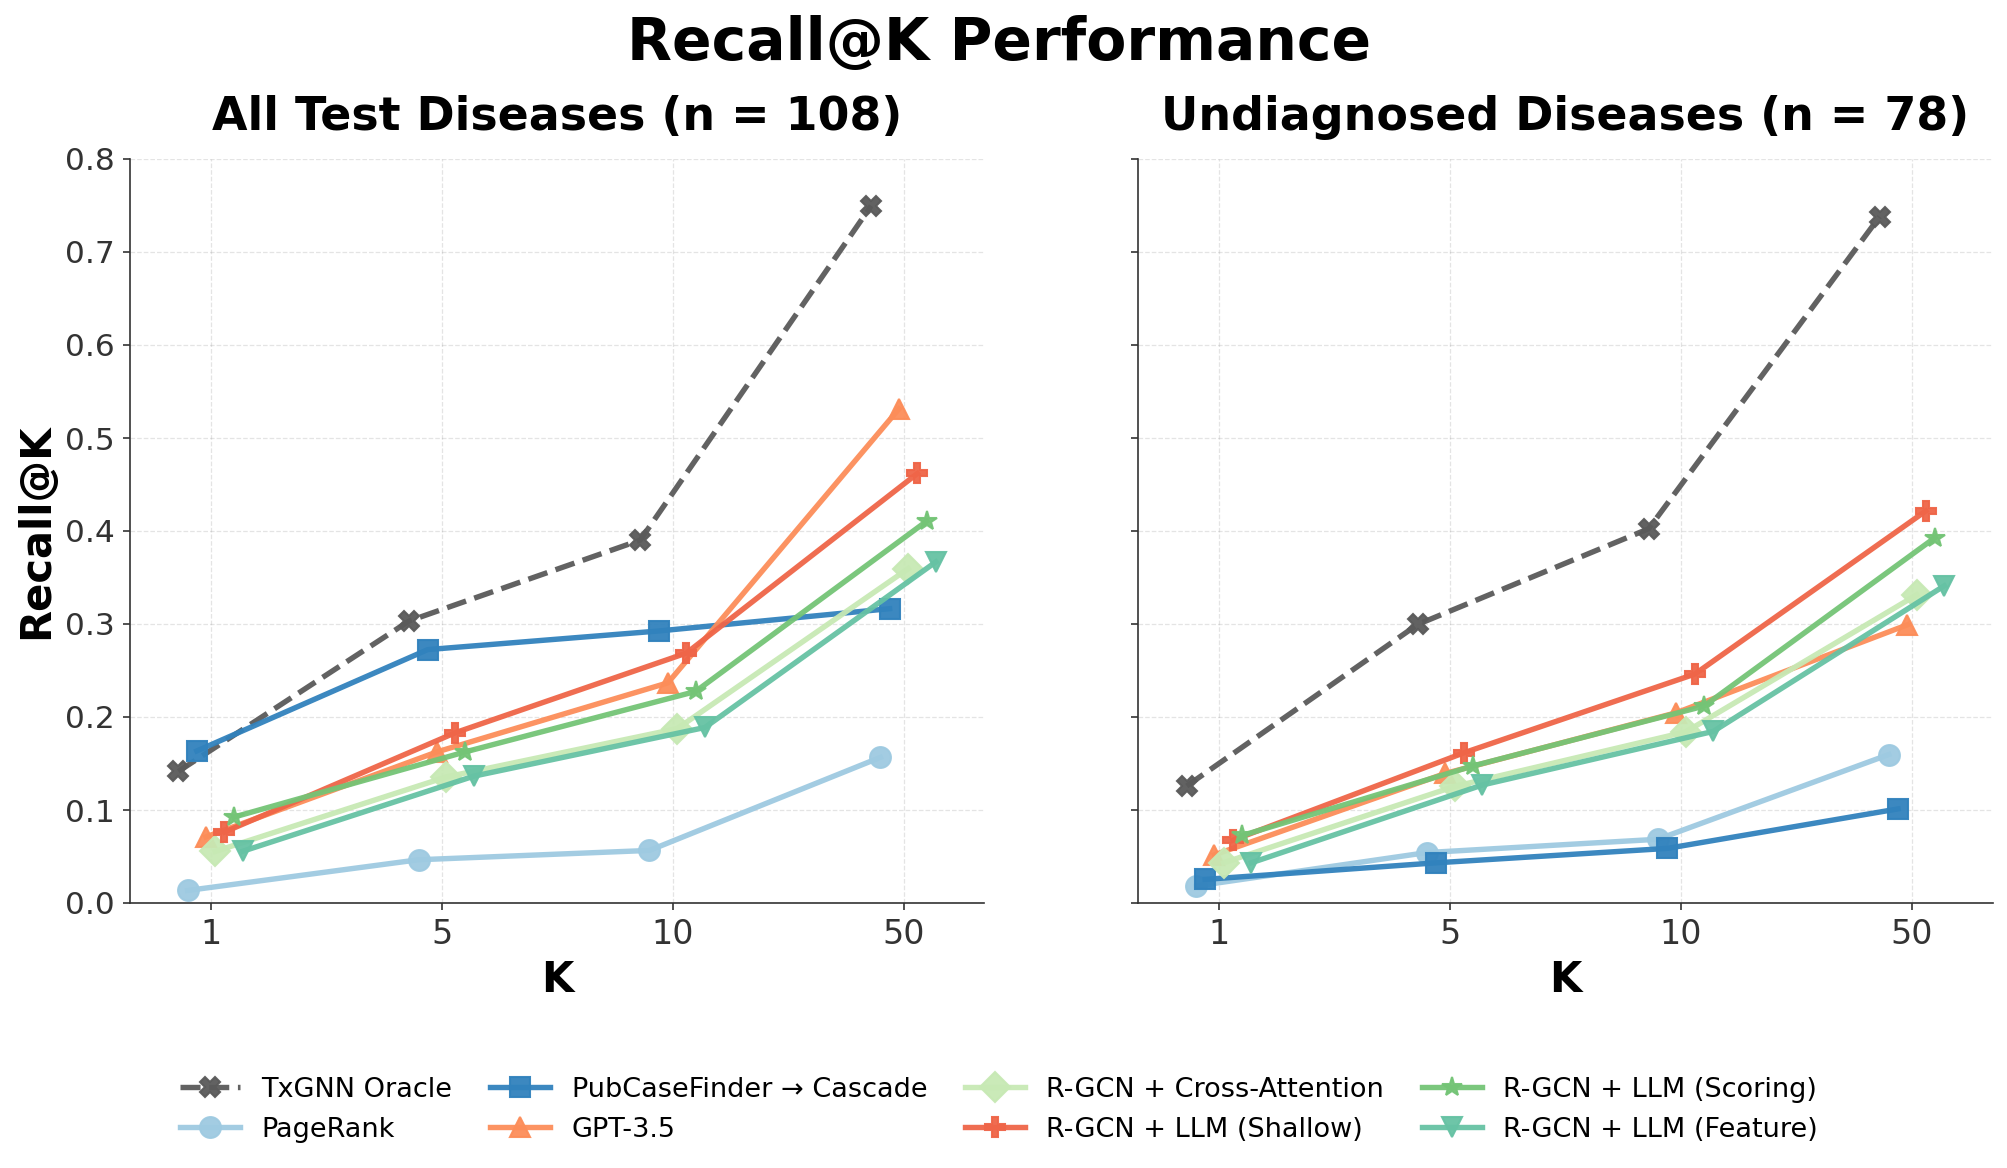

Saved to: /content/drive/MyDrive/Colab Notebooks/tables/recall_two_panels_dodged.png


In [158]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Paths
# =========================================================
TABLE_DIR = os.path.join(DATA_DIR, "tables")
SAVE_DIR = TABLE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

all_csv = os.path.join(TABLE_DIR, "final_all_test_summary.csv")
undx_csv = os.path.join(TABLE_DIR, "final_undiagnosed_only_summary.csv")

all_df = pd.read_csv(all_csv)
undx_df = pd.read_csv(undx_csv)

# =========================================================
# 2. Model order
# =========================================================
plot_order = [
    "TxGNN Oracle Disease Input",
    "PageRank",
    "PubCaseFinder → TxGNN Cascade",
    "GPT-3.5",
    "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)",
    "R-GCN + LLM (Scoring-Level Fusion)",
    "R-GCN + LLM (Feature-Level Fusion)",
]

display_name_map = {
    "TxGNN Oracle Disease Input": "TxGNN Oracle",
    "PageRank": "PageRank",
    "PubCaseFinder → TxGNN Cascade": "PubCaseFinder → Cascade",
    "GPT-3.5": "GPT-3.5",
    "R-GCN + Cross-Attention": "R-GCN + Cross-Attention",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "R-GCN + LLM (Shallow)",
    "R-GCN + LLM (Scoring-Level Fusion)": "R-GCN + LLM (Scoring)",
    "R-GCN + LLM (Feature-Level Fusion)": "R-GCN + LLM (Feature)",
}

def prepare_df(df):
    df = df.copy()
    df["model"] = df["model"].astype(str)
    df = df[df["model"].isin(plot_order)].copy()
    df["order"] = df["model"].map({m: i for i, m in enumerate(plot_order)})
    df = df.sort_values("order").reset_index(drop=True)
    return df

all_df = prepare_df(all_df)
undx_df = prepare_df(undx_df)

# =========================================================
# 3. Colors / markers / line styles
# =========================================================
color_map = {
    "TxGNN Oracle Disease Input": "#5A5A5A",   # grey
    "PageRank": "#9ecae1",
    "PubCaseFinder → TxGNN Cascade": "#3182bd",
    "GPT-3.5": "#fc8d59",
    "R-GCN + Cross-Attention": "#c7e9b4",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "#ef6548",
    "R-GCN + LLM (Scoring-Level Fusion)": "#74c476",
    "R-GCN + LLM (Feature-Level Fusion)": "#66c2a4",
}

marker_map = {
    "TxGNN Oracle Disease Input": "X",
    "PageRank": "o",
    "PubCaseFinder → TxGNN Cascade": "s",
    "GPT-3.5": "^",
    "R-GCN + Cross-Attention": "D",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "P",
    "R-GCN + LLM (Scoring-Level Fusion)": "*",
    "R-GCN + LLM (Feature-Level Fusion)": "v",
}

linestyle_map = {
    "TxGNN Oracle Disease Input": "--",
    "PageRank": "-",
    "PubCaseFinder → TxGNN Cascade": "-",
    "GPT-3.5": "-",
    "R-GCN + Cross-Attention": "-",
    "R-GCN + LLM (Shallow Aggregated Ranking)": "-",
    "R-GCN + LLM (Scoring-Level Fusion)": "-",
    "R-GCN + LLM (Feature-Level Fusion)": "-",
}

# =========================================================
# 4. Plot function with small dodging
# =========================================================
def plot_recall_two_panels_dodged(all_df, undx_df, save_name):
    recall_cols = ["R@1", "R@5", "R@10", "R@50"]
    k_labels = [1, 5, 10, 50]

    # categorical x positions
    x_base = np.arange(len(k_labels))

    models = list(all_df["model"])
    n_models = len(models)

    # small dodge offsets so points don't fully overlap
    dodge_width = 0.28
    offsets = np.linspace(-dodge_width / 2, dodge_width / 2, n_models)

    fig, axes = plt.subplots(1, 2, figsize=(13.8, 8.0), sharey=True)
    fig.suptitle("Recall@K Performance", fontsize=28, fontweight="bold", y=0.98)

    panel_info = [
        (axes[0], all_df, "All Test Diseases (n = 108)"),
        (axes[1], undx_df, "Undiagnosed Diseases (n = 78)")
    ]

    for ax, df, title in panel_info:
        for i, (_, row) in enumerate(df.iterrows()):
            model = row["model"]
            y = [float(row[c]) for c in recall_cols]
            x_plot = x_base + offsets[i]

            ax.plot(
                x_plot,
                y,
                label=display_name_map[model],
                color=color_map[model],
                marker=marker_map[model],
                linestyle=linestyle_map[model],
                linewidth=2.6,
                markersize=10,
                alpha=0.95
            )

        ax.set_title(title, fontsize=22, fontweight="bold", pad=14)
        ax.set_xticks(x_base)
        ax.set_xticklabels([str(k) for k in k_labels], fontsize=16)
        ax.tick_params(axis="y", labelsize=15)
        ax.tick_params(axis="x", labelsize=16)

        ax.set_xlabel("K", fontsize=20, fontweight="bold")
        ax.grid(True, linestyle="--", alpha=0.22)
        ax.set_axisbelow(True)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # leave some room left/right
        ax.set_xlim(x_base[0] - 0.35, x_base[-1] + 0.35)

    axes[0].set_ylabel("Recall@K", fontsize=20, fontweight="bold")
    axes[0].set_ylim(0, 0.8)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=4,
        frameon=False,
        fontsize=13,
        handlelength=2.2,
        columnspacing=1.4
    )

    plt.subplots_adjust(left=0.08, right=0.98, top=0.86, bottom=0.24, wspace=0.18)

    save_path = os.path.join(SAVE_DIR, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved to:", save_path)

# =========================================================
# 5. Run
# =========================================================
plot_recall_two_panels_dodged(
    all_df,
    undx_df,
    "recall_two_panels_dodged.png"
)